Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

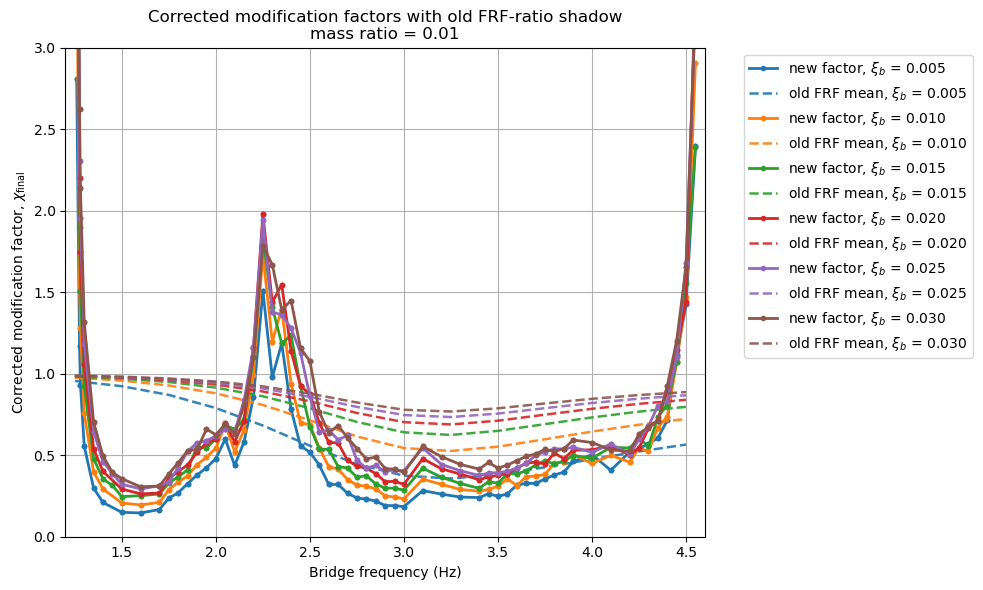

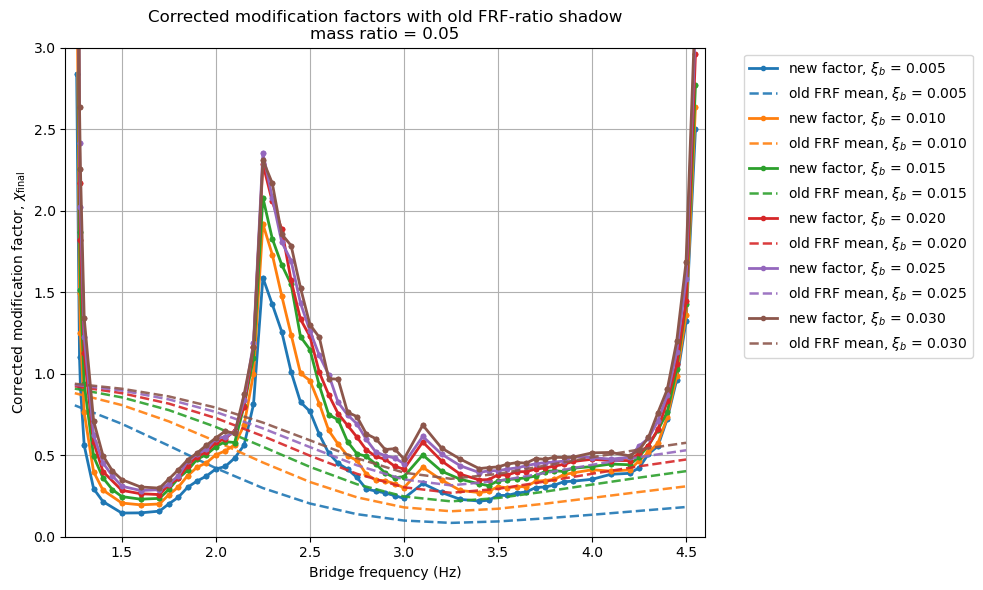

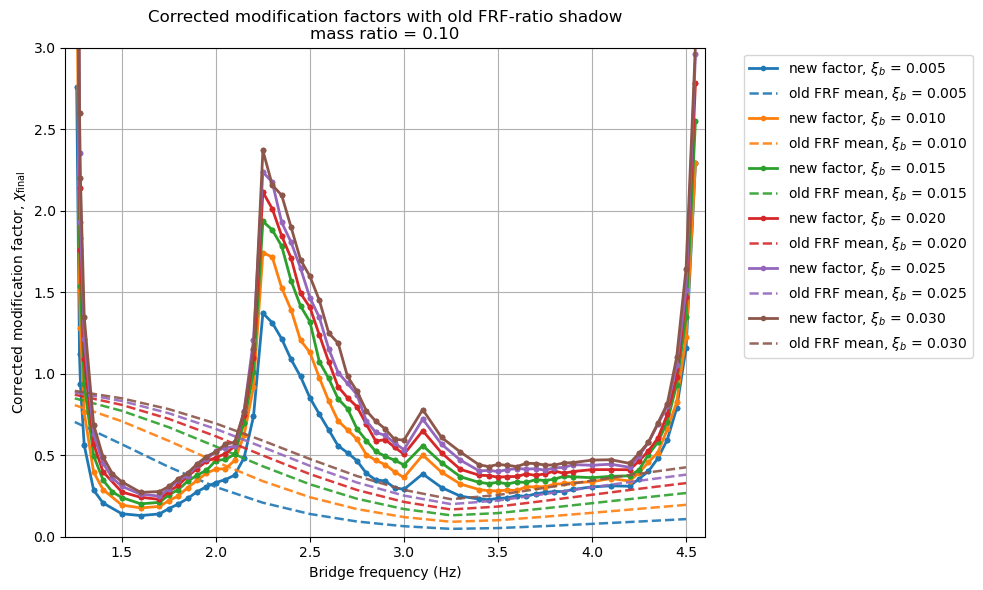

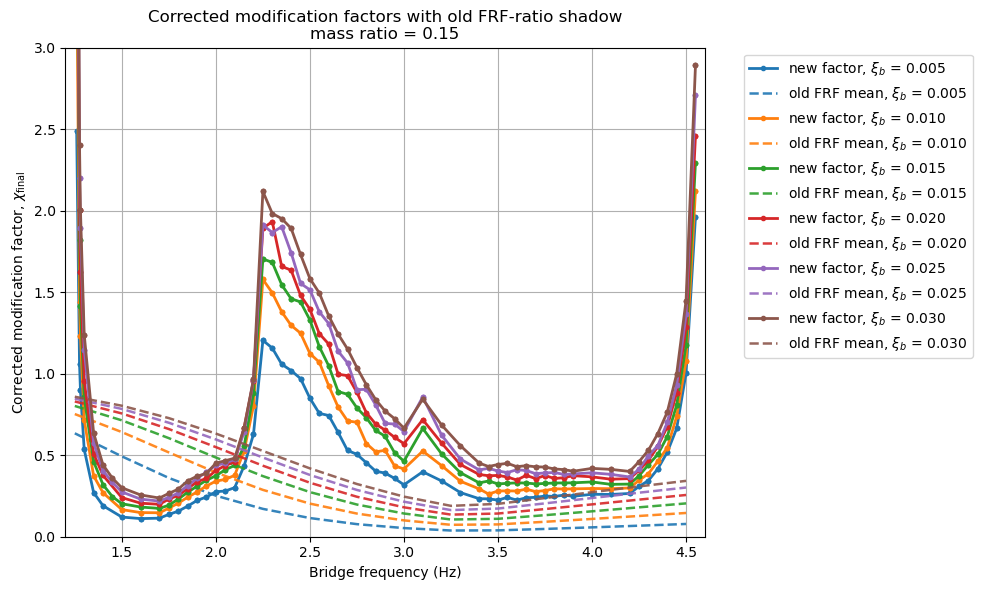

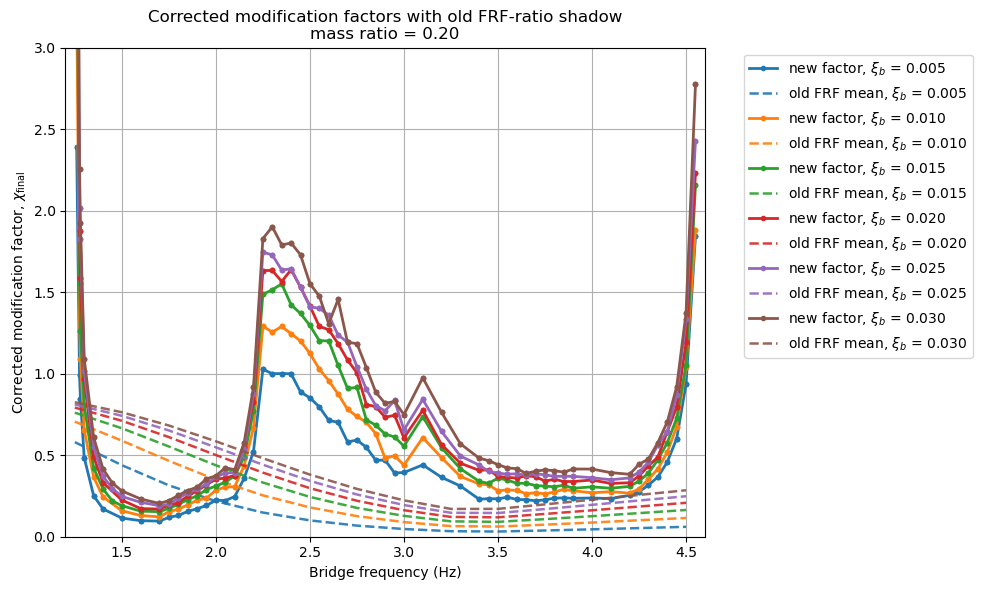

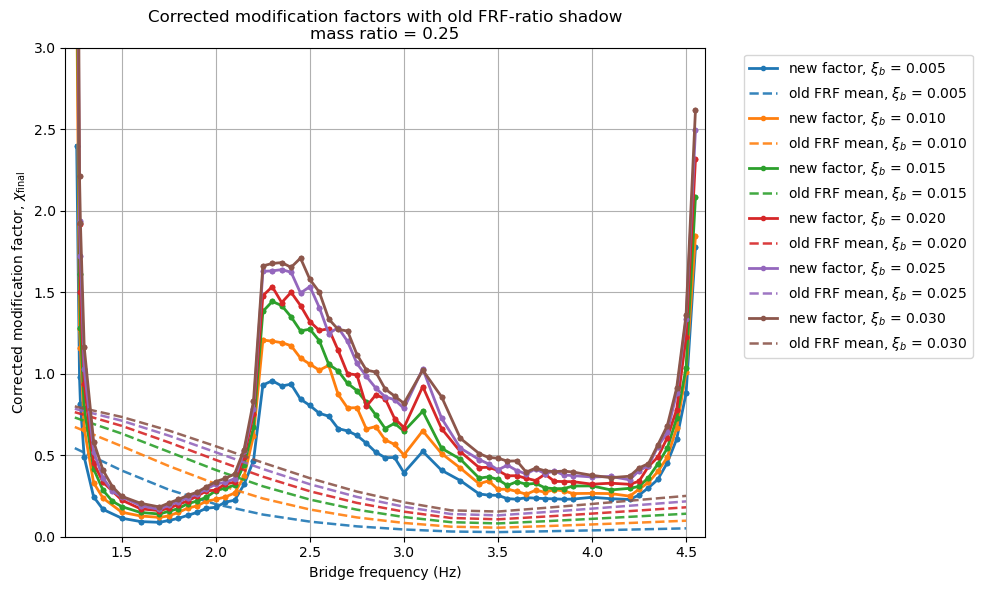

In [2]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

# Old FRF suggestion only for densities < 1
MAX_DENSITY_FOR_OLD_FRF = 1.0

SAVE_PLOTS = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel_map = {
    "final_modification_factor": r"Corrected modification factor, $\chi_{\mathrm{final}}$",
    "initial_modification_factor": r"Initial modification factor, $\chi_0$",
    "residual_correction_factor": r"Residual correction factor, $\lambda$",
    "code_bias_mean": "Mean code bias",
    "simplified_bias_mean": "Mean simplified bias",
    "corrected_bias_mean": "Mean corrected bias",
}

ylabel = ylabel_map.get(PLOT_COLUMN, PLOT_COLUMN.replace("_", " "))

# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

    if corrected_df.empty:
        raise ValueError(f"No rows found for measure: {MEASURE_TO_PLOT}")

# Keep the intended frequency ranges from 0S, 0S125, and 0S456
# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# For old damping cases, you may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# For newer damping cases, such as 0.015, 0.025, 0.030,
#   0S already contains the full frequency range.
#
# Therefore:
#   - if only 0S exists for a density/damping case, keep all 0S frequencies
#   - if 0S125/0S456 also exist, stitch the regions as before

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists -> keep full range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: multiple regional files exist -> stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    # Safety fallback:
    # If stitching removed everything for some unexpected naming case,
    # keep all available rows.
    if g_keep.empty:
        print(
            f"Warning: stitching removed all rows for "
            f"damping={damp_key}, density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)


        
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

# Remove duplicates from multiple response measures
# ==================================================
# KEEP ALL RESPONSE MEASURES
# Remove only true duplicate rows
# ==================================================

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()

print("\nMeasure coverage after keeping all measures:")
print(corrected_df["measure"].value_counts().to_string())
# Keep only the damping ratios we want
corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# LOAD OLD FRF-RATIO PKL
# Your saved structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all = old_data["results_all"]

print("\nLoaded old FRF-ratio file:", OLD_FRF_PKL.name)
print("Saved damping values:", old_data.get("damping_values", "not found"))
print("Saved densities:", old_data.get("densities", "not found"))
print("Saved NUM_SIMULATIONS:", old_data.get("NUM_SIMULATIONS", "not found"))

# ==================================================
# EXTRACT OLD FRF RATIOS DIRECTLY FROM NESTED DICT
# ==================================================

frf_rows = []

for beamdamp, freq_dict in results_all.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                print(f"Skipping non-dict entry: damping={beamdamp}, bf={bf}, density={density}")
                continue

            if "accel_ratio" not in data:
                print(f"Skipping entry with no accel_ratio: damping={beamdamp}, bf={bf}, density={density}")
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    frf_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "accel_ratio": float(accel_ratio),
                    })

frf_df = pd.DataFrame(frf_rows)

if frf_df.empty:
    raise ValueError("No old FRF accel_ratio values were extracted.")

frf_df["density_key"] = frf_df["target_density"].round(4)
frf_df["damping_key"] = frf_df["target_beamdamp"].round(3)

# Keep only the damping ratios we want
frf_df = frf_df[
    frf_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

# Old FRF overlay only for densities < 1
frf_df = frf_df[
    frf_df["target_density"] < MAX_DENSITY_FOR_OLD_FRF
].copy()

frf_summary = (
    frf_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["accel_ratio"]
    .agg(
        frf_mean="mean",
        frf_p5=lambda x: np.percentile(x, 5),
        frf_p50="median",
        frf_p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nOld FRF-ratio summary coverage:")
print(
    frf_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: ONE FIGURE PER MASS RATIO, COMPARE 3 DAMPINGS
# ==================================================

for density in sorted(corrected_df["density_key"].dropna().unique()):

    # You said the FRF comparison is for densities less than 1
    if density >= MAX_DENSITY_FOR_OLD_FRF:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        # ---------------- New corrected factor ----------------
        sub = corrected_df[
            np.isclose(corrected_df["density_key"], density) &
            np.isclose(corrected_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No corrected factor data for density={density:.4f}, damping={damp:.3f}")
            continue

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub[PLOT_COLUMN].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new factor, $\xi_b$ = {damp:.3f}",
        )[0]

        line_color = line.get_color()

        # ---------------- Old FRF-ratio shadow ----------------
        frf_sub = frf_summary[
            np.isclose(frf_summary["density_key"], density) &
            np.isclose(frf_summary["damping_key"], damp_key)
        ].copy()

        # Limit old FRF to the plot frequency range
        frf_sub = frf_sub[
            (frf_sub["bridge_frequency"] >= 1.2) &
            (frf_sub["bridge_frequency"] <= 4.6)
        ].copy()

        frf_sub = frf_sub.sort_values("bridge_frequency")

        if not frf_sub.empty:
            plt.fill_between(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_p5"].values,
                frf_sub["frf_p95"].values,
                color=line_color,
                alpha=0.15,
                linewidth=0,
            )

            plt.plot(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_mean"].values,
                linestyle="--",
                linewidth=1.8,
                color=line_color,
                alpha=0.9,
                label=rf"old FRF mean, $\xi_b$ = {damp:.3f}",
            )
        else:
            print(f"No old FRF data for density={density:.4f}, damping={damp:.3f}")

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(1.2, 4.6)

    plt.ylabel(ylabel)
    plt.ylim(0, 3.0)

    plt.title(
        "Corrected modification factors with old FRF-ratio shadow\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"compare_damping_old_FRF_shadow_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()

Loading: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading: density0.0333_damping0.005_0S_bias_summary.pkl
Loading: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading: density0.0333_damping0.010_0S_bias_summary.pkl
Loading: density0.0333_damping0.015_0S_bias_summary.pkl
Loading: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading: density0.0333_damping0.020_0S_bias_summary.pkl
Loading: density0.0333_damping0.025_0S_bias_summary.pkl
Loading: density0.0333_damping0.030_0S_bias_summary.pkl
Loading: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading: density0.1667_damping0.005_0S456_bias_summary.pkl
Loading: density0.1667_damping0.005_0S_bias_summary.pkl
Loading: density0.1667_damping0.010_0S125_bias_summary.pkl
Loading: density0.1667_damping0.010_0S456_bias_summary.pkl
Loading: density0.

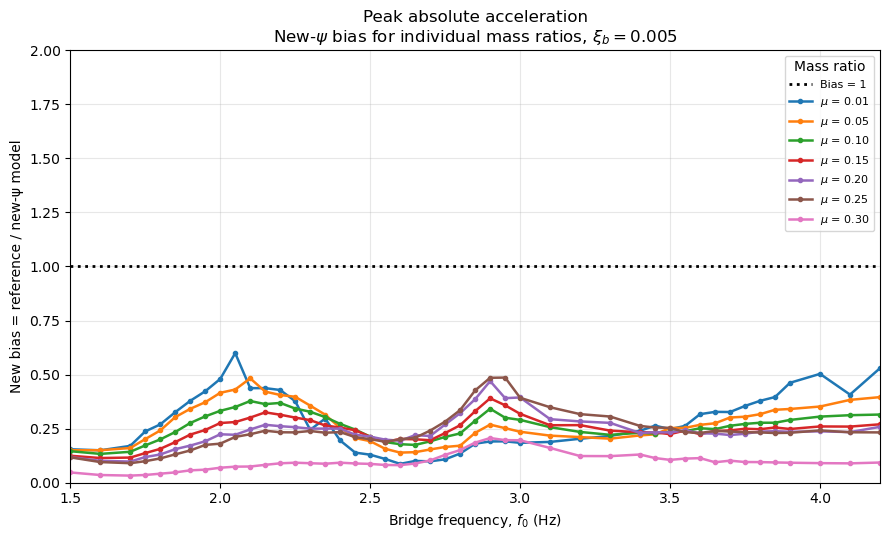

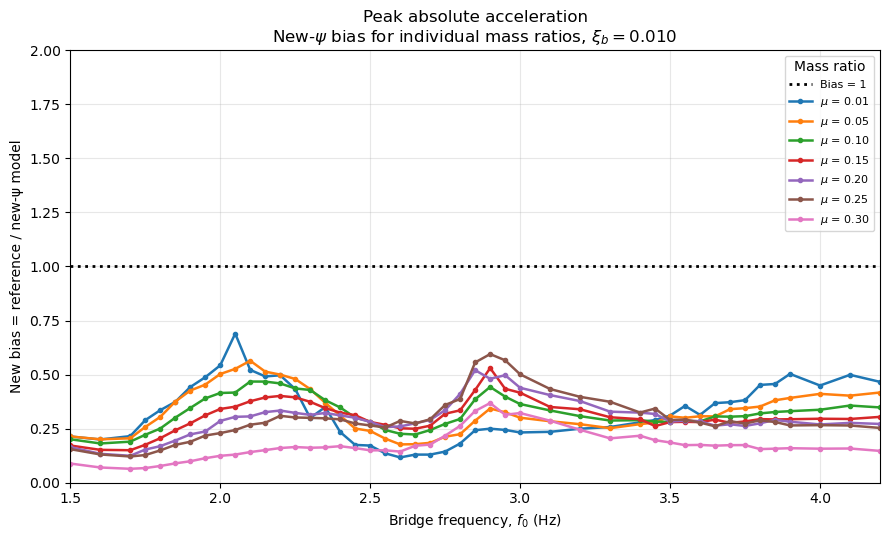

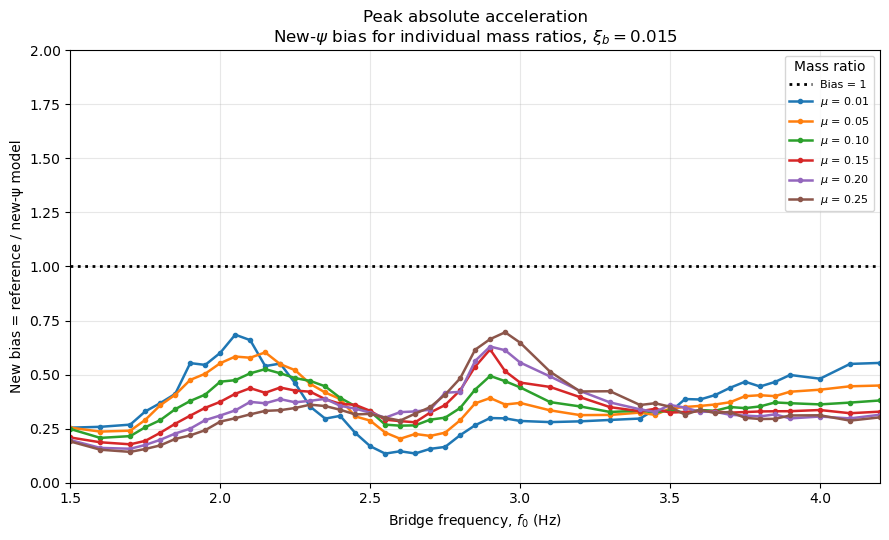

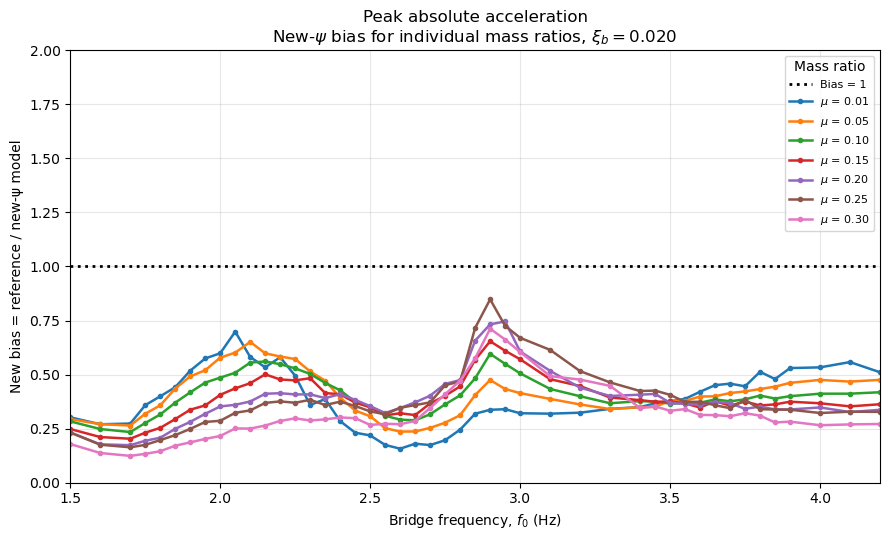

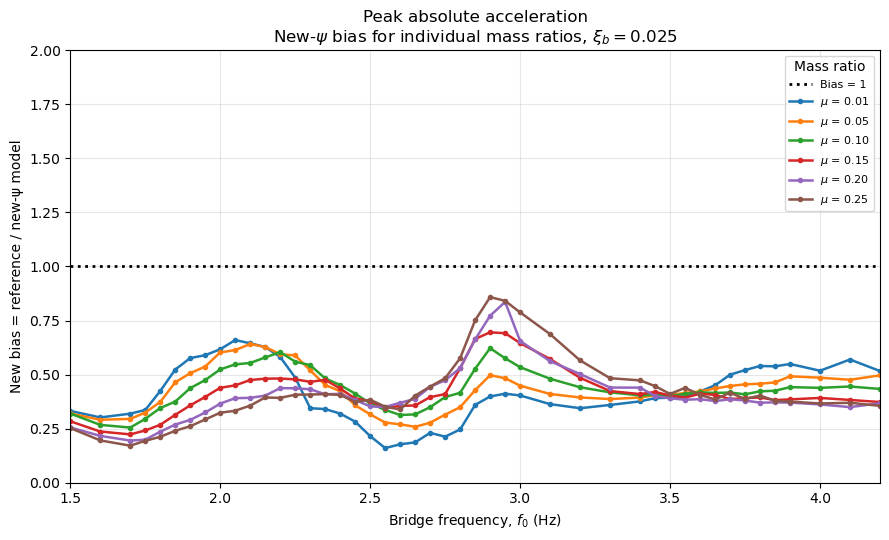

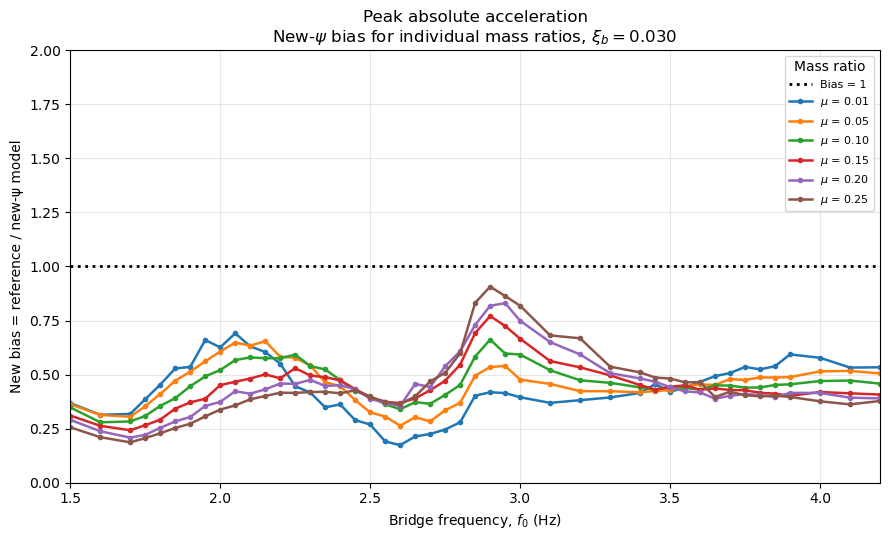

In [3]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

TARGET_DAMPINGS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

MEASURES_TO_PLOT = [
    "Peak absolute acceleration",
    # "95% absolute acceleration",
    # "Peak 1-sec RMS",
]

SAVE_PLOTS = False

YMIN = 0.05
YMAX = 10.0

EPS = 1e-12
PSI_MIN = 0.02

SHOW_ORIGINAL_CODE_CURVES = True
SHOW_NEWPSI_CURVES = True

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.25–1.70 : 0 -> 1
    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 : 1
    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 : 1 -> 0
    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    # 2.50–3.40 : 0 -> 0.25
    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 : 0.25
    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 : 0.25 -> 0
    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Minimum rule between 2.25 and 3.0 Hz
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi

# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    """
    Upper envelope of shifted psi.
    Piecewise equation from the shifted coupled-psi envelope.
    """

    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    # 1.258 <= f0 <= 1.709
    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    # 1.709 <= f0 <= 1.711
    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    # 1.711 <= f0 <= 2.566
    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    # 2.566 <= f0 <= 2.568
    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    # 2.568 <= f0 <= 2.872
    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    # 2.872 <= f0 <= 2.874
    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    # 2.874 <= f0 <= 4.191
    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    # 4.191 <= f0 <= 4.193
    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    # 4.193 <= f0 <= 4.593
    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    psi = np.clip(psi, 0.0, 1.0)

    return psi

# ==================================================
# LOAD ALL 0S, 0S125, 0S456 SUMMARY FILES
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

print("\nLoaded combined dataframe shape:", corrected_df.shape)

# ==================================================
# CLEAN DATA
# ==================================================

required_columns = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "measure",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]

missing_columns = [c for c in required_columns if c not in corrected_df.columns]

if missing_columns:
    raise KeyError(f"Missing columns in corrected_df: {missing_columns}")

for col in [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "code_bias_mean",
    "code_bias_p5",
    "code_bias_p95",
]:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.dropna(subset=required_columns).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

# ==================================================
# KEEP FREQUENCY REGIONS BASED ON FILE CONTENT
# ==================================================

# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# Older damping cases may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# Newer damping cases, e.g. 0.015, 0.025, 0.030,
# may have full frequency range stored as 0S.
#
# So:
#   - if only 0S exists for a density/damping pair, keep all 0S rows
#   - if regional files exist, stitch 0S125, 0S, and 0S456

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists, keep full frequency range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: regional files exist, stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    if g_keep.empty:
        print(
            f"Warning: no stitched rows for damping={damp_key}, "
            f"density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)

# Remove duplicate rows if same frequency appears multiple times
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "measure", "bridge_frequency"]
)

corrected_df = corrected_df.drop_duplicates(
    subset=["damping_key", "density_key", "measure", "bridge_frequency"],
    keep="first"
).copy()

# ==================================================
# FILTER TARGET DAMPINGS AND FREQUENCY RANGE
# ==================================================

df = corrected_df.copy()

damping_mask = np.zeros(len(df), dtype=bool)

for damp in TARGET_DAMPINGS:
    damping_mask |= np.isclose(df["target_beamdamp"], damp)

plot_all_df = df[damping_mask].copy()

plot_all_df = plot_all_df[
    (plot_all_df["bridge_frequency"] >= PLOT_FMIN)
    & (plot_all_df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if plot_all_df.empty:
    raise ValueError(
        "No rows found after filtering. Check TARGET_DAMPINGS and frequency range."
    )

# ==================================================
# CALCULATE OLD psi, NEW psi, AND NEW-psi BIAS
# ==================================================
# code_bias = reference / old_code_model
#
# old_code_model uses psi_old
# new_code_model uses psi_env
#
# new_code_model = old_code_model * psi_env / psi_old
#
# therefore:
#
# newpsi_bias = code_bias * psi_old / psi_env
# ==================================================

plot_all_df["psi_old"] = psi_w_h1_old(
    plot_all_df["bridge_frequency"].to_numpy()
)

plot_all_df["psi_env"] = psi_env_new(
    plot_all_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(plot_all_df["psi_old"])
    & np.isfinite(plot_all_df["psi_env"])
    & (plot_all_df["psi_old"] > PSI_MIN)
    & (plot_all_df["psi_env"] > PSI_MIN)
)

plot_all_df["psi_ratio_old_to_env"] = np.nan
plot_all_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    plot_all_df.loc[valid_psi, "psi_old"]
    / plot_all_df.loc[valid_psi, "psi_env"]
)

for stat in ["mean", "p5", "p95"]:

    old_col = f"code_bias_{stat}"
    new_col = f"newpsi_bias_{stat}"
    hsi_col = f"hsi_factor_{stat}"

    plot_all_df[new_col] = (
        plot_all_df[old_col]
        * plot_all_df["psi_ratio_old_to_env"]
    )

    plot_all_df[new_col] = (
        plot_all_df[new_col]
        .replace([np.inf, -np.inf], np.nan)
    )

    # HSI factor needed after using the new psi model
    plot_all_df[hsi_col] = plot_all_df[new_col]

# ==================================================
# ADD MASS RATIO COLUMN
# ==================================================

plot_all_df["mass_ratio"] = plot_all_df["density_key"].map(
    lambda d: density_to_mass_ratio.get(round(float(d), 4), np.nan)
)

# ==================================================
# PRINT CHECK
# ==================================================

print("\nAvailable data after filtering:")
print(
    plot_all_df
    .groupby(["damping_key", "density_key", "measure"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
    .to_string(index=False)
)

# ==================================================
# PLOT FUNCTION: ONE FIGURE PER DAMPING RATIO
# ONLY NEW-psi BIAS
# ==================================================

def plot_newpsi_bias_one_damping(measure_name, damp):

    measure_df = plot_all_df[
        plot_all_df["measure"].astype(str).str.strip() == measure_name
    ].copy()

    sub_damp = measure_df[
        np.isclose(measure_df["target_beamdamp"], damp)
    ].copy()

    if sub_damp.empty:
        print(f"No data for measure={measure_name}, damping={damp:.3f}")
        return

    plt.figure(figsize=(9, 5.5))

    plt.axhline(
        1.0,
        linestyle=":",
        linewidth=2.0,
        color="black",
        label="Bias = 1",
    )

    # --------------------------------------------------
    # Plot only new-psi bias for each mass ratio
    # --------------------------------------------------

    for density in sorted(sub_damp["density_key"].dropna().unique()):

        sub = sub_damp[
            np.isclose(sub_damp["density_key"], density)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        mr = density_to_mass_ratio.get(round(float(density), 4), None)

        if mr is not None:
            label = rf"$\mu$ = {mr:.2f}"
        else:
            label = f"density = {density:.4f}"

        plt.plot(
            sub["bridge_frequency"],
            sub["newpsi_bias_mean"],
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=label,
        )

    # --------------------------------------------------
    # Formatting
    # --------------------------------------------------

    plt.xlabel(r"Bridge frequency, $f_0$ (Hz)")
    plt.ylabel("New bias = reference / new-ψ model")

    plt.title(
        f"{measure_name}\n"
        rf"New-$\psi$ bias for individual mass ratios, $\xi_b = {damp:.3f}$"
    )

    plt.xlim(1.5, 4.2)
    plt.yscale("linear")
    plt.ylim(0, 2)

    plt.grid(True, which="both", alpha=0.30)

    plt.legend(
        loc="best",
        fontsize=8,
        title="Mass ratio",
    )

    plt.tight_layout()

    if SAVE_PLOTS:
        safe_measure = (
            measure_name
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fig_name = (
            f"newpsi_bias_{safe_measure}_"
            f"damping{damp:.3f}.png"
        )

        plt.savefig(fig_name, dpi=300, bbox_inches="tight")
        print("Saved:", fig_name)

    plt.show()
# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

# ==================================================
# MAKE ONE SEPARATE FIGURE PER DAMPING RATIO
# ==================================================

for measure_name in MEASURES_TO_PLOT:
    for damp in TARGET_DAMPINGS:
        plot_newpsi_bias_one_damping(measure_name, damp)

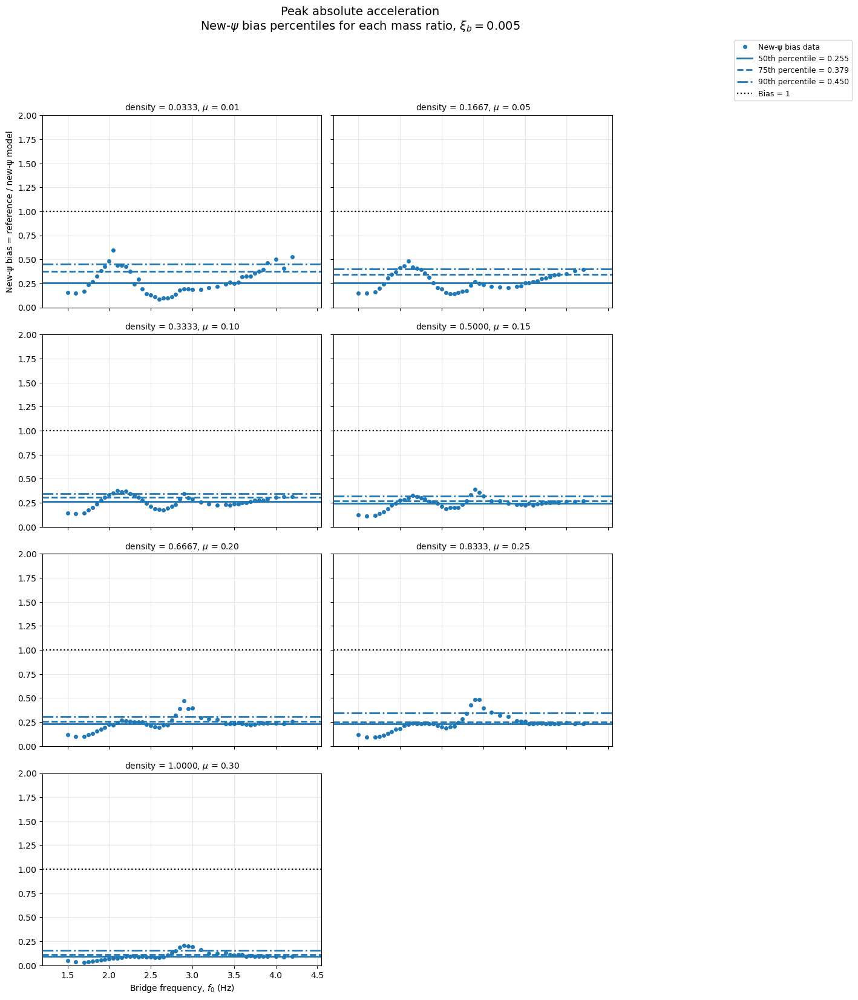


Bias percentile table:
 damping  density  mass_ratio      p50      p75      p90  n_points
   0.005   0.0333        0.01 0.255183 0.378624 0.449658        46
   0.005   0.1667        0.05 0.253381 0.341473 0.401480        46
   0.005   0.3333        0.10 0.260056 0.305138 0.342572        46
   0.005   0.5000        0.15 0.245646 0.269135 0.316446        46
   0.005   0.6667        0.20 0.233770 0.258014 0.307651        46
   0.005   0.8333        0.25 0.232971 0.250846 0.342352        46
   0.005   1.0000        0.30 0.092504 0.113200 0.155800        46


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==================================================
# SETTINGS
# ==================================================

DAMPINGS_TO_PLOT = [0.005]

FIT_MEASURE = "Peak absolute acceleration"
FIT_Y_COL = "newpsi_bias_mean"

FIT_FMIN = 1.20
FIT_FMAX = 4.55

YMIN = 0.0
YMAX = 2.0

SAVE_PERCENTILE_PLOTS = False

PERCENTILES_TO_PLOT = [50, 75, 90]

# ==================================================
# LOOP THROUGH DAMPING RATIOS AND MASS RATIOS
# ==================================================

percentile_rows = []

for damping_to_plot in DAMPINGS_TO_PLOT:

    df_plot = plot_all_df[
        np.isclose(plot_all_df["target_beamdamp"], damping_to_plot)
        & (plot_all_df["measure"].astype(str).str.strip() == FIT_MEASURE)
        & (plot_all_df["bridge_frequency"] >= FIT_FMIN)
        & (plot_all_df["bridge_frequency"] <= FIT_FMAX)
    ].copy()

    if df_plot.empty:
        print(f"No data for damping = {damping_to_plot:.3f}")
        continue

    densities = sorted(df_plot["density_key"].dropna().unique())

    ncols = 2
    nrows = math.ceil(len(densities) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(12, 4.2 * nrows),
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).ravel()

    for ax, density in zip(axes, densities):

        sub = df_plot[np.isclose(df_plot["density_key"], density)].copy()
        sub = sub.sort_values("bridge_frequency")

        x_data = sub["bridge_frequency"].to_numpy(dtype=float)
        y_data = sub[FIT_Y_COL].to_numpy(dtype=float)

        valid = (
            np.isfinite(x_data)
            & np.isfinite(y_data)
            & (x_data >= FIT_FMIN)
            & (x_data <= FIT_FMAX)
        )

        x_data = x_data[valid]
        y_data = y_data[valid]

        if len(y_data) == 0:
            ax.set_title(f"density = {density:.4f}\nNo valid data")
            ax.axis("off")
            continue

        mr = density_to_mass_ratio.get(round(float(density), 4), np.nan)

        # ==================================================
        # CALCULATE PERCENTILES
        # ==================================================

        p50 = np.percentile(y_data, 50)
        p75 = np.percentile(y_data, 75)
        p90 = np.percentile(y_data, 90)

        percentile_rows.append({
            "damping": damping_to_plot,
            "density": density,
            "mass_ratio": mr,
            "p50": p50,
            "p75": p75,
            "p90": p90,
            "n_points": len(y_data),
        })

        # ==================================================
        # PLOT DATA
        # ==================================================

        ax.plot(
            x_data,
            y_data,
            "o",
            markersize=4,
            label="New-ψ bias data",
        )

        # ==================================================
        # PLOT STRAIGHT PERCENTILE LINES
        # ==================================================

        ax.axhline(
            p50,
            linestyle="-",
            linewidth=2.0,
            label=f"50th percentile = {p50:.3f}",
        )

        ax.axhline(
            p75,
            linestyle="--",
            linewidth=2.0,
            label=f"75th percentile = {p75:.3f}",
        )

        ax.axhline(
            p90,
            linestyle="-.",
            linewidth=2.0,
            label=f"90th percentile = {p90:.3f}",
        )

        ax.axhline(
            1.0,
            color="black",
            linestyle=":",
            linewidth=1.6,
            label="Bias = 1",
        )

        ax.set_title(
            rf"density = {density:.4f}, $\mu$ = {mr:.2f}",
            fontsize=10,
        )

        ax.set_xlim(FIT_FMIN, FIT_FMAX)
        ax.set_ylim(YMIN, YMAX)
        ax.grid(True, alpha=0.30)

    # hide unused axes
    for ax in axes[len(densities):]:
        ax.axis("off")

    for ax in axes[-ncols:]:
        ax.set_xlabel(r"Bridge frequency, $f_0$ (Hz)")

    axes[0].set_ylabel("New-ψ bias = reference / new-ψ model")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        bbox_to_anchor=(1.01, 0.95),
        loc="upper left",
        fontsize=9,
    )

    fig.suptitle(
        f"{FIT_MEASURE}\n"
        rf"New-$\psi$ bias percentiles for each mass ratio, $\xi_b={damping_to_plot:.3f}$",
        fontsize=14,
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.93])

    if SAVE_PERCENTILE_PLOTS:
        safe_measure = (
            FIT_MEASURE
            .replace(" ", "_")
            .replace("%", "pct")
            .replace("/", "_")
        )

        fname = (
            f"newpsi_bias_percentiles_each_mass_ratio_"
            f"damping{damping_to_plot:.3f}_{safe_measure}.png"
        )

        fig.savefig(fname, dpi=300, bbox_inches="tight")
        print("Saved:", fname)

    plt.show()


# ==================================================
# PERCENTILE TABLE
# ==================================================

percentile_df = pd.DataFrame(percentile_rows)

print("\nBias percentile table:")
print(percentile_df.to_string(index=False))


Percentile correction factor table:
 damping  density  mass_ratio  n_points  p50_factor  p75_factor  p90_factor  p95_factor
   0.005   0.0333        0.01        50    0.266657    0.418969    0.531695    0.592852
   0.005   0.1667        0.05        50    0.268084    0.368261    0.430909    0.503371
   0.005   0.3333        0.10        50    0.271903    0.314437    0.364022    0.396191
   0.005   0.5000        0.15        50    0.248970    0.287133    0.332875    0.375758
   0.005   0.6667        0.20        50    0.236040    0.268920    0.377763    0.392723
   0.005   0.8333        0.25        50    0.233505    0.262140    0.364870    0.450427
   0.005   1.0000        0.30        50    0.093018    0.120722    0.163189    0.193201
   0.010   0.0333        0.01        50    0.324569    0.463872    0.536563    0.629494
   0.010   0.1667        0.05        50    0.317795    0.423843    0.514905    0.548667
   0.010   0.3333        0.10        50    0.323713    0.396032    0.459929    0.46

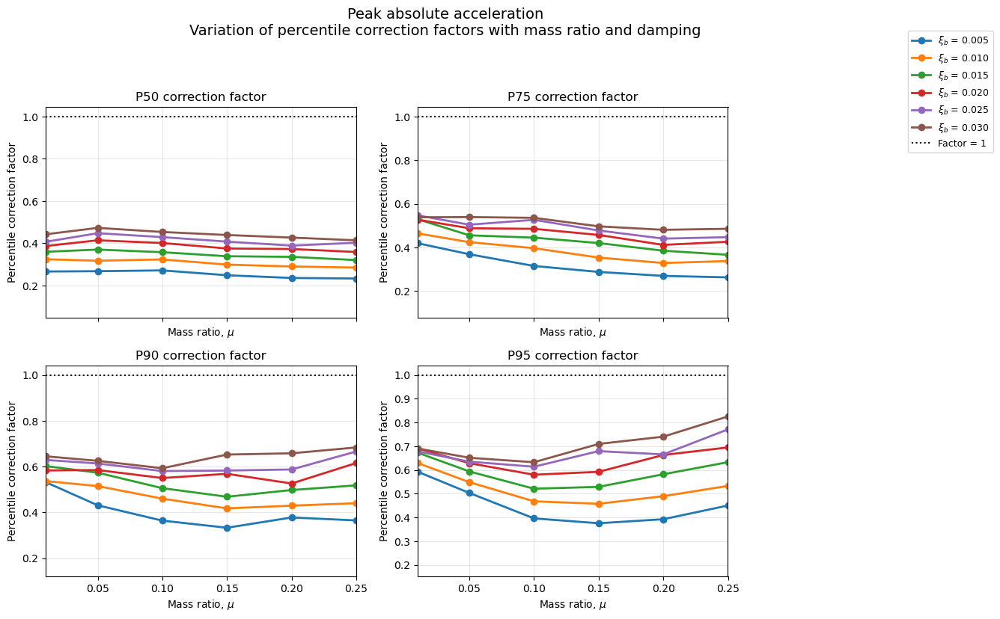

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ==================================================
# SETTINGS
# ==================================================

DAMPINGS_TO_PROCESS = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]
# If you want all damping ratios available in corrected_df, use:
# DAMPINGS_TO_PROCESS = None

MEASURE_TO_USE = "Peak absolute acceleration"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

EPS = 1e-12
PSI_MIN = 0.02

PERCENTILES_TO_CALCULATE = [50, 75, 90, 95]

EXCLUDE_DENSITY_1_FROM_PLOT = False
# Set True if you do not want density = 1.0000 in the variation plot

SAVE_PLOT = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

# ==================================================
# OLD EN1991 / SETRA psi FUNCTION
# ==================================================

def psi_w_h1_old(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    m = (x >= 1.25) & (x < 1.70)
    psi[m] = (x[m] - 1.25) / (1.70 - 1.25)

    m = (x >= 1.70) & (x <= 2.10)
    psi[m] = 1.0

    m = (x > 2.10) & (x < 2.30)
    psi[m] = 1.0 - (x[m] - 2.10) / (2.30 - 2.10)

    m = (x > 2.50) & (x < 3.40)
    psi[m] = 0.25 * (x[m] - 2.50) / (3.40 - 2.50)

    m = (x >= 3.40) & (x <= 4.20)
    psi[m] = 0.25

    m = (x > 4.20) & (x <= 4.60)
    psi[m] = 0.25 * (1.0 - (x[m] - 4.20) / (4.60 - 4.20))

    # Your additional plateau
    m = (x >= 2.25) & (x <= 3.0)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# NEW UPPER-ENVELOPE SHIFTED psi FUNCTION
# ==================================================

def psi_env_new(x):
    x = np.asarray(x, dtype=float)
    psi = np.zeros_like(x)

    m = (x >= 1.258) & (x <= 1.709)
    psi[m] = 2.2039 * x[m] - 2.7686

    m = (x > 1.709) & (x <= 1.711)
    psi[m] = 0.9382 * x[m] - 0.6056

    m = (x > 1.711) & (x <= 2.566)
    psi[m] = 1.0

    m = (x > 2.566) & (x <= 2.568)
    psi[m] = -0.6319 * x[m] + 2.6213

    m = (x > 2.568) & (x <= 2.872)
    psi[m] = -2.4653 * x[m] + 7.3299

    m = (x > 2.872) & (x <= 2.874)
    psi[m] = -0.0991 * x[m] + 0.5347

    m = (x > 2.874) & (x <= 4.191)
    psi[m] = 0.25

    m = (x > 4.191) & (x <= 4.193)
    psi[m] = -0.0880 * x[m] + 0.6190

    m = (x > 4.193) & (x <= 4.593)
    psi[m] = -0.6250 * x[m] + 2.8706

    return np.clip(psi, 0.0, 1.0)


# ==================================================
# PREPARE DATA
# ==================================================

df = corrected_df.copy()

required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "measure",
    "code_bias_mean",
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in corrected_df: {missing_cols}")

for col in [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "code_bias_mean",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["measure"] = df["measure"].astype(str).str.strip()

df["density_key"] = df["target_density"].round(4)
df["damping_key"] = df["target_beamdamp"].round(3)

if DAMPINGS_TO_PROCESS is None:
    dampings_to_use = sorted(df["damping_key"].dropna().unique())
else:
    dampings_to_use = DAMPINGS_TO_PROCESS

work_df = df[
    df["damping_key"].isin([round(d, 3) for d in dampings_to_use])
    & (df["measure"] == MEASURE_TO_USE)
    & (df["bridge_frequency"] >= PLOT_FMIN)
    & (df["bridge_frequency"] <= PLOT_FMAX)
].copy()

if work_df.empty:
    raise ValueError(
        "No data found. Check damping ratios, measure name, and frequency range."
    )

work_df = work_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
).copy()

work_df = work_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()


# ==================================================
# CALCULATE NEW-psi BIAS
# ==================================================

work_df["psi_old"] = psi_w_h1_old(
    work_df["bridge_frequency"].to_numpy()
)

work_df["psi_env"] = psi_env_new(
    work_df["bridge_frequency"].to_numpy()
)

valid_psi = (
    np.isfinite(work_df["psi_old"])
    & np.isfinite(work_df["psi_env"])
    & (work_df["psi_old"] > PSI_MIN)
    & (work_df["psi_env"] > PSI_MIN)
)

work_df["psi_ratio_old_to_env"] = np.nan

work_df.loc[valid_psi, "psi_ratio_old_to_env"] = (
    work_df.loc[valid_psi, "psi_old"]
    / work_df.loc[valid_psi, "psi_env"]
)

work_df["newpsi_code_bias_mean"] = (
    work_df["code_bias_mean"]
    * work_df["psi_ratio_old_to_env"]
)

work_df["newpsi_code_bias_mean"] = (
    work_df["newpsi_code_bias_mean"]
    .replace([np.inf, -np.inf], np.nan)
)


# ==================================================
# CALCULATE PERCENTILE FACTORS
# For each damping ratio and mass ratio
# ==================================================

percentile_rows = []

for (damping, density), sub in work_df.groupby(["damping_key", "density_key"]):

    y = sub["newpsi_code_bias_mean"].to_numpy(dtype=float)

    valid = np.isfinite(y) & (y > EPS)
    y = y[valid]

    if len(y) == 0:
        print(
            f"Skipping damping={damping:.3f}, density={density:.4f}: "
            "no valid new-psi bias values."
        )
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), np.nan)

    row = {
        "damping": damping,
        "density": density,
        "mass_ratio": mr,
        "n_points": len(y),
    }

    for p in PERCENTILES_TO_CALCULATE:
        row[f"p{p}_factor"] = np.percentile(y, p)

    percentile_rows.append(row)

percentile_factor_df = pd.DataFrame(percentile_rows)

if percentile_factor_df.empty:
    raise ValueError("No percentile factors were calculated.")

percentile_factor_df = percentile_factor_df.sort_values(
    ["damping", "mass_ratio"]
).copy()


# ==================================================
# MERGE FACTORS BACK AND CALCULATE CORRECTED BIASES
# ==================================================

work_df = work_df.merge(
    percentile_factor_df,
    left_on=["damping_key", "density_key"],
    right_on=["damping", "density"],
    how="left",
)

for p in PERCENTILES_TO_CALCULATE:
    factor_col = f"p{p}_factor"
    bias_col = f"newpsi_p{p}_bias_mean"

    work_df[bias_col] = (
        work_df["newpsi_code_bias_mean"] / work_df[factor_col]
    )

    work_df[bias_col] = (
        work_df[bias_col]
        .replace([np.inf, -np.inf], np.nan)
    )

# ==================================================
# PRINT PERCENTILE FACTOR TABLE
# ==================================================

print("\nPercentile correction factor table:")
print(percentile_factor_df.to_string(index=False))

for p in PERCENTILES_TO_CALCULATE:
    print(f"\nP{p} factor pivot table:")
    pivot = percentile_factor_df.pivot(
        index="mass_ratio",
        columns="damping",
        values=f"p{p}_factor",
    )
    print(pivot.to_string())


# ==================================================
# PLOT VARIATION OF PERCENTILE FACTORS
# WITH MASS RATIO AND DAMPING
# ==================================================

plot_factor_df = percentile_factor_df.copy()

if EXCLUDE_DENSITY_1_FROM_PLOT:
    plot_factor_df = plot_factor_df[
        ~np.isclose(plot_factor_df["density"], 1.0000)
    ].copy()

n_percentiles = len(PERCENTILES_TO_CALCULATE)

ncols = 2
nrows = math.ceil(n_percentiles / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(12, 4.2 * nrows),
    sharex=True,
)

axes = np.asarray(axes).ravel()

for ax, p in zip(axes, PERCENTILES_TO_CALCULATE):

    factor_col = f"p{p}_factor"

    for damping in sorted(plot_factor_df["damping"].dropna().unique()):

        sub = plot_factor_df[
            np.isclose(plot_factor_df["damping"], damping)
        ].copy()

        sub = sub.sort_values("mass_ratio")

        ax.plot(
            sub["mass_ratio"],
            sub[factor_col],
            marker="o",
            linewidth=2.0,
            label=rf"$\xi_b$ = {damping:.3f}",
        )

    ax.axhline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label="Factor = 1" if p == PERCENTILES_TO_CALCULATE[0] else None,
    )

    ax.set_title(f"P{p} correction factor")
    ax.set_xlabel(r"Mass ratio, $\mu$")
    ax.set_xlim(0.01, 0.25)
    ax.set_ylabel("Percentile correction factor")
    ax.grid(True, alpha=0.30)

# Hide unused axes
for ax in axes[n_percentiles:]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.01, 0.95),
    loc="upper left",
    fontsize=9,
)

fig.suptitle(
    f"{MEASURE_TO_USE}\n"
    "Variation of percentile correction factors with mass ratio and damping",
    fontsize=14,
)

fig.tight_layout(rect=[0, 0, 0.84, 0.93])

if SAVE_PLOT:
    safe_measure = (
        MEASURE_TO_USE
        .replace(" ", "_")
        .replace("%", "pct")
        .replace("/", "_")
    )

    fname = f"percentile_factor_variation_{safe_measure}.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight")
    print("Saved:", fname)

plt.show()

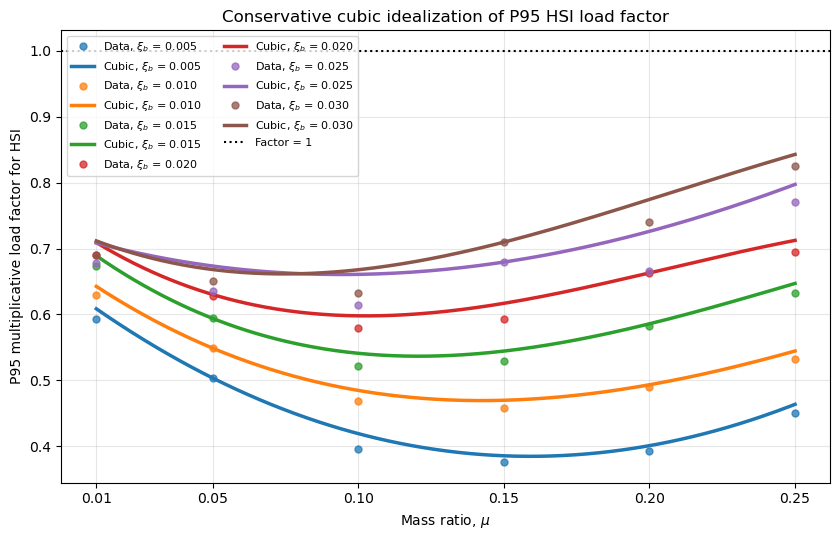


Idealized cubic P95 factors:
 damping  mass_ratio  p95_factor_raw  p95_factor_ideal_cubic
   0.005        0.01        0.592852                0.608527
   0.005        0.05        0.503371                0.503371
   0.005        0.10        0.396191                0.419025
   0.005        0.15        0.375758                0.385413
   0.005        0.20        0.392723                0.400825
   0.005        0.25        0.450427                0.463548
   0.010        0.01        0.629494                0.642526
   0.010        0.05        0.548667                0.548667
   0.010        0.10        0.468126                0.484603
   0.010        0.15        0.457704                0.469704
   0.010        0.20        0.489675                0.493239
   0.010        0.25        0.532978                0.544478
   0.015        0.01        0.673052                0.689017
   0.015        0.05        0.593887                0.593887
   0.015        0.10        0.521206                0.5

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================================================
# IDEALIZE P95 FACTORS USING ONE CONSERVATIVE CUBIC
# PER DAMPING RATIO
# ==================================================

PERCENTILE_TO_IDEALIZE = 95
FACTOR_COL = f"p{PERCENTILE_TO_IDEALIZE}_factor"

SAFETY_MARGIN = 0.00
CAP_AT_ONE = True

# Use rho < 1 only, so exclude mu = 0.30 if present
EXCLUDE_MU_030 = True

color_map = {
    0.005: "tab:blue",
    0.010: "tab:orange",
    0.015: "tab:green",
    0.020: "tab:red",
    0.025: "tab:purple",
    0.030: "tab:brown",
}

fit_df = percentile_factor_df.copy()

fit_df["damping"] = pd.to_numeric(fit_df["damping"], errors="coerce")
fit_df["mass_ratio"] = pd.to_numeric(fit_df["mass_ratio"], errors="coerce")
fit_df[FACTOR_COL] = pd.to_numeric(fit_df[FACTOR_COL], errors="coerce")

fit_df = fit_df.dropna(subset=["damping", "mass_ratio", FACTOR_COL]).copy()

if EXCLUDE_MU_030:
    fit_df = fit_df[~np.isclose(fit_df["mass_ratio"], 0.30)].copy()

fit_df = fit_df.sort_values(["damping", "mass_ratio"]).copy()

equation_rows = []
idealized_rows = []

fig, ax = plt.subplots(figsize=(8.5, 5.5))

for damping in sorted(fit_df["damping"].unique()):

    sub = fit_df[np.isclose(fit_df["damping"], damping)].copy()
    sub = sub.sort_values("mass_ratio")

    x = sub["mass_ratio"].to_numpy(dtype=float)
    y = sub[FACTOR_COL].to_numpy(dtype=float)

    if len(x) < 4:
        print(f"Skipping xi_b = {damping:.3f}: cubic needs at least 4 points.")
        continue

    # Cubic fit:
    # C95(mu) = a*mu^3 + b*mu^2 + c*mu + d
    a, b, c, d = np.polyfit(x, y, 3)

    # Shift upward so the cubic is conservative at all calculated P95 points
    y_fit_at_data = a*x**3 + b*x**2 + c*x + d
    upward_shift = np.max(y - y_fit_at_data)

    d_safe = d + upward_shift + SAFETY_MARGIN

    y_ideal_at_data = a*x**3 + b*x**2 + c*x + d_safe

    if CAP_AT_ONE:
        y_ideal_at_data = np.minimum(y_ideal_at_data, 1.0)

    for mu, raw_factor, ideal_factor in zip(x, y, y_ideal_at_data):
        idealized_rows.append({
            "damping": damping,
            "mass_ratio": mu,
            "p95_factor_raw": raw_factor,
            "p95_factor_ideal_cubic": ideal_factor,
        })

    equation_rows.append({
        "damping": damping,
        "a": a,
        "b": b,
        "c": c,
        "d_safe": d_safe,
        "equation": rf"$C_{{95}} = {a:.3f}\mu^3 + {b:.3f}\mu^2 + {c:.3f}\mu + {d_safe:.3f}$"
    })

    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = a*x_smooth**3 + b*x_smooth**2 + c*x_smooth + d_safe

    if CAP_AT_ONE:
        y_smooth = np.minimum(y_smooth, 1.0)

    color = color_map.get(round(float(damping), 3), None)

    # Raw P95 points
    ax.plot(
        x,
        y,
        marker="o",
        linestyle="none",
        markersize=5,
        color=color,
        alpha=0.75,
        label=rf"Data, $\xi_b$ = {damping:.3f}"
    )

    # Idealized cubic curve
    ax.plot(
        x_smooth,
        y_smooth,
        linewidth=2.5,
        color=color,
        label=rf"Cubic, $\xi_b$ = {damping:.3f}"
    )

ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label="Factor = 1"
)

ax.set_xlabel(r"Mass ratio, $\mu$")
ax.set_ylabel("P95 multiplicative load factor for HSI")
ax.set_title("Conservative cubic idealization of P95 HSI load factor")
ax.set_xticks(sorted(fit_df["mass_ratio"].unique()))
ax.grid(True, alpha=0.30)
ax.legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

p95_idealized_cubic_df = pd.DataFrame(idealized_rows)
p95_cubic_equation_df = pd.DataFrame(equation_rows)

print("\nIdealized cubic P95 factors:")
print(p95_idealized_cubic_df.to_string(index=False))

print("\nCubic equations:")
print(p95_cubic_equation_df.to_string(index=False))

Loaded: NMFR_2.pkl
Bands: ['1.25_to_4.60']
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]


C:\Users\slok0019\AppData\Local\Temp\ipykernel_20604\1746075228.py:637: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


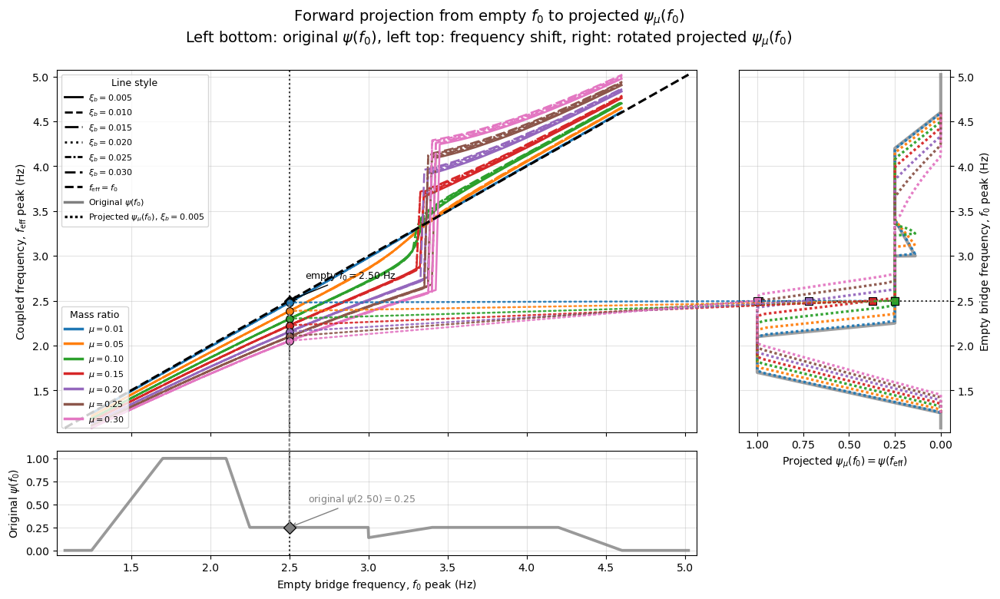


Mapping at empty frequency f0 = 2.50 Hz
---------------------------------------------------------
mu      f_eff(f0=2.50)      projected psi = psi(f_eff)
---------------------------------------------------------
0.01    2.480               0.250
0.05    2.386               0.250
0.10    2.300               0.250
0.15    2.226               0.370
0.20    2.156               0.720
0.25    2.102               0.990
0.30    2.053               1.000


In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch

# ==================================================
# LOAD SAVED NMFR RESULTS
# ==================================================

pkl_file = "NMFR_2.pkl"

with open(pkl_file, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
frequency_bands = saved["frequency_bands"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(frequency_bands.keys())

print("Loaded:", pkl_file)
print("Bands:", bands_to_combine)
print("Densities:", densities)
print("Damping values:", damping_values)


# ==================================================
# DENSITY TO MASS RATIO LABEL
# ==================================================

mass_ratio_label = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
    1.0:    0.30,
}


# ==================================================
# UPDATED ORIGINAL PSI FUNCTION
# Minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz
# ==================================================

def psi_original(f):
    """
    Original pedestrian excitation reduction function ψ(f),
    with minimum ψ = 0.25 between 2.25 Hz and 3.00 Hz.
    """

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz : ramp from 0 to 1
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (f[m] - 1.25) / (1.70 - 1.25)

    # 1.70–2.10 Hz : full value = 1
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz : ramp from 1 to 0
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (2.30 - f[m]) / (2.30 - 2.10)

    # 2.30–2.50 Hz : zero
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz : ramp from 0 to 0.25
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = 0.25 * (f[m] - 2.50) / (3.40 - 2.50)

    # 3.40–4.20 Hz : constant 0.25
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz : ramp from 0.25 to 0
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = 0.25 * (4.60 - f[m]) / (4.60 - 4.20)

    # Minimum ψ = 0.25 for 2.25 Hz <= f <= 3.00 Hz
    m = (f >= 2.25) & (f <= 3.00)
    psi[m] = np.maximum(psi[m], 0.25)

    return psi


# ==================================================
# HELPER FUNCTION: COLLECT f0_peak AND f_eff_peak
# ==================================================

def collect_f0_feff(results_all, bands_to_combine, beamdamp, density):
    x_vals = []
    y_vals = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        if beamdamp not in results_all[band_name]:
            continue

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            if density not in freq_dict[bf]:
                continue

            data = freq_dict[bf][density]

            f0_arr = np.asarray(data["f0_peak"], dtype=float).reshape(-1)
            feff_arr = np.asarray(data["f_eff_peak"], dtype=float).reshape(-1)

            valid = np.isfinite(f0_arr) & np.isfinite(feff_arr)

            if np.any(valid):
                x_vals.append(np.nanmean(f0_arr[valid]))
                y_vals.append(np.nanmean(feff_arr[valid]))

    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)

    if len(x_vals) == 0:
        return x_vals, y_vals

    order = np.argsort(x_vals)
    return x_vals[order], y_vals[order]


# ==================================================
# SETTINGS
# ==================================================

TARGET_F0 = 2.50
PROJECT_DAMPING = 0.005

line_styles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (3, 1, 1, 1)),
    (0, (5, 2)),
]

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

density_to_color = {
    density: default_colors[i % len(default_colors)]
    for i, density in enumerate(densities)
}


# ==================================================
# FIGURE LAYOUT
# left top     : frequency shift, f0 vs f_eff
# left bottom  : original psi(f0)
# right top    : rotated projected psi, x = psi, y = f0
# right bottom : blank
# ==================================================

fig = plt.figure(figsize=(15, 8.2))

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[5.0, 1.65],
    height_ratios=[4.7, 1.35],
    wspace=0.10,
    hspace=0.08
)

ax_main = fig.add_subplot(gs[0, 0])
ax_orig = fig.add_subplot(gs[1, 0], sharex=ax_main)

# right graph: y-axis is frequency and shares with ax_main
ax_proj = fig.add_subplot(gs[0, 1], sharey=ax_main)

ax_blank = fig.add_subplot(gs[1, 1])
ax_blank.axis("off")


# ==================================================
# MAIN PLOT: f0_peak vs f_eff_peak
# colour = mass ratio
# line style = damping ratio
# ==================================================

all_x = []
all_y = []

for density in densities:

    color = density_to_color[density]

    for i, beamdamp in enumerate(damping_values):

        ls = line_styles[i % len(line_styles)]

        x_vals, y_vals = collect_f0_feff(
            results_all=results_all,
            bands_to_combine=bands_to_combine,
            beamdamp=beamdamp,
            density=density
        )

        if len(x_vals) == 0:
            continue

        all_x.extend(x_vals)
        all_y.extend(y_vals)

        ax_main.plot(
            x_vals,
            y_vals,
            color=color,
            linestyle=ls,
            linewidth=1.8,
            label="_nolegend_"
        )

all_x = np.asarray(all_x, dtype=float)
all_y = np.asarray(all_y, dtype=float)

lo = min(np.nanmin(all_x), np.nanmin(all_y))
hi = max(np.nanmax(all_x), np.nanmax(all_y))

# no-shift reference line
ax_main.plot(
    [lo, hi],
    [lo, hi],
    linestyle="--",
    linewidth=2.2,
    color="black",
    label="_nolegend_"
)


# ==================================================
# BOTTOM LEFT: ORIGINAL psi(f0)
# ==================================================

f_grid = np.linspace(lo, hi, 1500)
psi_grid = psi_original(f_grid)

ax_orig.plot(
    f_grid,
    psi_grid,
    color="gray",
    linestyle="-",
    linewidth=2.7,
    alpha=0.80,
    label=r"Original $\psi(f_0)$"
)

psi_at_target = float(psi_original(np.array([TARGET_F0]))[0])

ax_orig.plot(
    TARGET_F0,
    psi_at_target,
    marker="D",
    markersize=8,
    color="gray",
    markeredgecolor="black",
    markeredgewidth=0.9,
    zorder=20
)

ax_orig.axvline(
    TARGET_F0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.80
)

ax_orig.annotate(
    fr"original $\psi({TARGET_F0:.2f})={psi_at_target:.2f}$",
    xy=(TARGET_F0, psi_at_target),
    xytext=(TARGET_F0 + 0.12, min(1.0, psi_at_target + 0.28)),
    fontsize=9,
    color="gray",
    arrowprops=dict(arrowstyle="->", color="gray", lw=1.0)
)


# ==================================================
# RIGHT ROTATED PANEL:
# x = projected psi magnitude
# y = empty bridge frequency f0
#
# This is the 90-degree rotated version of:
# x = f0, y = projected psi
# ==================================================

# Original psi, rotated
ax_proj.plot(
    psi_grid,
    f_grid,
    color="gray",
    linestyle="-",
    linewidth=3.0,
    alpha=0.75,
    label=r"Original $\psi(f_0)$"
)

projected_curve_cache = {}

for density in densities:

    color = density_to_color[density]
    mu_val = mass_ratio_label.get(round(float(density), 4), density)

    x_vals, feff_vals = collect_f0_feff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp=PROJECT_DAMPING,
        density=density
    )

    if len(x_vals) == 0:
        continue

    x_vals = np.asarray(x_vals, dtype=float)
    feff_vals = np.asarray(feff_vals, dtype=float)

    order = np.argsort(x_vals)
    x_vals = x_vals[order]
    feff_vals = feff_vals[order]

    psi_projected = psi_original(feff_vals)

    projected_curve_cache[density] = {
        "x_vals": x_vals,
        "feff_vals": feff_vals,
        "psi_projected": psi_projected,
        "mu_val": mu_val
    }

    # Rotated projected curve:
    # x = psi_projected
    # y = f0
    ax_proj.plot(
        psi_projected,
        x_vals,
        color=color,
        linestyle=(0, (1, 1)),
        linewidth=2.4,
        alpha=0.95,
        label="_nolegend_"
    )


# ==================================================
# SHOW THE MAPPING OF f0 = 2.50
#
# bottom original psi -> main f_eff point -> rotated right projected psi point
# ==================================================

main_ref_point = (TARGET_F0, TARGET_F0)

ax_main.plot(
    main_ref_point[0],
    main_ref_point[1],
    marker="D",
    markersize=7,
    color="black",
    markeredgecolor="black",
    zorder=20
)

ax_main.axvline(
    TARGET_F0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.80
)

ax_main.annotate(
    fr"empty $f_0={TARGET_F0:.2f}$ Hz",
    xy=main_ref_point,
    xytext=(TARGET_F0 + 0.10, TARGET_F0 + 0.25),
    fontsize=9,
    color="black",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0)
)

# connect bottom original point -> main reference point
con_start = ConnectionPatch(
    xyA=(TARGET_F0, psi_at_target),
    coordsA=ax_orig.transData,
    xyB=main_ref_point,
    coordsB=ax_main.transData,
    axesA=ax_orig,
    axesB=ax_main,
    color="gray",
    linestyle=":",
    linewidth=1.7,
    alpha=0.90
)
fig.add_artist(con_start)


# Horizontal target line on rotated right panel:
# y = empty f0 = TARGET_F0
ax_proj.axhline(
    TARGET_F0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.80
)


# For each mass ratio:
# read f_eff at f0 = TARGET_F0,
# compute psi(f_eff),
# plot on rotated right panel at y = TARGET_F0
mapping_rows = []

for density in densities:

    if density not in projected_curve_cache:
        continue

    color = density_to_color[density]
    mu_val = projected_curve_cache[density]["mu_val"]

    x_vals = projected_curve_cache[density]["x_vals"]
    feff_vals = projected_curve_cache[density]["feff_vals"]

    if TARGET_F0 < np.nanmin(x_vals) or TARGET_F0 > np.nanmax(x_vals):
        continue

    feff_now = np.interp(TARGET_F0, x_vals, feff_vals)
    psi_new_now = float(psi_original(np.array([feff_now]))[0])

    mapping_rows.append({
        "mu": mu_val,
        "f0": TARGET_F0,
        "feff": feff_now,
        "psi_projected": psi_new_now,
    })

    # point in main plot:
    # x = empty f0
    # y = coupled f_eff
    main_point = (TARGET_F0, feff_now)

    ax_main.plot(
        main_point[0],
        main_point[1],
        marker="o",
        markersize=7,
        color=color,
        markeredgecolor="black",
        markeredgewidth=0.8,
        zorder=25
    )

    # point in rotated right panel:
    # x = projected psi
    # y = empty f0
    proj_point = (psi_new_now, TARGET_F0)

    ax_proj.plot(
        proj_point[0],
        proj_point[1],
        marker="s",
        markersize=7,
        color=color,
        markeredgecolor="black",
        markeredgewidth=0.8,
        zorder=25
    )

    # connector from main frequency-shift point to rotated projected-psi point
    con_mid = ConnectionPatch(
        xyA=main_point,
        coordsA=ax_main.transData,
        xyB=proj_point,
        coordsB=ax_proj.transData,
        axesA=ax_main,
        axesB=ax_proj,
        color=color,
        linestyle=":",
        linewidth=1.8,
        alpha=0.90
    )
    fig.add_artist(con_mid)





# ==================================================
# LEGENDS
# ==================================================

# Mass ratio legend
color_handles = []

for density in densities:
    mu_val = mass_ratio_label.get(round(float(density), 4), density)
    color = density_to_color[density]

    color_handles.append(
        Line2D(
            [0], [0],
            color=color,
            linestyle="-",
            linewidth=2.5,
            label=fr"$\mu={mu_val:.2f}$"
        )
    )

legend1 = ax_main.legend(
    handles=color_handles,
    title="Mass ratio",
    loc="lower left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)
ax_main.add_artist(legend1)


# line-style legend
style_handles = []

for i, damp in enumerate(damping_values):
    style_handles.append(
        Line2D(
            [0], [0],
            color="black",
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2.0,
            label=fr"$\xi_b={damp:.3f}$"
        )
    )

style_handles.append(
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=2.2,
        label=r"$f_{\mathrm{eff}}=f_0$"
    )
)

style_handles.append(
    Line2D(
        [0], [0],
        color="gray",
        linestyle="-",
        linewidth=2.5,
        label=r"Original $\psi(f_0)$"
    )
)

style_handles.append(
    Line2D(
        [0], [0],
        color="black",
        linestyle=(0, (1, 1)),
        linewidth=2.4,
        label=fr"Projected $\psi_\mu(f_0)$, $\xi_b={PROJECT_DAMPING:.3f}$"
    )
)

legend2 = ax_main.legend(
    handles=style_handles,
    title="Line style",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)


# ==================================================
# AXIS FORMATTING
# ==================================================

ax_main.set_ylabel(r"Coupled frequency, $f_{\mathrm{eff}}$ peak (Hz)")
ax_main.grid(True, alpha=0.35)

ax_orig.set_xlabel(r"Empty bridge frequency, $f_0$ peak (Hz)")
ax_orig.set_ylabel(r"Original $\psi(f_0)$")
ax_orig.set_ylim(-0.05, 1.08)
ax_orig.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])
ax_orig.grid(True, alpha=0.35)

# Rotated projected-psi panel formatting
ax_proj.set_xlabel(r"Projected $\psi_\mu(f_0)=\psi(f_{\mathrm{eff}})$")
ax_proj.set_ylabel(r"Empty bridge frequency, $f_0$ peak (Hz)")

# ==================================================
# IMPORTANT CHANGE:
# Flip right-side x-axis so 1 is left and 0 is right
# ==================================================

ax_proj.set_xlim(1.10, -0.05)
ax_proj.set_xticks([1.00, 0.75, 0.50, 0.25, 0.00])

ax_proj.grid(True, alpha=0.35)

# put y ticks on right side for projected panel
ax_proj.yaxis.tick_right()
ax_proj.yaxis.set_label_position("right")

# keep frequency range aligned between main y-axis and right-panel y-axis
ax_main.set_xlim(lo - 0.05, hi + 0.05)
ax_main.set_ylim(lo - 0.05, hi + 0.05)
ax_proj.set_ylim(ax_main.get_ylim())

# hide top-main x tick labels
plt.setp(ax_main.get_xticklabels(), visible=False)

fig.suptitle(
    r"Forward projection from empty $f_0$ to projected $\psi_\mu(f_0)$"
    "\n"
    r"Left bottom: original $\psi(f_0)$, left top: frequency shift, right: rotated projected $\psi_\mu(f_0)$",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ==================================================
# PRINT MAPPING TABLE AT f0 = 2.50
# ==================================================

print("\nMapping at empty frequency f0 = {:.2f} Hz".format(TARGET_F0))
print("---------------------------------------------------------")
print("mu      f_eff(f0=2.50)      projected psi = psi(f_eff)")
print("---------------------------------------------------------")

for row in mapping_rows:
    print(
        f"{row['mu']:.2f}    "
        f"{row['feff']:.3f}               "
        f"{row['psi_projected']:.3f}"
    )


Effective-frequency key being used: f_eff_peak


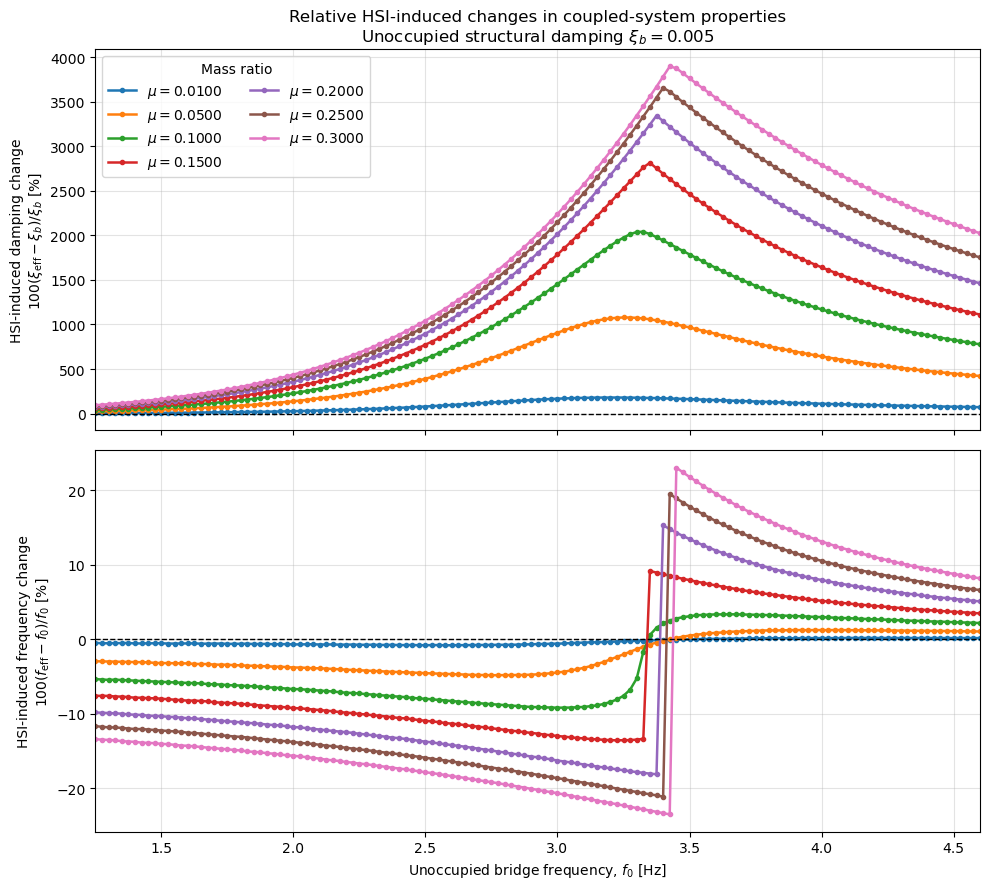

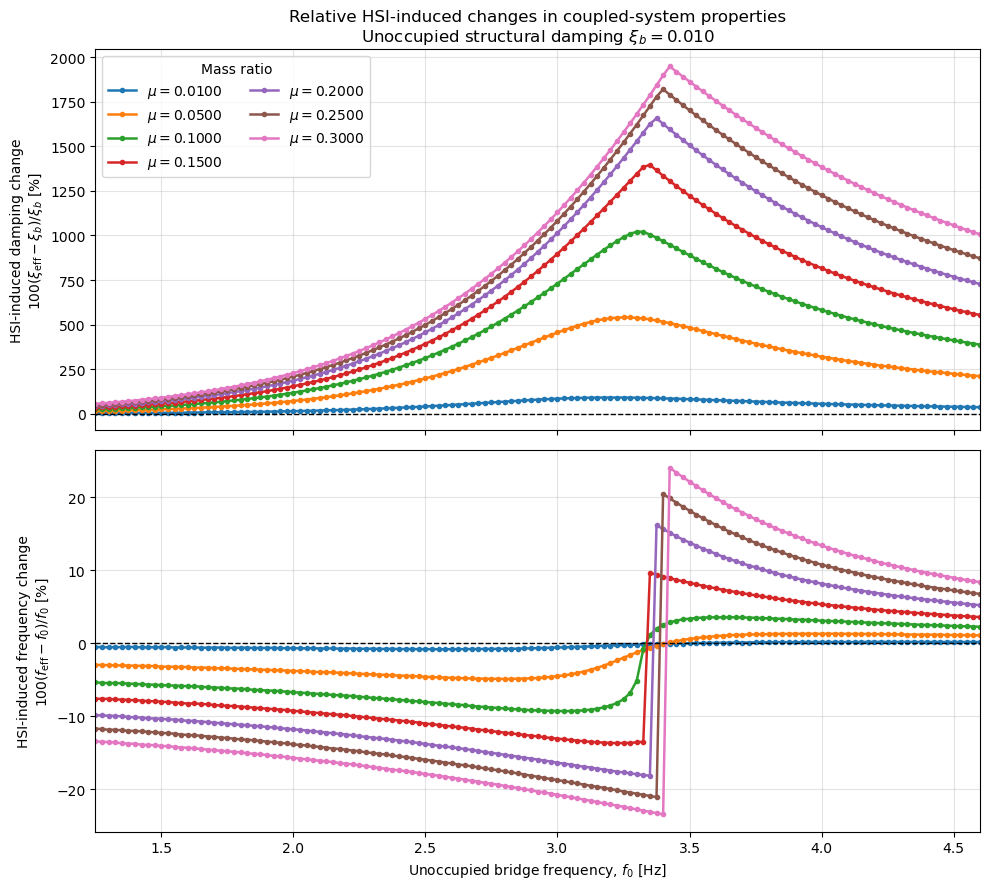

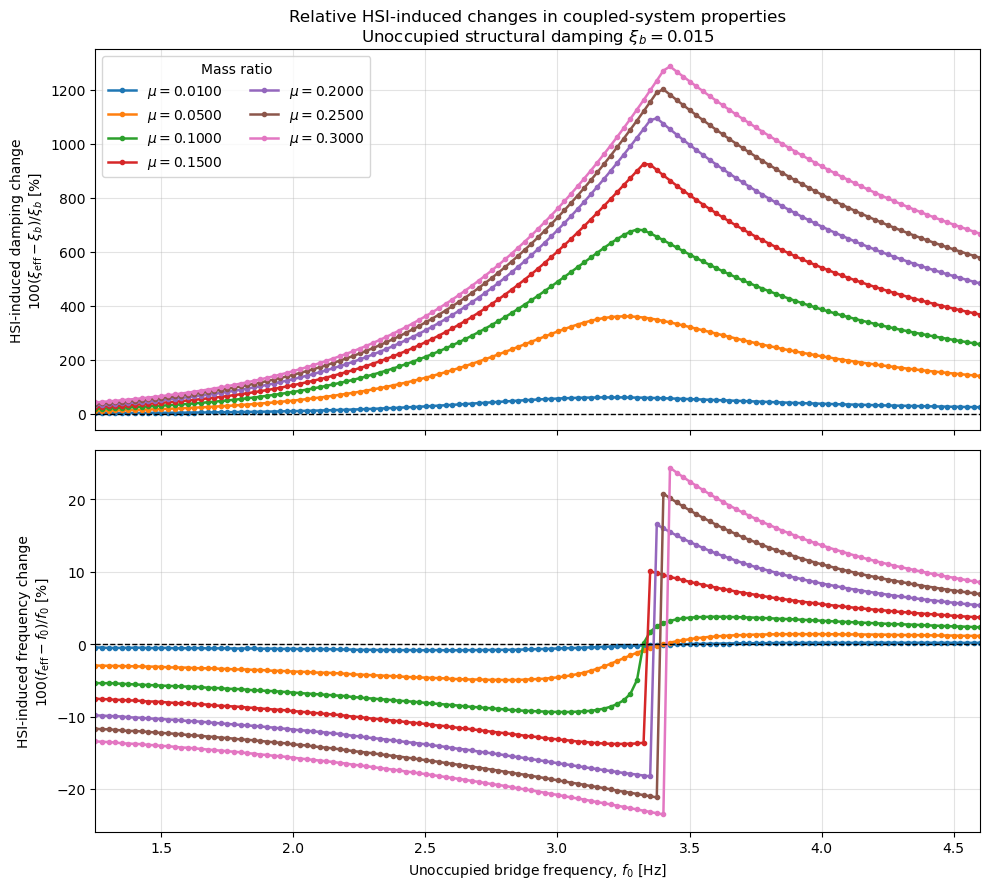

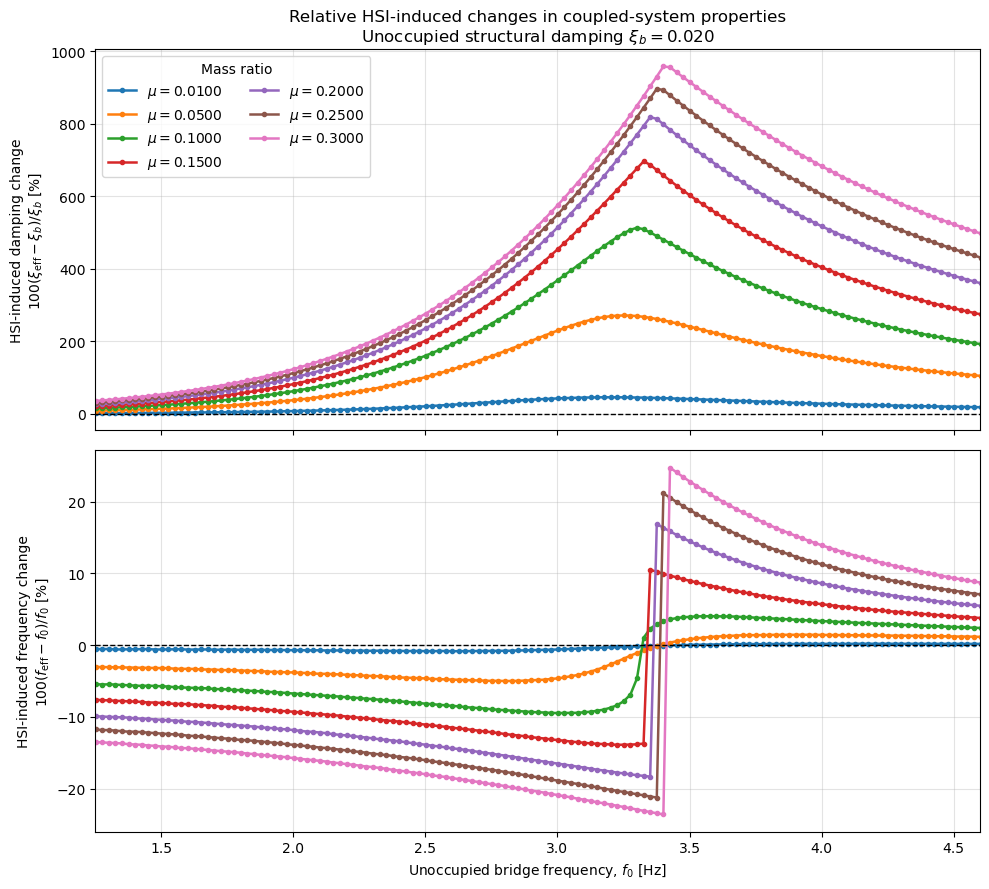

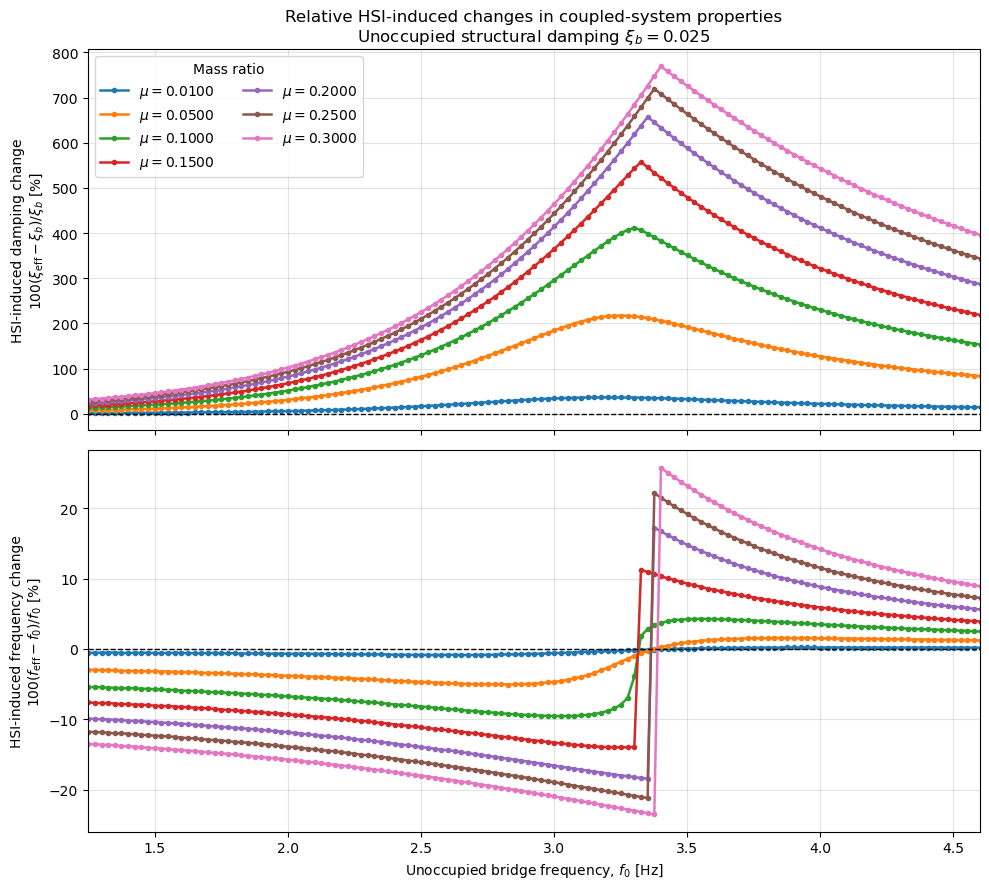

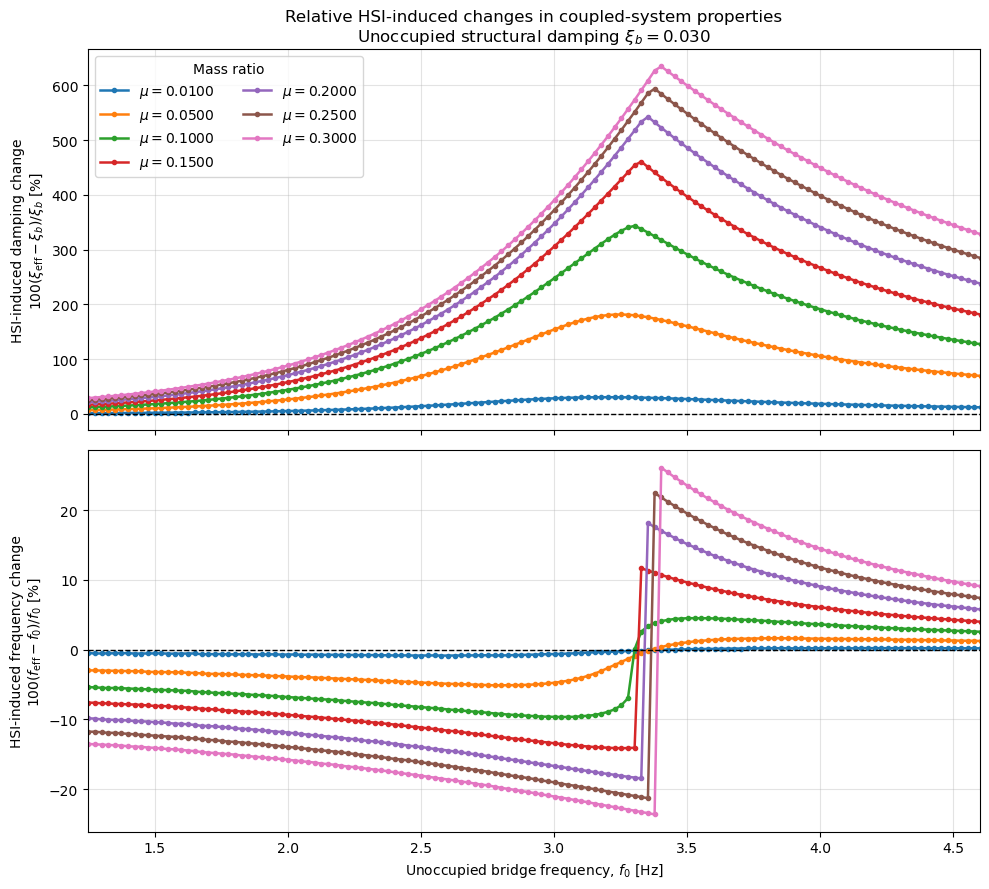


HSI-INDUCED DAMPING AND FREQUENCY CHANGE SUMMARY
 xi_b   mu  mean_damping_change_pct  min_damping_change_pct  max_damping_change_pct  range_damping_change_percentage_points  mean_frequency_change_pct  min_frequency_change_pct  max_frequency_change_pct  range_frequency_change_percentage_points  mean_abs_frequency_change_pct  max_abs_frequency_change_pct
0.005 0.01                   90.432                   4.638                 180.366                                 175.729                     -0.351                    -0.816                     0.171                                     0.986                          0.437                         0.816
0.005 0.05                  508.281                  24.071                1078.364                                1054.292                     -2.005                    -4.836                     1.235                                     6.071                          2.743                         4.836
0.005 0.10                  889.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

PLOT_FMIN = 1.25
PLOT_FMAX = 4.60

# Possible names for the coupled/effective frequency stored
# inside NMFR_2.pkl.
F_EFF_KEY_CANDIDATES = [
    "f_eff_peak",
    "feff_peak",
    "f_eff",
    "feff",
    "coupled_frequency",
    "effective_frequency",
]


# ============================================================
# HELPER: FIND EFFECTIVE-FREQUENCY KEY
# ============================================================

def find_feff_key(data):

    for key in F_EFF_KEY_CANDIDATES:
        if key in data:
            return key

    raise KeyError(
        "\nCould not find the coupled/effective frequency key.\n"
        f"Available keys are:\n{list(data.keys())}\n\n"
        "Add the correct key name to F_EFF_KEY_CANDIDATES."
    )


# ============================================================
# COLLECT HSI-INDUCED CHANGES
#
# Damping:
#     xi_eff = xi_b / frf_ratio
#
#     damping change (%) =
#         100 * (xi_eff - xi_b) / xi_b
#
# Frequency:
#     frequency change (%) =
#         100 * (f_eff - f0) / f0
#
# Positive frequency change:
#     coupled frequency > unoccupied frequency
#
# Negative frequency change:
#     coupled frequency < unoccupied frequency
# ============================================================

def collect_hsi_changes(
    results_all,
    bands_to_combine,
    beamdamp,
    density
):

    freq_to_f0 = {}
    freq_to_xieff = {}
    freq_to_feff = {}

    freq_to_damp_pct = {}
    freq_to_freq_pct = {}

    for band_name in bands_to_combine:

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            data = freq_dict[bf][density]

            # --------------------------------------------
            # Stored quantities
            # --------------------------------------------
            f0_arr = np.asarray(
                data["f0_peak"],
                dtype=float
            ).reshape(-1)

            frf_ratio = np.asarray(
                data["frf_ratio"],
                dtype=float
            ).reshape(-1)

            feff_key = find_feff_key(data)

            feff_arr = np.asarray(
                data[feff_key],
                dtype=float
            ).reshape(-1)

            # --------------------------------------------
            # Align array lengths
            # --------------------------------------------
            n = min(
                len(f0_arr),
                len(frf_ratio),
                len(feff_arr)
            )

            f0_arr = f0_arr[:n]
            frf_ratio = frf_ratio[:n]
            feff_arr = feff_arr[:n]

            valid = (
                np.isfinite(f0_arr)
                & np.isfinite(frf_ratio)
                & np.isfinite(feff_arr)
                & (f0_arr > 0)
                & (frf_ratio > 0)
            )

            if not np.any(valid):
                continue

            f0_arr = f0_arr[valid]
            frf_ratio = frf_ratio[valid]
            feff_arr = feff_arr[valid]

            # ============================================
            # EFFECTIVE DAMPING
            # ============================================

            xi_eff_arr = beamdamp / frf_ratio

            # HSI-induced damping change relative to
            # original structural damping
            damp_pct_arr = (
                100.0
                * (xi_eff_arr - beamdamp)
                / beamdamp
            )

            # ============================================
            # EFFECTIVE FREQUENCY
            # ============================================

            freq_pct_arr = (
                100.0
                * (feff_arr - f0_arr)
                / f0_arr
            )

            # ============================================
            # STORE BY BRIDGE-FREQUENCY POINT
            # ============================================

            if bf not in freq_to_f0:
                freq_to_f0[bf] = []
                freq_to_xieff[bf] = []
                freq_to_feff[bf] = []
                freq_to_damp_pct[bf] = []
                freq_to_freq_pct[bf] = []

            freq_to_f0[bf].append(
                np.nanmean(f0_arr)
            )

            freq_to_xieff[bf].append(
                np.nanmean(xi_eff_arr)
            )

            freq_to_feff[bf].append(
                np.nanmean(feff_arr)
            )

            # Mean percentage effect across realizations
            freq_to_damp_pct[bf].append(
                np.nanmean(damp_pct_arr)
            )

            freq_to_freq_pct[bf].append(
                np.nanmean(freq_pct_arr)
            )

    # ====================================================
    # COLLAPSE DUPLICATE BAND POINTS
    # ====================================================

    bfs = sorted(freq_to_f0.keys())

    f0_vals = np.array([
        np.nanmean(freq_to_f0[bf])
        for bf in bfs
    ])

    xi_eff_vals = np.array([
        np.nanmean(freq_to_xieff[bf])
        for bf in bfs
    ])

    feff_vals = np.array([
        np.nanmean(freq_to_feff[bf])
        for bf in bfs
    ])

    damping_pct_vals = np.array([
        np.nanmean(freq_to_damp_pct[bf])
        for bf in bfs
    ])

    frequency_pct_vals = np.array([
        np.nanmean(freq_to_freq_pct[bf])
        for bf in bfs
    ])

    # Sort explicitly by f0
    order = np.argsort(f0_vals)

    return (
        f0_vals[order],
        xi_eff_vals[order],
        feff_vals[order],
        damping_pct_vals[order],
        frequency_pct_vals[order],
    )


# ============================================================
# CHECK WHICH EFFECTIVE-FREQUENCY KEY IS BEING USED
# ============================================================

first_band = bands_to_combine[0]
first_damping = damping_values[0]
first_bf = sorted(
    results_all[first_band][first_damping].keys()
)[0]
first_density = densities[0]

example_data = results_all[
    first_band
][first_damping][first_bf][first_density]

feff_key_used = find_feff_key(example_data)

print(
    "\nEffective-frequency key being used:",
    feff_key_used
)


# ============================================================
# PLOT
#
# ONE FIGURE PER UNOCCUPIED STRUCTURAL DAMPING
#
# TOP:
#   HSI-induced damping change (%)
#
# BOTTOM:
#   HSI-induced frequency change (%)
#
# Lines:
#   different mass ratios
# ============================================================

for beamdamp in damping_values:

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 9),
        sharex=True
    )

    ax_damp = axes[0]
    ax_freq = axes[1]

    for density in densities:

        mu = mass_ratio_label[density]

        (
            f0_vals,
            xi_eff_vals,
            feff_vals,
            damping_pct_vals,
            frequency_pct_vals,
        ) = collect_hsi_changes(
            results_all=results_all,
            bands_to_combine=bands_to_combine,
            beamdamp=beamdamp,
            density=density
        )

        # --------------------------------------------
        # DAMPING CHANGE
        # --------------------------------------------
        ax_damp.plot(
            f0_vals,
            damping_pct_vals,
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=fr"$\mu={mu:.4f}$"
        )

        # --------------------------------------------
        # FREQUENCY CHANGE
        # --------------------------------------------
        ax_freq.plot(
            f0_vals,
            frequency_pct_vals,
            marker="o",
            markersize=3,
            linewidth=1.8,
            label=fr"$\mu={mu:.4f}$"
        )

    # ========================================================
    # FORMAT DAMPING PANEL
    # ========================================================

    ax_damp.axhline(
        0,
        linestyle="--",
        linewidth=1.0,
        color="black"
    )

    ax_damp.set_ylabel(
        r"HSI-induced damping change"
        "\n"
        r"$100(\xi_{\mathrm{eff}}-\xi_b)/\xi_b$ [%]"
    )

    ax_damp.set_title(
        r"Relative HSI-induced changes in coupled-system properties"
        "\n"
        fr"Unoccupied structural damping $\xi_b={beamdamp:.3f}$"
    )

    ax_damp.grid(True, alpha=0.35)

    ax_damp.legend(
        title="Mass ratio",
        ncol=2
    )

    # ========================================================
    # FORMAT FREQUENCY PANEL
    # ========================================================

    ax_freq.axhline(
        0,
        linestyle="--",
        linewidth=1.0,
        color="black"
    )

    ax_freq.set_xlabel(
        r"Unoccupied bridge frequency, $f_0$ [Hz]"
    )

    ax_freq.set_ylabel(
        r"HSI-induced frequency change"
        "\n"
        r"$100(f_{\mathrm{eff}}-f_0)/f_0$ [%]"
    )

    ax_freq.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )

    ax_freq.grid(True, alpha=0.35)

    plt.tight_layout()
    plt.show()


# ============================================================
# SUMMARY TABLE
#
# For every:
#     xi_b
#     mu
#
# report variation across the entire f0 band.
#
# This lets you compare the magnitude of:
#
# 1. HSI-induced damping modification
# 2. HSI-induced frequency modification
# ============================================================

summary_rows = []

for beamdamp in damping_values:

    for density in densities:

        mu = mass_ratio_label[density]

        (
            f0_vals,
            xi_eff_vals,
            feff_vals,
            damping_pct_vals,
            frequency_pct_vals,
        ) = collect_hsi_changes(
            results_all=results_all,
            bands_to_combine=bands_to_combine,
            beamdamp=beamdamp,
            density=density
        )

        valid_damp = np.isfinite(damping_pct_vals)
        valid_freq = np.isfinite(frequency_pct_vals)

        if not np.any(valid_damp) or not np.any(valid_freq):
            continue

        damp = damping_pct_vals[valid_damp]
        freq = frequency_pct_vals[valid_freq]

        # Absolute effect is useful because frequency shift can
        # change sign around the pedestrian-body resonance.
        abs_freq = np.abs(freq)

        summary_rows.append({

            "xi_b": beamdamp,
            "mu": mu,

            # ----------------------------------------
            # DAMPING EFFECT
            # ----------------------------------------
            "mean_damping_change_pct":
                np.nanmean(damp),

            "min_damping_change_pct":
                np.nanmin(damp),

            "max_damping_change_pct":
                np.nanmax(damp),

            "range_damping_change_percentage_points":
                np.nanmax(damp) - np.nanmin(damp),

            # ----------------------------------------
            # FREQUENCY EFFECT — signed
            # ----------------------------------------
            "mean_frequency_change_pct":
                np.nanmean(freq),

            "min_frequency_change_pct":
                np.nanmin(freq),

            "max_frequency_change_pct":
                np.nanmax(freq),

            "range_frequency_change_percentage_points":
                np.nanmax(freq) - np.nanmin(freq),

            # ----------------------------------------
            # FREQUENCY EFFECT — magnitude
            # ----------------------------------------
            "mean_abs_frequency_change_pct":
                np.nanmean(abs_freq),

            "max_abs_frequency_change_pct":
                np.nanmax(abs_freq),
        })


summary_df = pd.DataFrame(summary_rows)

summary_df = summary_df.sort_values(
    ["xi_b", "mu"]
).reset_index(drop=True)


# ============================================================
# PRINT FULL SUMMARY
# ============================================================

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    220
)

print(
    "\n============================================================"
)
print(
    "HSI-INDUCED DAMPING AND FREQUENCY CHANGE SUMMARY"
)
print(
    "============================================================"
)

print(
    summary_df.round(3).to_string(index=False)
)


# ============================================================
# COMPACT COMPARISON TABLE
#
# Probably the most useful table for your argument.
# ============================================================

compact_df = summary_df[[
    "xi_b",
    "mu",

    "mean_damping_change_pct",
    "max_damping_change_pct",
    "range_damping_change_percentage_points",

    "mean_abs_frequency_change_pct",
    "max_abs_frequency_change_pct",
    "range_frequency_change_percentage_points",
]].copy()

print(
    "\n============================================================"
)
print(
    "COMPACT COMPARISON"
)
print(
    "============================================================"
)

print(
    compact_df.round(3).to_string(index=False)
)


# ============================================================
# OPTIONAL: SAVE
# ============================================================

summary_df.to_csv(
    "HSI_damping_frequency_percentage_change_summary.csv",
    index=False
)

print(
    "\nSaved:"
    " HSI_damping_frequency_percentage_change_summary.csv"
)

Frequency bands: ['1.25_to_4.60']
Damping ratios: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]

Mass-ratio labels:
density = 0.0333, mass ratio = 0.0089
density = 0.1667, mass ratio = 0.0530
density = 0.3333, mass ratio = 0.1004
density = 0.5000, mass ratio = 0.1477
density = 0.6667, mass ratio = 0.2009
density = 0.8333, mass ratio = 0.2481
density = 1.0000, mass ratio = 0.2954


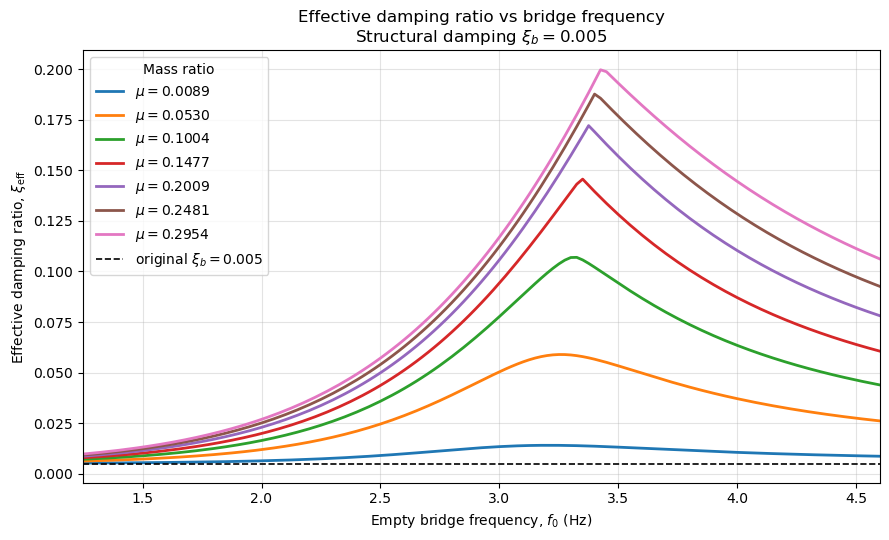

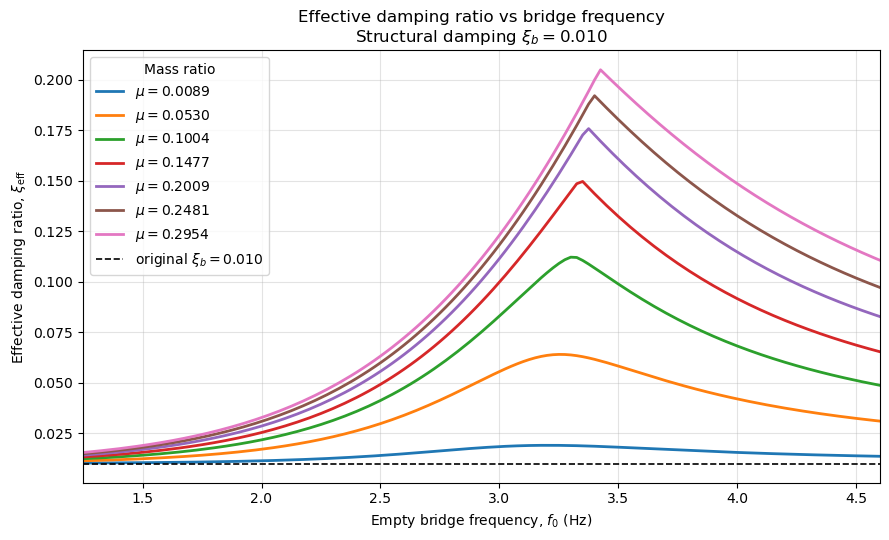

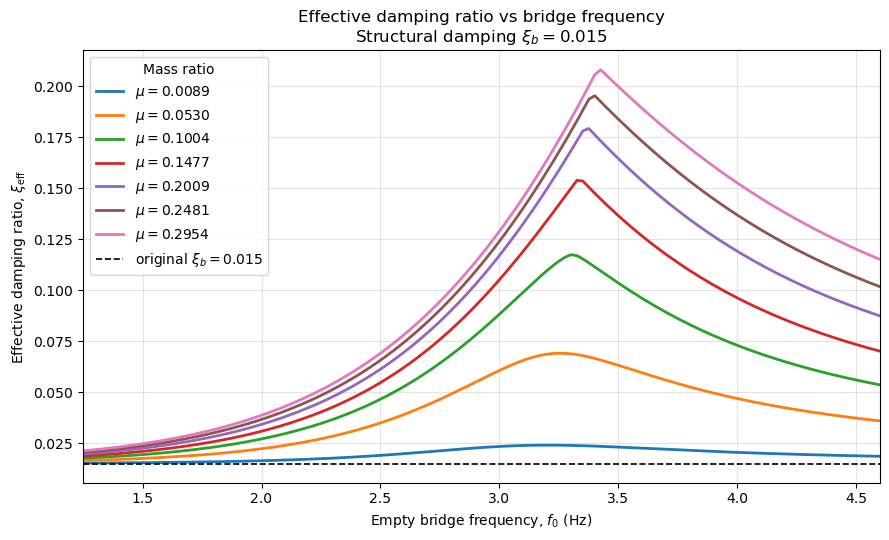

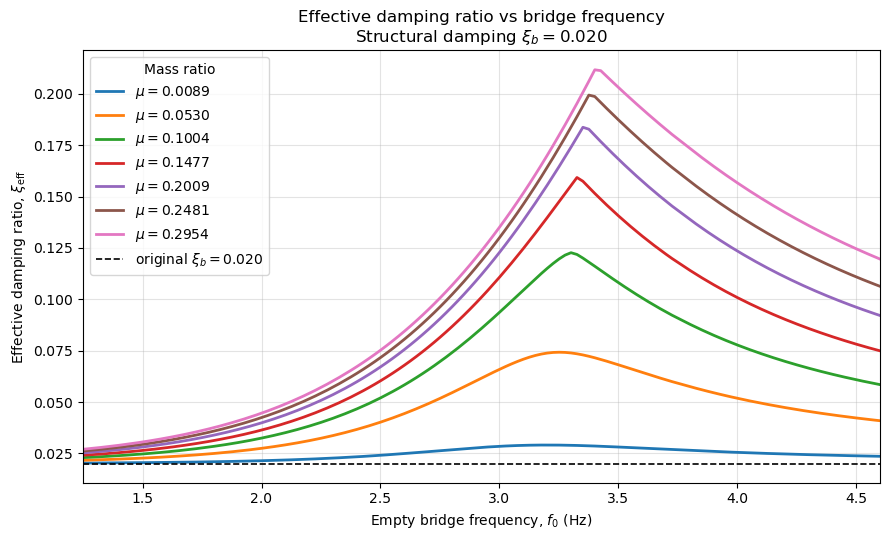

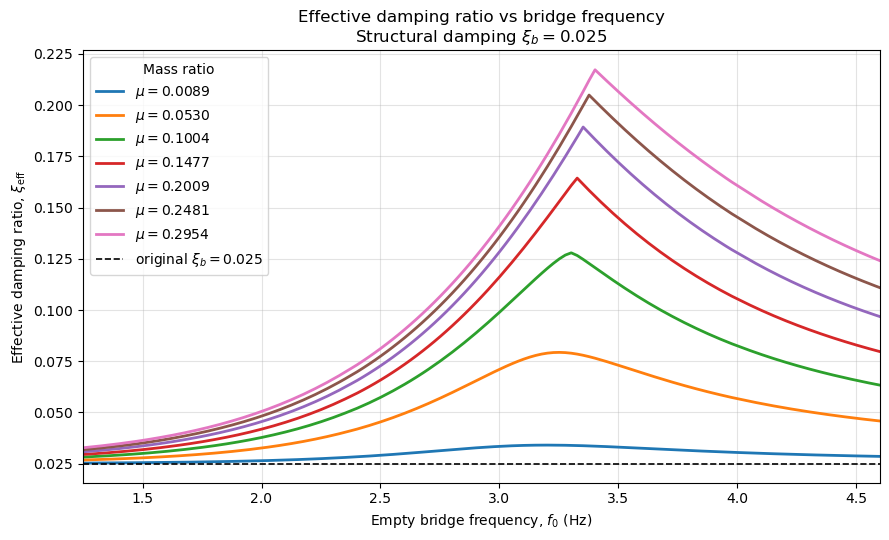

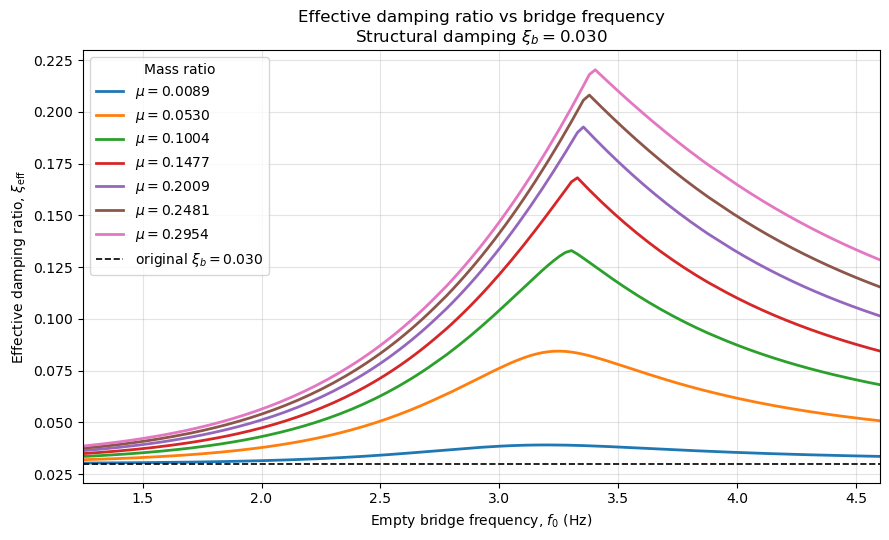

In [9]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# LOAD NMFR_2.pkl
# ============================================================

pkl_file = "NMFR_2.pkl"

with open(pkl_file, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
frequency_bands = saved["frequency_bands"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(results_all.keys())

print("Frequency bands:", bands_to_combine)
print("Damping ratios:", damping_values)
print("Densities:", densities)


# ============================================================
# MASS-RATIO LABELS
# ============================================================

mass_ratio_label = {}

first_band = bands_to_combine[0]
ref_damping = damping_values[0]
ref_bf = sorted(results_all[first_band][ref_damping].keys())[0]

for density in densities:
    arr = np.asarray(
        results_all[first_band][ref_damping][ref_bf][density]["modalpedmass_i"],
        dtype=float
    )
    mass_ratio_label[density] = np.nanmean(arr)

print("\nMass-ratio labels:")
for density, mu in mass_ratio_label.items():
    print(f"density = {density:.4f}, mass ratio = {mu:.4f}")


# ============================================================
# COLLECT f0 AND xi_eff
#
# Stored FRF ratio is inverse of equation ratio:
#     xi_eff = xi_b / frf_ratio
# ============================================================

def collect_f0_xieff(results_all, bands_to_combine, beamdamp, density):

    freq_to_f0 = {}
    freq_to_xieff = {}

    for band_name in bands_to_combine:

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            data = freq_dict[bf][density]

            f0_arr = np.asarray(data["f0_peak"], dtype=float).reshape(-1)
            frf_ratio = np.asarray(data["frf_ratio"], dtype=float).reshape(-1)

            n = min(len(f0_arr), len(frf_ratio))
            f0_arr = f0_arr[:n]
            frf_ratio = frf_ratio[:n]

            valid = (
                np.isfinite(f0_arr)
                & np.isfinite(frf_ratio)
                & (frf_ratio > 0)
            )

            if not np.any(valid):
                continue

            f0_arr = f0_arr[valid]
            frf_ratio = frf_ratio[valid]

            xi_eff = beamdamp / frf_ratio

            if bf not in freq_to_f0:
                freq_to_f0[bf] = []
                freq_to_xieff[bf] = []

            freq_to_f0[bf].append(np.nanmean(f0_arr))
            freq_to_xieff[bf].append(np.nanmean(xi_eff))

    bfs = sorted(freq_to_f0.keys())

    f0_vals = np.array([np.nanmean(freq_to_f0[bf]) for bf in bfs])
    xi_eff_vals = np.array([np.nanmean(freq_to_xieff[bf]) for bf in bfs])

    return f0_vals, xi_eff_vals


# ============================================================
# PLOT
#
# ONE GRAPH PER DAMPING RATIO
# ALL MASS RATIOS ON THE SAME GRAPH
# ============================================================

for beamdamp in damping_values:

    plt.figure(figsize=(9, 5.5))

    for density in densities:

        mu = mass_ratio_label[density]

        f0_vals, xi_eff_vals = collect_f0_xieff(
            results_all=results_all,
            bands_to_combine=bands_to_combine,
            beamdamp=beamdamp,
            density=density
        )

        plt.plot(
            f0_vals,
            xi_eff_vals,
            linewidth=2,
            label=fr"$\mu={mu:.4f}$"
        )

    # original structural damping as horizontal reference
    plt.axhline(
        beamdamp,
        linestyle="--",
        linewidth=1.2,
        color="black",
        label=fr"original $\xi_b={beamdamp:.3f}$"
    )

    plt.xlabel(r"Empty bridge frequency, $f_0$ (Hz)")
    plt.ylabel(r"Effective damping ratio, $\xi_{\mathrm{eff}}$")
    plt.title(
        r"Effective damping ratio vs bridge frequency"
        "\n"
        fr"Structural damping $\xi_b={beamdamp:.3f}$"
    )
    plt.xlim(1.25, 4.60)
    plt.grid(True, alpha=0.35)
    plt.legend(title="Mass ratio")
    plt.tight_layout()
    plt.show()

Bands: ['1.25_to_4.60']
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]


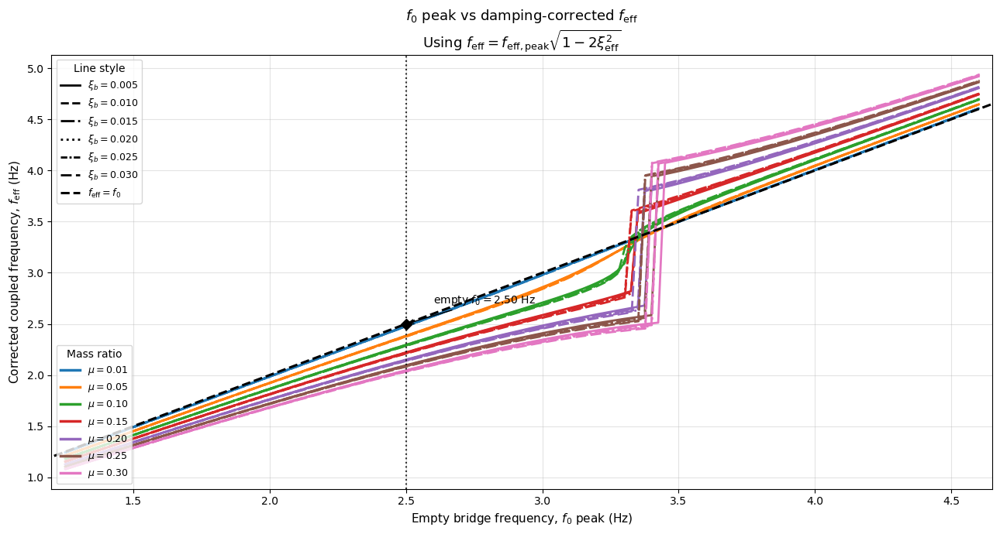

In [10]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# LOAD NMFR_2.pkl
# ============================================================

pkl_file = "NMFR_2.pkl"

with open(pkl_file, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(results_all.keys())

print("Bands:", bands_to_combine)
print("Densities:", densities)
print("Damping values:", damping_values)


# ============================================================
# MASS-RATIO LABELS
# ============================================================

mass_ratio_label = {}

first_band = bands_to_combine[0]
ref_damping = damping_values[0]
ref_bf = sorted(results_all[first_band][ref_damping].keys())[0]

for density in densities:
    arr = np.asarray(
        results_all[first_band][ref_damping][ref_bf][density]["modalpedmass_i"],
        dtype=float
    ).reshape(-1)

    mass_ratio_label[density] = np.nanmean(arr)


# ============================================================
# LINE STYLES = STRUCTURAL DAMPING
# ============================================================

line_styles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (3, 1, 1, 1)),
    (0, (5, 2)),
]

# ============================================================
# COLORS = MASS RATIO
# ============================================================

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

density_to_color = {
    density: default_colors[i % len(default_colors)]
    for i, density in enumerate(densities)
}


# ============================================================
# COLLECT f0 AND DAMPING-CORRECTED f_eff
# ============================================================

def collect_corrected_feff(results_all, bands_to_combine, beamdamp, density):
    """
    Use:
        xi_eff = xi_b / frf_ratio

    where saved frf_ratio is inverse of equation ratio.

    Then:
        f_eff_corrected = f_eff_peak * sqrt(1 - 2*xi_eff^2)

    Here:
        f_eff_peak is interpreted as omega_hs / (2*pi)
        from your latest equation.
    """

    freq_to_f0 = {}
    freq_to_feff_corr = {}
    freq_to_xieff = {}

    for band_name in bands_to_combine:

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            data = freq_dict[bf][density]

            f0_arr = np.asarray(
                data["f0_peak"],
                dtype=float
            ).reshape(-1)

            frf_ratio = np.asarray(
                data["frf_ratio"],
                dtype=float
            ).reshape(-1)

            f_eff_peak_arr = np.asarray(
                data["f_eff_peak"],
                dtype=float
            ).reshape(-1)

            n = min(len(f0_arr), len(frf_ratio), len(f_eff_peak_arr))

            f0_arr = f0_arr[:n]
            frf_ratio = frf_ratio[:n]
            f_eff_peak_arr = f_eff_peak_arr[:n]

            valid = (
                np.isfinite(f0_arr)
                & np.isfinite(frf_ratio)
                & np.isfinite(f_eff_peak_arr)
                & (frf_ratio > 0)
            )

            if not np.any(valid):
                continue

            f0_arr = f0_arr[valid]
            frf_ratio = frf_ratio[valid]
            f_eff_peak_arr = f_eff_peak_arr[valid]

            # ------------------------------------------------
            # Effective damping
            # ------------------------------------------------
            xi_eff = beamdamp / frf_ratio

            # ------------------------------------------------
            # Damping correction to peak frequency
            # ------------------------------------------------
            corr_term = 1.0 - 2.0 * xi_eff**2
            valid2 = corr_term > 0

            if not np.any(valid2):
                continue

            f0_arr = f0_arr[valid2]
            xi_eff = xi_eff[valid2]
            f_eff_peak_arr = f_eff_peak_arr[valid2]
            corr_term = corr_term[valid2]

            f_eff_corr = f_eff_peak_arr * np.sqrt(corr_term)

            if bf not in freq_to_f0:
                freq_to_f0[bf] = []
                freq_to_feff_corr[bf] = []
                freq_to_xieff[bf] = []

            freq_to_f0[bf].append(np.nanmean(f0_arr))
            freq_to_feff_corr[bf].append(np.nanmean(f_eff_corr))
            freq_to_xieff[bf].append(np.nanmean(xi_eff))

    bfs = sorted(freq_to_f0.keys())

    f0_vals = np.array([np.nanmean(freq_to_f0[bf]) for bf in bfs])
    f_eff_corr_vals = np.array([np.nanmean(freq_to_feff_corr[bf]) for bf in bfs])
    xi_eff_vals = np.array([np.nanmean(freq_to_xieff[bf]) for bf in bfs])

    return f0_vals, f_eff_corr_vals, xi_eff_vals


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(13, 7))

all_x = []
all_y = []

for density in densities:

    color = density_to_color[density]

    for i, beamdamp in enumerate(damping_values):

        ls = line_styles[i % len(line_styles)]

        f0_vals, f_eff_corr_vals, xi_eff_vals = collect_corrected_feff(
            results_all=results_all,
            bands_to_combine=bands_to_combine,
            beamdamp=beamdamp,
            density=density
        )

        if len(f0_vals) == 0:
            continue

        all_x.extend(f0_vals)
        all_y.extend(f_eff_corr_vals)

        ax.plot(
            f0_vals,
            f_eff_corr_vals,
            color=color,
            linestyle=ls,
            linewidth=2.0
        )


# ============================================================
# REFERENCE LINE: f_eff = f0
# ============================================================

all_x = np.asarray(all_x, dtype=float)
all_y = np.asarray(all_y, dtype=float)

lo = min(np.nanmin(all_x), np.nanmin(all_y))
hi = max(np.nanmax(all_x), np.nanmax(all_y))

ax.plot(
    [lo, hi],
    [lo, hi],
    color="black",
    linestyle="--",
    linewidth=2.2,
    label="_nolegend_"
)


# ============================================================
# OPTIONAL TARGET LINE
# ============================================================

TARGET_F0 = 2.50

ax.axvline(
    TARGET_F0,
    color="black",
    linestyle=":",
    linewidth=1.5,
    alpha=0.80
)

ax.plot(
    TARGET_F0,
    TARGET_F0,
    marker="D",
    markersize=7,
    color="black",
    zorder=20
)

ax.annotate(
    fr"empty $f_0={TARGET_F0:.2f}$ Hz",
    xy=(TARGET_F0, TARGET_F0),
    xytext=(TARGET_F0 + 0.10, TARGET_F0 + 0.20),
    fontsize=10,
    arrowprops=dict(arrowstyle="->", color="black", lw=1.0)
)


# ============================================================
# MASS-RATIO LEGEND
# ============================================================

mass_handles = []

for density in densities:
    mu = mass_ratio_label[density]

    mass_handles.append(
        Line2D(
            [0], [0],
            color=density_to_color[density],
            linestyle="-",
            linewidth=2.5,
            label=fr"$\mu={mu:.2f}$"
        )
    )

legend1 = ax.legend(
    handles=mass_handles,
    title="Mass ratio",
    loc="lower left",
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

ax.add_artist(legend1)


# ============================================================
# DAMPING LEGEND
# ============================================================

damping_handles = []

for i, beamdamp in enumerate(damping_values):
    damping_handles.append(
        Line2D(
            [0], [0],
            color="black",
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2.0,
            label=fr"$\xi_b={beamdamp:.3f}$"
        )
    )

damping_handles.append(
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=2.2,
        label=r"$f_{\mathrm{eff}}=f_0$"
    )
)

ax.legend(
    handles=damping_handles,
    title="Line style",
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
    frameon=True
)


# ============================================================
# AXIS FORMATTING
# ============================================================

ax.set_xlabel(r"Empty bridge frequency, $f_0$ peak (Hz)", fontsize=11)
ax.set_ylabel(r"Corrected coupled frequency, $f_{\mathrm{eff}}$ (Hz)", fontsize=11)

ax.set_title(
    r"$f_0$ peak vs damping-corrected $f_{\mathrm{eff}}$"
    "\n"
    r"Using $f_{\mathrm{eff}} = f_{\mathrm{eff,peak}}\sqrt{1-2\xi_{\mathrm{eff}}^2}$",
    fontsize=13
)

ax.set_xlim(1.20, 4.65)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

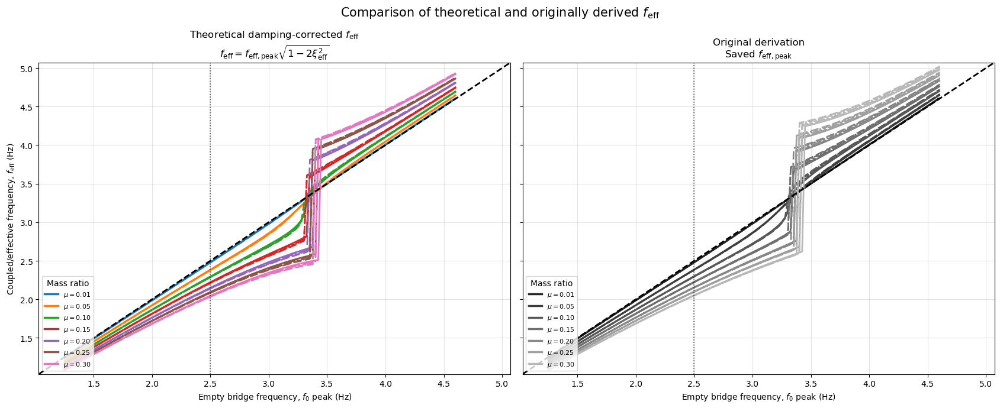

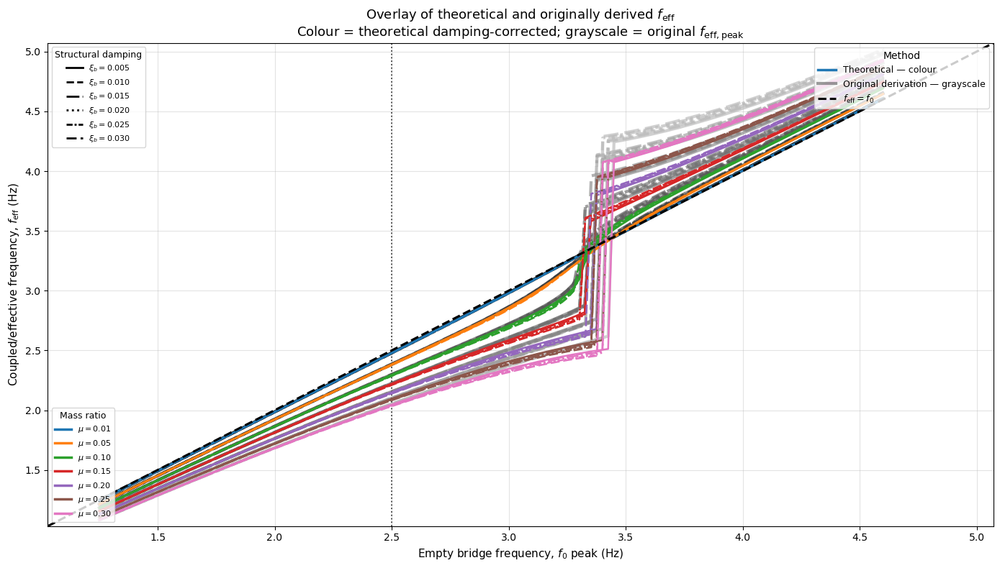

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# ASSUMES THESE ALREADY EXIST:
#
# results_all
# densities
# damping_values
# bands_to_combine
# mass_ratio_label
# ============================================================


# ============================================================
# LINE STYLES = STRUCTURAL DAMPING
# ============================================================

line_styles = [
    "-",
    "--",
    "-.",
    ":",
    (0, (3, 1, 1, 1)),
    (0, (5, 2)),
]


# ============================================================
# COLOURS = MASS RATIO FOR THEORETICAL CURVES
# ============================================================

default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

density_to_color = {
    density: default_colors[i % len(default_colors)]
    for i, density in enumerate(densities)
}


# ============================================================
# GRAYSCALE = MASS RATIO FOR ORIGINAL DERIVATION
#
# Avoid pure white so every curve remains visible.
# ============================================================

gray_values = np.linspace(0.15, 0.72, len(densities))

density_to_gray = {
    density: str(gray_values[i])
    for i, density in enumerate(densities)
}


# ============================================================
# 1. ORIGINAL DERIVATION
#
# Directly use saved:
#
#     f0_peak
#     f_eff_peak
# ============================================================

def collect_original_feff(
    results_all,
    bands_to_combine,
    beamdamp,
    density
):
    freq_to_f0 = {}
    freq_to_feff = {}

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        if beamdamp not in results_all[band_name]:
            continue

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            if density not in freq_dict[bf]:
                continue

            data = freq_dict[bf][density]

            f0_arr = np.asarray(
                data["f0_peak"],
                dtype=float
            ).reshape(-1)

            feff_arr = np.asarray(
                data["f_eff_peak"],
                dtype=float
            ).reshape(-1)

            n = min(
                len(f0_arr),
                len(feff_arr)
            )

            f0_arr = f0_arr[:n]
            feff_arr = feff_arr[:n]

            valid = (
                np.isfinite(f0_arr)
                & np.isfinite(feff_arr)
            )

            if not np.any(valid):
                continue

            if bf not in freq_to_f0:
                freq_to_f0[bf] = []
                freq_to_feff[bf] = []

            freq_to_f0[bf].append(
                np.nanmean(f0_arr[valid])
            )

            freq_to_feff[bf].append(
                np.nanmean(feff_arr[valid])
            )

    bfs = sorted(freq_to_f0.keys())

    f0_vals = np.array([
        np.nanmean(freq_to_f0[bf])
        for bf in bfs
    ])

    feff_vals = np.array([
        np.nanmean(freq_to_feff[bf])
        for bf in bfs
    ])

    return f0_vals, feff_vals


# ============================================================
# 2. THEORETICAL / DAMPING-CORRECTED CURVE
#
# Stored FRF ratio is inverse of equation ratio:
#
#     xi_eff = xi_b / FRF_ratio
#
# Then:
#
#     f_eff_theory
#       = f_eff_peak * sqrt(1 - 2*xi_eff^2)
# ============================================================

def collect_theoretical_feff(
    results_all,
    bands_to_combine,
    beamdamp,
    density
):
    freq_to_f0 = {}
    freq_to_feff = {}
    freq_to_xieff = {}

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        if beamdamp not in results_all[band_name]:
            continue

        freq_dict = results_all[band_name][beamdamp]

        for bf in sorted(freq_dict.keys()):

            if density not in freq_dict[bf]:
                continue

            data = freq_dict[bf][density]

            f0_arr = np.asarray(
                data["f0_peak"],
                dtype=float
            ).reshape(-1)

            feff_peak_arr = np.asarray(
                data["f_eff_peak"],
                dtype=float
            ).reshape(-1)

            frf_ratio_arr = np.asarray(
                data["frf_ratio"],
                dtype=float
            ).reshape(-1)

            n = min(
                len(f0_arr),
                len(feff_peak_arr),
                len(frf_ratio_arr)
            )

            f0_arr = f0_arr[:n]
            feff_peak_arr = feff_peak_arr[:n]
            frf_ratio_arr = frf_ratio_arr[:n]

            valid = (
                np.isfinite(f0_arr)
                & np.isfinite(feff_peak_arr)
                & np.isfinite(frf_ratio_arr)
                & (frf_ratio_arr > 0)
            )

            if not np.any(valid):
                continue

            f0_arr = f0_arr[valid]
            feff_peak_arr = feff_peak_arr[valid]
            frf_ratio_arr = frf_ratio_arr[valid]

            # ------------------------------------------------
            # Effective damping
            # ------------------------------------------------

            xi_eff = beamdamp / frf_ratio_arr

            # ------------------------------------------------
            # Damping correction
            # ------------------------------------------------

            correction = 1.0 - 2.0 * xi_eff**2

            valid2 = correction > 0

            if not np.any(valid2):
                continue

            f0_arr = f0_arr[valid2]
            feff_peak_arr = feff_peak_arr[valid2]
            xi_eff = xi_eff[valid2]
            correction = correction[valid2]

            f_eff_theory = (
                feff_peak_arr
                * np.sqrt(correction)
            )

            if bf not in freq_to_f0:
                freq_to_f0[bf] = []
                freq_to_feff[bf] = []
                freq_to_xieff[bf] = []

            freq_to_f0[bf].append(
                np.nanmean(f0_arr)
            )

            freq_to_feff[bf].append(
                np.nanmean(f_eff_theory)
            )

            freq_to_xieff[bf].append(
                np.nanmean(xi_eff)
            )

    bfs = sorted(freq_to_f0.keys())

    f0_vals = np.array([
        np.nanmean(freq_to_f0[bf])
        for bf in bfs
    ])

    feff_vals = np.array([
        np.nanmean(freq_to_feff[bf])
        for bf in bfs
    ])

    xi_eff_vals = np.array([
        np.nanmean(freq_to_xieff[bf])
        for bf in bfs
    ])

    return f0_vals, feff_vals, xi_eff_vals


# ============================================================
# FIRST COLLECT GLOBAL LIMITS
#
# Ensures side-by-side plots use exactly same axes.
# ============================================================

all_values = []

for density in densities:

    for beamdamp in damping_values:

        # Original
        x_old, y_old = collect_original_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        # Theoretical
        x_th, y_th, _ = collect_theoretical_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        all_values.extend(x_old)
        all_values.extend(y_old)
        all_values.extend(x_th)
        all_values.extend(y_th)

all_values = np.asarray(all_values, dtype=float)
all_values = all_values[np.isfinite(all_values)]

lo = np.nanmin(all_values)
hi = np.nanmax(all_values)

pad = 0.05

plot_lo = lo - pad
plot_hi = hi + pad


# ============================================================
# ============================================================
# FIGURE 1
#
# SIDE-BY-SIDE COMPARISON
#
# LEFT  = THEORETICAL, COLOUR
# RIGHT = ORIGINAL DERIVATION, GRAYSCALE
# ============================================================
# ============================================================

fig, (ax_theory, ax_derived) = plt.subplots(
    1,
    2,
    figsize=(17, 7),
    sharex=True,
    sharey=True
)


# ------------------------------------------------------------
# LEFT: THEORETICAL
# ------------------------------------------------------------

for density in densities:

    color = density_to_color[density]

    for i, beamdamp in enumerate(damping_values):

        ls = line_styles[i % len(line_styles)]

        f0_vals, feff_vals, _ = collect_theoretical_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        ax_theory.plot(
            f0_vals,
            feff_vals,
            color=color,
            linestyle=ls,
            linewidth=2.0
        )


# ------------------------------------------------------------
# RIGHT: ORIGINAL DERIVATION
# ------------------------------------------------------------

for density in densities:

    gray = density_to_gray[density]

    for i, beamdamp in enumerate(damping_values):

        ls = line_styles[i % len(line_styles)]

        f0_vals, feff_vals = collect_original_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        ax_derived.plot(
            f0_vals,
            feff_vals,
            color=gray,
            linestyle=ls,
            linewidth=2.0
        )


# ------------------------------------------------------------
# NO-SHIFT REFERENCE ON BOTH
# ------------------------------------------------------------

for ax in [ax_theory, ax_derived]:

    ax.plot(
        [plot_lo, plot_hi],
        [plot_lo, plot_hi],
        color="black",
        linestyle="--",
        linewidth=2.0
    )

    ax.axvline(
        2.50,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.7
    )

    ax.set_xlim(plot_lo, plot_hi)
    ax.set_ylim(plot_lo, plot_hi)

    ax.grid(
        True,
        alpha=0.35
    )

    ax.set_xlabel(
        r"Empty bridge frequency, $f_0$ peak (Hz)"
    )


ax_theory.set_ylabel(
    r"Coupled/effective frequency, $f_{\mathrm{eff}}$ (Hz)"
)

ax_theory.set_title(
    "Theoretical damping-corrected "
    r"$f_{\mathrm{eff}}$"
    "\n"
    r"$f_{\mathrm{eff}}="
    r"f_{\mathrm{eff,peak}}"
    r"\sqrt{1-2\xi_{\mathrm{eff}}^2}$"
)

ax_derived.set_title(
    "Original derivation"
    "\n"
    r"Saved $f_{\mathrm{eff,peak}}$"
)


# ============================================================
# MASS-RATIO LEGENDS
# ============================================================

theory_mass_handles = []

for density in densities:

    mu = mass_ratio_label.get(
        round(float(density), 4),
        mass_ratio_label.get(density, density)
    )

    theory_mass_handles.append(
        Line2D(
            [0], [0],
            color=density_to_color[density],
            linewidth=2.5,
            label=fr"$\mu={mu:.2f}$"
        )
    )

ax_theory.legend(
    handles=theory_mass_handles,
    title="Mass ratio",
    loc="lower left",
    fontsize=8
)


derived_mass_handles = []

for density in densities:

    mu = mass_ratio_label.get(
        round(float(density), 4),
        mass_ratio_label.get(density, density)
    )

    derived_mass_handles.append(
        Line2D(
            [0], [0],
            color=density_to_gray[density],
            linewidth=2.5,
            label=fr"$\mu={mu:.2f}$"
        )
    )

ax_derived.legend(
    handles=derived_mass_handles,
    title="Mass ratio",
    loc="lower left",
    fontsize=8
)


fig.suptitle(
    r"Comparison of theoretical and originally derived "
    r"$f_{\mathrm{eff}}$",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ============================================================
# ============================================================
# FIGURE 2
#
# OVERLAY:
#
# THEORETICAL = COLOUR
# ORIGINAL DERIVATION = GRAYSCALE
# ============================================================
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 8)
)


# ------------------------------------------------------------
# ORIGINAL DERIVATION FIRST
# Grayscale behind coloured theoretical curves
# ------------------------------------------------------------

for density in densities:

    gray = density_to_gray[density]

    for i, beamdamp in enumerate(damping_values):

        ls = line_styles[i % len(line_styles)]

        f0_old, feff_old = collect_original_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        ax.plot(
            f0_old,
            feff_old,
            color=gray,
            linestyle=ls,
            linewidth=3.0,
            alpha=0.65,
            zorder=2
        )


# ------------------------------------------------------------
# THEORETICAL CURVES ON TOP IN COLOUR
# ------------------------------------------------------------

for density in densities:

    color = density_to_color[density]

    for i, beamdamp in enumerate(damping_values):

        ls = line_styles[i % len(line_styles)]

        f0_th, feff_th, _ = collect_theoretical_feff(
            results_all,
            bands_to_combine,
            beamdamp,
            density
        )

        ax.plot(
            f0_th,
            feff_th,
            color=color,
            linestyle=ls,
            linewidth=1.8,
            alpha=1.0,
            zorder=3
        )


# ------------------------------------------------------------
# NO-SHIFT REFERENCE
# ------------------------------------------------------------

ax.plot(
    [plot_lo, plot_hi],
    [plot_lo, plot_hi],
    color="black",
    linestyle="--",
    linewidth=2.2,
    zorder=4
)

ax.axvline(
    2.50,
    color="black",
    linestyle=":",
    linewidth=1.3,
    alpha=0.75
)


# ============================================================
# LEGEND 1: MASS RATIOS
# Use theoretical colours
# ============================================================

mass_handles = []

for density in densities:

    mu = mass_ratio_label.get(
        round(float(density), 4),
        mass_ratio_label.get(density, density)
    )

    mass_handles.append(
        Line2D(
            [0], [0],
            color=density_to_color[density],
            linewidth=2.5,
            label=fr"$\mu={mu:.2f}$"
        )
    )

legend_mass = ax.legend(
    handles=mass_handles,
    title="Mass ratio",
    loc="lower left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

ax.add_artist(legend_mass)


# ============================================================
# LEGEND 2: DAMPING LINE STYLES
# ============================================================

damping_handles = []

for i, beamdamp in enumerate(damping_values):

    damping_handles.append(
        Line2D(
            [0], [0],
            color="black",
            linestyle=line_styles[i % len(line_styles)],
            linewidth=2,
            label=fr"$\xi_b={beamdamp:.3f}$"
        )
    )

legend_damping = ax.legend(
    handles=damping_handles,
    title="Structural damping",
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

ax.add_artist(legend_damping)


# ============================================================
# LEGEND 3: METHOD
# ============================================================

method_handles = [
    Line2D(
        [0], [0],
        color=default_colors[0],
        linestyle="-",
        linewidth=2.5,
        label="Theoretical — colour"
    ),
    Line2D(
        [0], [0],
        color="0.40",
        linestyle="-",
        linewidth=3.0,
        alpha=0.65,
        label="Original derivation — grayscale"
    ),
    Line2D(
        [0], [0],
        color="black",
        linestyle="--",
        linewidth=2.2,
        label=r"$f_{\mathrm{eff}}=f_0$"
    )
]

ax.legend(
    handles=method_handles,
    title="Method",
    loc="upper right",
    fontsize=9,
    title_fontsize=10,
    frameon=True
)


# ============================================================
# AXES
# ============================================================

ax.set_xlim(
    plot_lo,
    plot_hi
)

ax.set_ylim(
    plot_lo,
    plot_hi
)

ax.set_xlabel(
    r"Empty bridge frequency, $f_0$ peak (Hz)",
    fontsize=11
)

ax.set_ylabel(
    r"Coupled/effective frequency, $f_{\mathrm{eff}}$ (Hz)",
    fontsize=11
)

ax.set_title(
    r"Overlay of theoretical and originally derived "
    r"$f_{\mathrm{eff}}$"
    "\n"
    r"Colour = theoretical damping-corrected; "
    r"grayscale = original $f_{\mathrm{eff,peak}}$",
    fontsize=13
)

ax.grid(
    True,
    alpha=0.35
)

plt.tight_layout()
plt.show()

Loaded: NMFR_2.pkl
Bands: ['1.25_to_4.60']
Densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

Number of curves in envelope: 8

Fitted psi-envelope breakpoints
a = 1.700000
b = 2.567634
c = 2.793735
d = 4.200000


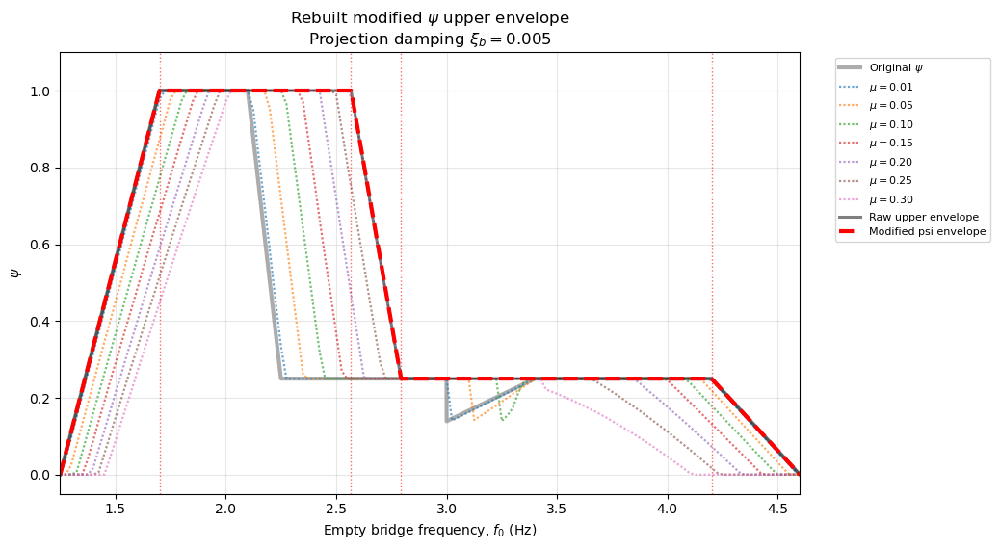



CALIBRATION OF n' AFTER REBUILDING THE MODIFIED PSI ENVELOPE
Density       = 0.5000
Mass ratio    = 0.25
Area          = 100.0 m²
N pedestrians = 50.00
Measure       = Peak absolute acceleration

  target_beamdamp  bridge_frequency  psi_original  psi_modified  code_bias_mean  bias_after_psi_mean  nprime_original  nprime_required_mean  nprime_multiplier  final_bias_check
           0.005              1.50      0.555556      0.555556        0.120703             0.120703            0.054              0.006518           0.120703               1.0
           0.005              1.60      0.777778      0.777778        0.111202             0.111202            0.054              0.006005           0.111202               1.0
           0.005              1.70      1.000000      1.000000        0.113730             0.113730            0.054              0.006141           0.113730               1.0
           0.005              1.75      1.000000      1.000000        0.137031             0.1370

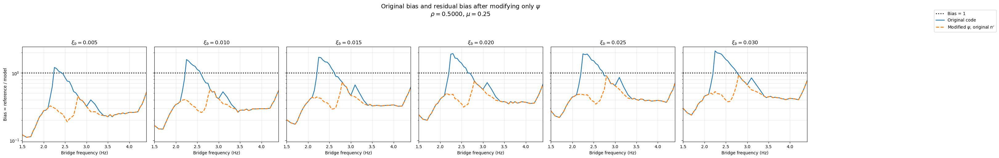

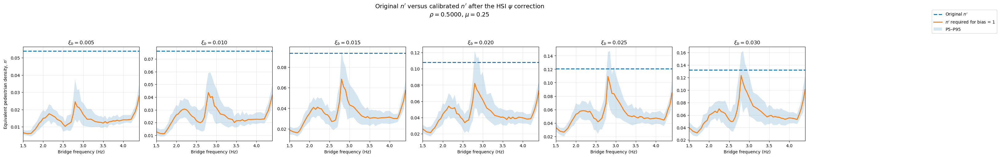

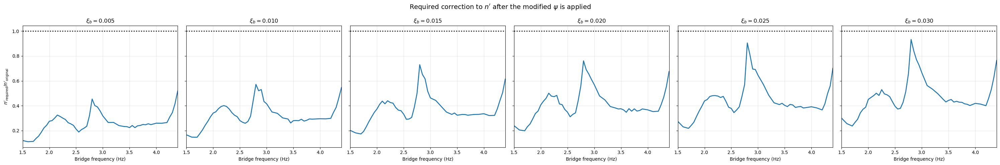

'\n# ============================================================\n# SAVE CALIBRATION TABLE\n# ============================================================\n\noutput_columns = [\n    "bridge_frequency",\n    "target_beamdamp",\n    "target_density",\n\n    "N_pedestrians",\n\n    "psi_original",\n    "psi_modified",\n\n    "code_bias_mean",\n    "bias_after_psi_mean",\n\n    "nprime_original",\n    "nprime_required_mean",\n\n    "nprime_multiplier",\n    "final_bias_check",\n]\n\n\noutput_df = (\n    work_df[\n        output_columns\n    ]\n    .sort_values(\n        [\n            "target_beamdamp",\n            "bridge_frequency",\n        ]\n    )\n    .reset_index(\n        drop=True\n    )\n)\n\n\noutput_file = (\n    "nprime_calibration_"\n    f"density{TARGET_DENSITY:.4f}_"\n    f"mu{TARGET_MASS_RATIO:.2f}.csv"\n)\n\n\noutput_df.to_csv(\n    output_file,\n    index=False\n)\n\n\nprint(\n    "\nSaved:",\n    output_file\n)\n\n\nprint(\n    "\nMaximum numerical deviation "\n    "o

In [11]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution, minimize


# ============================================================
# PURPOSE
# ============================================================
#
# 1. Rebuild the modified psi upper envelope directly
#    from NMFR_2.pkl
#
# 2. Start from ORIGINAL CODE BIAS:
#
#       B0 = reference / original_code
#
# 3. Replace only:
#
#       psi_original -> psi_envelope
#
#    while keeping original n'
#
# 4. Calculate residual bias:
#
#       Bpsi = B0 * psi_original / psi_envelope
#
# 5. Because response is linear in n':
#
#       n'_required = n'_original * Bpsi
#
#    This is the n' that would give bias = 1.
# ============================================================


# ============================================================
# USER SETTINGS
# ============================================================

PKL_FILE = "NMFR_2.pkl"

TARGET_DAMPINGS = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

TARGET_DENSITY = 0.5000
TARGET_MASS_RATIO = 0.25

MEASURE = "Peak absolute acceleration"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

# Bridge geometry used in simulation
LENGTH = 50.0
WIDTH = 2.0
AREA = LENGTH * WIDTH

# EN/SETRA n' coefficient
NPRIME_COEFFICIENT = 10.8

EPS = 1e-12


# ============================================================
# PSI ENVELOPE SETTINGS
#
# Same construction as your previous upper-envelope code
# ============================================================

PROJECT_DAMPING = 0.005

F_START = 1.25
F_END = 4.60

PSI_TOP = 1.00
PSI_LOW = 0.25

N_GRID = 5000

INCLUDE_ORIGINAL_PSI_IN_ENVELOPE = True

PENALTY_BELOW = 1e6


# ============================================================
# LOAD NMFR_2.pkl
# ============================================================

with open(PKL_FILE, "rb") as f:
    saved = pickle.load(f)

results_all = saved["results_all"]
frequency_bands = saved["frequency_bands"]
densities = saved["densities"]
damping_values = saved["damping_values"]

bands_to_combine = list(frequency_bands.keys())

print("Loaded:", PKL_FILE)
print("Bands:", bands_to_combine)
print("Densities:", densities)
print("Damping values:", damping_values)


# ============================================================
# DENSITY -> MASS-RATIO LABEL
# ============================================================

mass_ratio_label = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
    1.0:    0.30,
}


# ============================================================
# ORIGINAL PSI
#
# Same version used in your envelope code:
# minimum psi = 0.25 from 2.25 to 3.00 Hz
# ============================================================

def psi_original(f):

    f = np.asarray(f, dtype=float)
    psi = np.zeros_like(f)

    # 1.25–1.70 Hz
    m = (f >= 1.25) & (f < 1.70)
    psi[m] = (
        (f[m] - 1.25)
        / (1.70 - 1.25)
    )

    # 1.70–2.10 Hz
    m = (f >= 1.70) & (f <= 2.10)
    psi[m] = 1.0

    # 2.10–2.30 Hz
    m = (f > 2.10) & (f <= 2.30)
    psi[m] = (
        (2.30 - f[m])
        / (2.30 - 2.10)
    )

    # 2.30–2.50 Hz
    m = (f > 2.30) & (f < 2.50)
    psi[m] = 0.0

    # 2.50–3.40 Hz
    m = (f >= 2.50) & (f < 3.40)
    psi[m] = (
        0.25
        * (f[m] - 2.50)
        / (3.40 - 2.50)
    )

    # 3.40–4.20 Hz
    m = (f >= 3.40) & (f <= 4.20)
    psi[m] = 0.25

    # 4.20–4.60 Hz
    m = (f > 4.20) & (f <= 4.60)
    psi[m] = (
        0.25
        * (4.60 - f[m])
        / (4.60 - 4.20)
    )

    # Enforced minimum
    m = (f >= 2.25) & (f <= 3.00)

    psi[m] = np.maximum(
        psi[m],
        0.25
    )

    return psi


# ============================================================
# ROBUST FLOAT KEY HELPER
# ============================================================

def nearest_float_key(mapping, target, tol=1e-6):

    keys = list(mapping.keys())

    if len(keys) == 0:
        return None

    values = np.asarray(
        [float(k) for k in keys],
        dtype=float
    )

    idx = np.argmin(
        np.abs(
            values - float(target)
        )
    )

    if abs(
        values[idx] - float(target)
    ) <= tol:

        return keys[idx]

    return None


# ============================================================
# COLLECT f0 AND f_eff FROM NMFR
# ============================================================

def collect_f0_feff_for_envelope(
    results_all,
    bands_to_combine,
    beamdamp_value,
    density_value,
    key_tol=1e-5
):

    x_vals = []
    y_vals = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        damp_key = nearest_float_key(
            results_all[band_name],
            beamdamp_value,
            tol=key_tol
        )

        if damp_key is None:
            continue

        freq_dict = (
            results_all[band_name][damp_key]
        )

        for bf in sorted(freq_dict.keys()):

            density_key = nearest_float_key(
                freq_dict[bf],
                density_value,
                tol=key_tol
            )

            if density_key is None:
                continue

            data = freq_dict[bf][density_key]

            if (
                "f0_peak" not in data
                or
                "f_eff_peak" not in data
            ):
                continue

            f0_arr = np.asarray(
                data["f0_peak"],
                dtype=float
            ).reshape(-1)

            feff_arr = np.asarray(
                data["f_eff_peak"],
                dtype=float
            ).reshape(-1)

            valid = (
                np.isfinite(f0_arr)
                & np.isfinite(feff_arr)
            )

            if np.any(valid):

                x_vals.append(
                    np.nanmean(
                        f0_arr[valid]
                    )
                )

                y_vals.append(
                    np.nanmean(
                        feff_arr[valid]
                    )
                )

    x_vals = np.asarray(
        x_vals,
        dtype=float
    )

    y_vals = np.asarray(
        y_vals,
        dtype=float
    )

    if len(x_vals) == 0:

        return x_vals, y_vals

    # Average repeated f0 values
    temp = (
        pd.DataFrame(
            {
                "f0": x_vals,
                "feff": y_vals,
            }
        )
        .dropna()
        .groupby(
            "f0",
            as_index=False
        )
        .agg(
            feff=("feff", "mean")
        )
        .sort_values("f0")
    )

    return (
        temp["f0"].to_numpy(),
        temp["feff"].to_numpy(),
    )


# ============================================================
# ============================================================
# PART A
#
# BUILD THE PSI UPPER ENVELOPE
# ============================================================
# ============================================================

f_grid = np.linspace(
    F_START,
    F_END,
    N_GRID
)

curve_list = []
curve_names = []

projected_curves_for_plot = []


# ------------------------------------------------------------
# Include original psi itself in the envelope
# ------------------------------------------------------------

if INCLUDE_ORIGINAL_PSI_IN_ENVELOPE:

    curve_list.append(
        psi_original(f_grid)
    )

    curve_names.append(
        "Original psi"
    )


# ------------------------------------------------------------
# Build projected psi for every mass ratio
#
# psi_mu(f0) = psi_original(f_eff)
# ------------------------------------------------------------

for density in densities:

    x_vals, feff_vals = (
        collect_f0_feff_for_envelope(
            results_all=results_all,
            bands_to_combine=bands_to_combine,
            beamdamp_value=PROJECT_DAMPING,
            density_value=density,
        )
    )

    if len(x_vals) < 2:

        print(
            f"Skipping density={density}: "
            "not enough projected data"
        )

        continue

    order = np.argsort(x_vals)

    x_vals = x_vals[order]
    feff_vals = feff_vals[order]

    # Raw projected psi
    psi_projected_raw = (
        psi_original(feff_vals)
    )

    projected_curves_for_plot.append(
        {
            "density": density,
            "mu": mass_ratio_label.get(
                round(float(density), 4),
                density
            ),
            "x_vals": x_vals,
            "feff_vals": feff_vals,
            "psi_projected_raw": (
                psi_projected_raw
            ),
        }
    )

    # Interpolate f_eff onto common f0 grid
    feff_interp = np.interp(
        f_grid,
        x_vals,
        feff_vals,
        left=np.nan,
        right=np.nan
    )

    psi_projected_interp = (
        psi_original(feff_interp)
    )

    psi_projected_interp[
        ~np.isfinite(feff_interp)
    ] = np.nan

    curve_list.append(
        psi_projected_interp
    )

    curve_names.append(
        f"Projected psi density={density}"
    )


if len(curve_list) == 0:

    raise ValueError(
        "No psi curves collected from NMFR_2.pkl."
    )


# ------------------------------------------------------------
# Raw upper envelope
# ------------------------------------------------------------

curve_array = np.vstack(
    curve_list
)

psi_env_raw = np.nanmax(
    curve_array,
    axis=0
)

valid_env = np.isfinite(
    psi_env_raw
)

f_env_data = f_grid[
    valid_env
]

psi_env_data = psi_env_raw[
    valid_env
]


print(
    "\nNumber of curves in envelope:",
    len(curve_list)
)


# ============================================================
# FIT PIECEWISE-LINEAR UPPER ENVELOPE
#
# a = end ramp to 1
# b = end plateau 1
# c = end fall to 0.25
# d = end plateau 0.25
# ============================================================

def psi_piecewise_env(
    f,
    a,
    b,
    c,
    d
):

    f = np.asarray(
        f,
        dtype=float
    )

    psi = np.zeros_like(
        f
    )

    # Segment 1
    m = (
        (f >= F_START)
        & (f < a)
    )

    psi[m] = (
        PSI_TOP
        * (f[m] - F_START)
        / (a - F_START)
    )

    # Segment 2
    m = (
        (f >= a)
        & (f < b)
    )

    psi[m] = PSI_TOP

    # Segment 3
    m = (
        (f >= b)
        & (f < c)
    )

    psi[m] = (
        PSI_TOP
        +
        (PSI_LOW - PSI_TOP)
        * (f[m] - b)
        / (c - b)
    )

    # Segment 4
    m = (
        (f >= c)
        & (f < d)
    )

    psi[m] = PSI_LOW

    # Segment 5
    m = (
        (f >= d)
        & (f <= F_END)
    )

    psi[m] = (
        PSI_LOW
        * (F_END - f[m])
        / (F_END - d)
    )

    return psi


# ============================================================
# FIT OBJECTIVE
# ============================================================

def envelope_objective(params):

    a, b, c, d = params

    if not (
        F_START
        < a
        < b
        < c
        < d
        < F_END
    ):

        return 1e30

    psi_fit = psi_piecewise_env(
        f_env_data,
        a,
        b,
        c,
        d
    )

    residual = (
        psi_fit
        - psi_env_data
    )

    # Strong penalty if fitted curve
    # goes BELOW raw envelope
    below = np.minimum(
        residual,
        0.0
    )

    # Small penalty for excess conservatism
    above = np.maximum(
        residual,
        0.0
    )

    return (
        PENALTY_BELOW
        * np.mean(below**2)
        +
        np.mean(above**2)
    )


# ============================================================
# OPTIMISE BREAKPOINTS
# ============================================================

bounds = [
    (1.50, 1.90),  # a
    (2.20, 2.70),  # b
    (2.45, 2.95),  # c
    (3.80, 4.40),  # d
]

result_global = differential_evolution(
    envelope_objective,
    bounds=bounds,
    seed=42,
    tol=1e-10,
    polish=False
)

result_local = minimize(
    envelope_objective,
    result_global.x,
    method="Nelder-Mead",
    options={
        "maxiter": 30000,
        "xatol": 1e-12,
        "fatol": 1e-12,
    }
)

a, b, c, d = (
    result_local.x
)


print("\nFitted psi-envelope breakpoints")
print("=" * 60)

print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")
print(f"d = {d:.6f}")


# ============================================================
# FINAL PSI ENVELOPE FUNCTION
#
# CREATED INSIDE THIS CELL
# ============================================================

def psi_envelope(f):

    return psi_piecewise_env(
        f,
        a,
        b,
        c,
        d
    )


# ============================================================
# CHECK ENVELOPE PLOT
# ============================================================

psi_fit_grid = psi_envelope(
    f_grid
)

fig, ax = plt.subplots(
    figsize=(10.5, 5.8)
)

# Original psi
ax.plot(
    f_grid,
    psi_original(f_grid),
    color="gray",
    linewidth=3.0,
    alpha=0.65,
    label=r"Original $\psi$"
)

# Individual projected curves
for item in projected_curves_for_plot:

    ax.plot(
        item["x_vals"],
        item["psi_projected_raw"],
        linestyle=(0, (1, 1)),
        linewidth=1.6,
        alpha=0.65,
        label=(
            fr"$\mu={item['mu']:.2f}$"
        )
    )

# Raw envelope
ax.plot(
    f_env_data,
    psi_env_data,
    color="black",
    linewidth=2.2,
    alpha=0.5,
    label="Raw upper envelope"
)

# Fitted envelope
ax.plot(
    f_grid,
    psi_fit_grid,
    color="red",
    linestyle="--",
    linewidth=3.0,
    label="Modified psi envelope"
)

for bp in [a, b, c, d]:

    ax.axvline(
        bp,
        color="red",
        linestyle=":",
        linewidth=1.0,
        alpha=0.6
    )

ax.set_xlabel(
    r"Empty bridge frequency, $f_0$ (Hz)"
)

ax.set_ylabel(
    r"$\psi$"
)

ax.set_title(
    r"Rebuilt modified $\psi$ upper envelope"
    "\n"
    fr"Projection damping $\xi_b={PROJECT_DAMPING:.3f}$"
)

ax.set_xlim(
    F_START,
    F_END
)

ax.set_ylim(
    -0.05,
    1.10
)

ax.grid(
    True,
    alpha=0.30
)

ax.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()


# ============================================================
# ============================================================
# PART B
#
# GET ORIGINAL CODE BIAS FROM corrected_df
# ============================================================
# ============================================================

if "corrected_df" not in globals():

    raise NameError(
        "corrected_df is not in notebook memory.\n"
        "Run the cell that creates corrected_df first."
    )


df = corrected_df.copy()


required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "measure",
    "code_bias_mean",
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:

    raise KeyError(
        f"Missing columns in corrected_df: "
        f"{missing_cols}"
    )


# Numeric conversion
for col in [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "code_bias_mean",
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# Optional uncertainty columns
for col in [
    "code_bias_p5",
    "code_bias_p95",
]:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


df["measure"] = (
    df["measure"]
    .astype(str)
    .str.strip()
)


df = df.dropna(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        "code_bias_mean",
    ]
).copy()


# ============================================================
# FILTER DAMPINGS, DENSITY, MEASURE, FREQUENCY
# ============================================================

damping_mask = np.zeros(
    len(df),
    dtype=bool
)

for damp in TARGET_DAMPINGS:

    damping_mask |= np.isclose(
        df["target_beamdamp"],
        damp
    )


work_df = df[
    damping_mask
    &
    np.isclose(
        df["target_density"],
        TARGET_DENSITY
    )
    &
    (
        df["measure"]
        == MEASURE
    )
    &
    (
        df["bridge_frequency"]
        >= PLOT_FMIN
    )
    &
    (
        df["bridge_frequency"]
        <= PLOT_FMAX
    )
].copy()


if work_df.empty:

    raise ValueError(
        "No rows found after filtering.\n"
        "Check TARGET_DENSITY, TARGET_DAMPINGS, "
        "MEASURE and frequency range."
    )


# ============================================================
# PART C
#
# ORIGINAL PSI AND MODIFIED PSI
# AT EVERY BIAS DATA POINT
# ============================================================

frequencies = (
    work_df[
        "bridge_frequency"
    ]
    .to_numpy(dtype=float)
)


work_df["psi_original"] = (
    psi_original(
        frequencies
    )
)

work_df["psi_modified"] = (
    psi_envelope(
        frequencies
    )
)


# ============================================================
# SAFETY CHECK
#
# We should not divide by zero.
# In selected 1.5–4.4 range this should normally be okay.
# ============================================================

work_df[
    "psi_original_safe"
] = (
    work_df["psi_original"]
    .clip(lower=EPS)
)

work_df[
    "psi_modified_safe"
] = (
    work_df["psi_modified"]
    .clip(lower=EPS)
)


# ============================================================
# PART D
#
# BIAS AFTER CHANGING ONLY PSI
#
# Original:
#
#     B0 = HF / R0
#
# Since:
#
#     R0 ∝ n'_0 * psi_original
#
# and modified model:
#
#     Rpsi ∝ n'_0 * psi_modified
#
# therefore:
#
#     Rpsi / R0
#       = psi_modified / psi_original
#
# and:
#
#     Bpsi
#       = B0
#         * psi_original / psi_modified
# ============================================================

work_df[
    "psi_response_multiplier"
] = (
    work_df[
        "psi_modified_safe"
    ]
    /
    work_df[
        "psi_original_safe"
    ]
)


work_df[
    "bias_after_psi_mean"
] = (
    work_df[
        "code_bias_mean"
    ]
    *
    work_df[
        "psi_original_safe"
    ]
    /
    work_df[
        "psi_modified_safe"
    ]
)


# Optional percentile biases
if "code_bias_p5" in work_df.columns:

    work_df[
        "bias_after_psi_p5"
    ] = (
        work_df[
            "code_bias_p5"
        ]
        *
        work_df[
            "psi_original_safe"
        ]
        /
        work_df[
            "psi_modified_safe"
        ]
    )


if "code_bias_p95" in work_df.columns:

    work_df[
        "bias_after_psi_p95"
    ] = (
        work_df[
            "code_bias_p95"
        ]
        *
        work_df[
            "psi_original_safe"
        ]
        /
        work_df[
            "psi_modified_safe"
        ]
    )


# ============================================================
# PART E
#
# ORIGINAL n'
#
# n' = 10.8 sqrt(N * xi_b) / S
#
# N = density * S
# ============================================================

work_df[
    "N_pedestrians"
] = (
    work_df[
        "target_density"
    ]
    * AREA
)


work_df[
    "nprime_original"
] = (
    NPRIME_COEFFICIENT
    *
    np.sqrt(
        work_df[
            "N_pedestrians"
        ]
        *
        work_df[
            "target_beamdamp"
        ]
    )
    /
    AREA
)


# ============================================================
# PART F
#
# n' REQUIRED FOR BIAS = 1
#
# With modified psi:
#
#     Bpsi = HF / Rpsi
#
# Response is linear in n':
#
#     Rnew
#       = Rpsi
#         * n'_new/n'_old
#
# For Bnew = 1:
#
#     n'_new
#       = n'_old * Bpsi
# ============================================================

work_df[
    "nprime_required_mean"
] = (
    work_df[
        "nprime_original"
    ]
    *
    work_df[
        "bias_after_psi_mean"
    ]
)


# Optional P5/P95 range
if (
    "bias_after_psi_p5"
    in work_df.columns
):

    work_df[
        "nprime_required_p5"
    ] = (
        work_df[
            "nprime_original"
        ]
        *
        work_df[
            "bias_after_psi_p5"
        ]
    )


if (
    "bias_after_psi_p95"
    in work_df.columns
):

    work_df[
        "nprime_required_p95"
    ] = (
        work_df[
            "nprime_original"
        ]
        *
        work_df[
            "bias_after_psi_p95"
        ]
    )


# ============================================================
# CALIBRATION MULTIPLIER
#
# This is also exactly the remaining bias:
#
# n'_required / n'_original
#     = Bpsi
# ============================================================

work_df[
    "nprime_multiplier"
] = (
    work_df[
        "nprime_required_mean"
    ]
    /
    work_df[
        "nprime_original"
    ]
)


# ============================================================
# CHECK FINAL BIAS
#
# Should be 1.0
# ============================================================

work_df[
    "final_bias_check"
] = (
    work_df[
        "bias_after_psi_mean"
    ]
    /
    work_df[
        "nprime_multiplier"
    ]
)


# ============================================================
# PRINT TABLE
# ============================================================

print("\n")
print("=" * 110)
print(
    "CALIBRATION OF n' AFTER REBUILDING "
    "THE MODIFIED PSI ENVELOPE"
)
print("=" * 110)

print(
    f"Density       = {TARGET_DENSITY:.4f}"
)

print(
    f"Mass ratio    = {TARGET_MASS_RATIO:.2f}"
)

print(
    f"Area          = {AREA:.1f} m²"
)

print(
    f"N pedestrians = "
    f"{TARGET_DENSITY * AREA:.2f}"
)

print(
    f"Measure       = {MEASURE}"
)


cols = [
    "target_beamdamp",
    "bridge_frequency",

    "psi_original",
    "psi_modified",

    "code_bias_mean",
    "bias_after_psi_mean",

    "nprime_original",
    "nprime_required_mean",

    "nprime_multiplier",
    "final_bias_check",
]


print(
    "\n",
    work_df[
        cols
    ]
    .sort_values(
        [
            "target_beamdamp",
            "bridge_frequency",
        ]
    )
    .head(50)
    .to_string(index=False)
)


# ============================================================
# FIGURE 1
#
# ORIGINAL CODE BIAS
# vs
# BIAS AFTER ONLY PSI IS MODIFIED
# ============================================================

n_damp = len(
    TARGET_DAMPINGS
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_damp,
    figsize=(
        5.0 * n_damp,
        5.2
    ),
    sharex=True,
    sharey=True
)

if n_damp == 1:
    axes = [axes]


for ax, damp in zip(
    axes,
    TARGET_DAMPINGS
):

    sub = work_df[
        np.isclose(
            work_df[
                "target_beamdamp"
            ],
            damp
        )
    ].sort_values(
        "bridge_frequency"
    )

    if sub.empty:

        ax.axis("off")
        continue

    ax.axhline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=2,
        label="Bias = 1"
    )

    ax.plot(
        sub[
            "bridge_frequency"
        ],
        sub[
            "code_bias_mean"
        ],
        linewidth=1.8,
        label="Original code"
    )

    ax.plot(
        sub[
            "bridge_frequency"
        ],
        sub[
            "bias_after_psi_mean"
        ],
        linewidth=2.0,
        linestyle="--",
        label=(
            r"Modified $\psi$, "
            r"original $n'$"
        )
    )

    ax.set_title(
        rf"$\xi_b={damp:.3f}$"
    )

    ax.set_xlabel(
        "Bridge frequency (Hz)"
    )

    ax.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )

    ax.set_yscale("log")

    ax.grid(
        True,
        which="both",
        alpha=0.30
    )


axes[0].set_ylabel(
    "Bias = reference / model"
)


handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    bbox_to_anchor=(
        1.01,
        0.95
    ),
    loc="upper left"
)

fig.suptitle(
    r"Original bias and residual bias after "
    r"modifying only $\psi$"
    "\n"
    +
    fr"$\rho={TARGET_DENSITY:.4f}$, "
    fr"$\mu={TARGET_MASS_RATIO:.2f}$",
    fontsize=14
)

fig.tight_layout(
    rect=[
        0,
        0,
        0.88,
        0.90
    ]
)

plt.show()


# ============================================================
# FIGURE 2
#
# ORIGINAL n'
# vs
# REQUIRED n' FOR BIAS = 1
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_damp,
    figsize=(
        5.0 * n_damp,
        5.2
    ),
    sharex=True,
    sharey=False
)

if n_damp == 1:
    axes = [axes]


for ax, damp in zip(
    axes,
    TARGET_DAMPINGS
):

    sub = work_df[
        np.isclose(
            work_df[
                "target_beamdamp"
            ],
            damp
        )
    ].sort_values(
        "bridge_frequency"
    )

    if sub.empty:

        ax.axis("off")
        continue

    # Original n'
    ax.plot(
        sub[
            "bridge_frequency"
        ],
        sub[
            "nprime_original"
        ],
        linestyle="--",
        linewidth=2.2,
        label=r"Original $n'$"
    )

    # Required n'
    ax.plot(
        sub[
            "bridge_frequency"
        ],
        sub[
            "nprime_required_mean"
        ],
        linewidth=2.2,
        label=(
            r"$n'$ required "
            r"for bias = 1"
        )
    )

    # Optional uncertainty
    if (
        "nprime_required_p5"
        in sub.columns
        and
        "nprime_required_p95"
        in sub.columns
    ):

        ax.fill_between(
            sub[
                "bridge_frequency"
            ],
            sub[
                "nprime_required_p5"
            ],
            sub[
                "nprime_required_p95"
            ],
            alpha=0.18,
            label="P5–P95"
        )

    ax.set_title(
        rf"$\xi_b={damp:.3f}$"
    )

    ax.set_xlabel(
        "Bridge frequency (Hz)"
    )

    ax.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )

    ax.grid(
        True,
        alpha=0.30
    )


axes[0].set_ylabel(
    r"Equivalent pedestrian density, $n'$"
)


handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    bbox_to_anchor=(
        1.01,
        0.95
    ),
    loc="upper left"
)

fig.suptitle(
    r"Original $n'$ versus calibrated $n'$ "
    r"after the HSI $\psi$ correction"
    "\n"
    +
    fr"$\rho={TARGET_DENSITY:.4f}$, "
    fr"$\mu={TARGET_MASS_RATIO:.2f}$",
    fontsize=14
)

fig.tight_layout(
    rect=[
        0,
        0,
        0.88,
        0.90
    ]
)

plt.show()


# ============================================================
# FIGURE 3
#
# REQUIRED n' MULTIPLIER
#
# n'_required / n'_original
#
# This is exactly the residual bias after psi correction.
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_damp,
    figsize=(
        5.0 * n_damp,
        5.0
    ),
    sharex=True,
    sharey=True
)

if n_damp == 1:
    axes = [axes]


for ax, damp in zip(
    axes,
    TARGET_DAMPINGS
):

    sub = work_df[
        np.isclose(
            work_df[
                "target_beamdamp"
            ],
            damp
        )
    ].sort_values(
        "bridge_frequency"
    )

    if sub.empty:

        ax.axis("off")
        continue

    ax.axhline(
        1.0,
        color="black",
        linestyle=":",
        linewidth=2
    )

    ax.plot(
        sub[
            "bridge_frequency"
        ],
        sub[
            "nprime_multiplier"
        ],
        linewidth=2.0
    )

    ax.set_title(
        rf"$\xi_b={damp:.3f}$"
    )

    ax.set_xlabel(
        "Bridge frequency (Hz)"
    )

    ax.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )

    ax.grid(
        True,
        alpha=0.30
    )


axes[0].set_ylabel(
    r"$n'_{\rm required}/n'_{\rm original}$"
)

fig.suptitle(
    r"Required correction to $n'$ after "
    r"the modified $\psi$ is applied",
    fontsize=14
)

fig.tight_layout()

plt.show()

'''
# ============================================================
# SAVE CALIBRATION TABLE
# ============================================================

output_columns = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",

    "N_pedestrians",

    "psi_original",
    "psi_modified",

    "code_bias_mean",
    "bias_after_psi_mean",

    "nprime_original",
    "nprime_required_mean",

    "nprime_multiplier",
    "final_bias_check",
]


output_df = (
    work_df[
        output_columns
    ]
    .sort_values(
        [
            "target_beamdamp",
            "bridge_frequency",
        ]
    )
    .reset_index(
        drop=True
    )
)


output_file = (
    "nprime_calibration_"
    f"density{TARGET_DENSITY:.4f}_"
    f"mu{TARGET_MASS_RATIO:.2f}.csv"
)


output_df.to_csv(
    output_file,
    index=False
)


print(
    "\nSaved:",
    output_file
)


print(
    "\nMaximum numerical deviation "
    "of final bias from 1 =",
    np.nanmax(
        np.abs(
            work_df[
                "final_bias_check"
            ]
            - 1.0
        )
    )
)'''



COMPARISON OF ORIGINAL, BIAS-CALIBRATED, AND xi_eff-SUBSTITUTED n'
 target_beamdamp  bridge_frequency   xi_eff  nprime_original  nprime_required_mean  nprime_xi_eff  bias_after_psi_mean
           0.005              1.50 0.010139         0.054000              0.006518       0.076896             0.120703
           0.005              1.60 0.011425         0.054000              0.006005       0.081627             0.111202
           0.005              1.70 0.012978         0.054000              0.006141       0.086998             0.113730
           0.005              1.75 0.013870         0.054000              0.007400       0.089939             0.137031
           0.005              1.80 0.014858         0.054000              0.008456       0.093088             0.156601
           0.005              1.85 0.015939         0.054000              0.010144       0.096413             0.187845
           0.005              1.90 0.017127         0.054000              0.012014       0.099942 

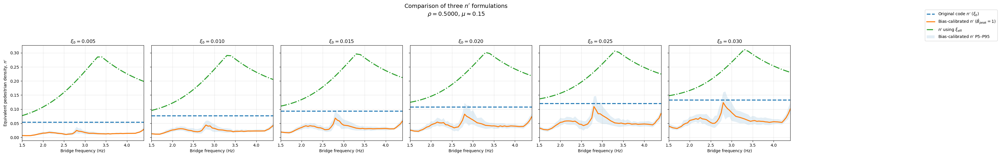

In [12]:
# ============================================================
# FIGURE 2
#
# COMPARE THREE n' CURVES:
#
# 1. Original code n'
#
#       n'_original = 10.8 * sqrt(N * xi_b) / S
#
# 2. Bias-calibrated n'
#
#       n'_bias = n'_original * residual mean bias
#
#    This forces mean peak-absolute-acceleration bias = 1
#
# 3. n' obtained by directly substituting xi_eff:
#
#       xi_eff = xi_b / frf_ratio
#
#       n'_xi_eff = 10.8 * sqrt(N * xi_eff) / S
#
# ============================================================


# ============================================================
# HELPER:
# COLLECT xi_eff AGAINST NOMINAL BRIDGE FREQUENCY
#
# We use the nominal bf dictionary key because this matches
# work_df["bridge_frequency"].
# ============================================================

def collect_bf_xieff(
    results_all,
    bands_to_combine,
    beamdamp_value,
    density_value,
    key_tol=1e-5
):

    rows = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        # Find matching structural damping key
        damp_key = nearest_float_key(
            results_all[band_name],
            beamdamp_value,
            tol=key_tol
        )

        if damp_key is None:
            continue

        freq_dict = results_all[band_name][damp_key]

        for bf in sorted(freq_dict.keys()):

            # Find matching density key
            density_key = nearest_float_key(
                freq_dict[bf],
                density_value,
                tol=key_tol
            )

            if density_key is None:
                continue

            data = freq_dict[bf][density_key]

            if "frf_ratio" not in data:
                continue

            frf_ratio = np.asarray(
                data["frf_ratio"],
                dtype=float
            ).reshape(-1)

            valid = (
                np.isfinite(frf_ratio)
                & (frf_ratio > 0)
            )

            if not np.any(valid):
                continue

            # ------------------------------------------------
            # Effective damping
            #
            # Saved FRF ratio is inverse of equation ratio:
            #
            # xi_eff = xi_b / frf_ratio
            # ------------------------------------------------

            xi_eff_arr = (
                float(beamdamp_value)
                / frf_ratio[valid]
            )

            rows.append(
                {
                    "bridge_frequency": float(bf),
                    "xi_eff": np.nanmean(xi_eff_arr),
                }
            )

    if len(rows) == 0:

        return (
            np.array([], dtype=float),
            np.array([], dtype=float)
        )

    temp = pd.DataFrame(rows)

    # Average if same frequency occurs in multiple bands
    temp = (
        temp
        .groupby(
            "bridge_frequency",
            as_index=False
        )
        .agg(
            xi_eff=("xi_eff", "mean")
        )
        .sort_values(
            "bridge_frequency"
        )
    )

    return (
        temp["bridge_frequency"].to_numpy(dtype=float),
        temp["xi_eff"].to_numpy(dtype=float)
    )


# ============================================================
# ADD xi_eff AND n'_xi_eff TO work_df
# ============================================================

work_df["xi_eff"] = np.nan
work_df["nprime_xi_eff"] = np.nan


for damp in TARGET_DAMPINGS:

    # --------------------------------------------------------
    # Get effective damping from NMFR FRF ratios
    # --------------------------------------------------------

    bf_xi, xi_eff_vals = collect_bf_xieff(
        results_all=results_all,
        bands_to_combine=bands_to_combine,
        beamdamp_value=damp,
        density_value=TARGET_DENSITY
    )

    if len(bf_xi) < 2:

        print(
            f"Warning: not enough xi_eff data for "
            f"xi_b={damp:.3f}"
        )

        continue

    # --------------------------------------------------------
    # Rows belonging to this damping ratio
    # --------------------------------------------------------

    mask = np.isclose(
        work_df["target_beamdamp"],
        damp
    )

    freq_target = (
        work_df.loc[
            mask,
            "bridge_frequency"
        ]
        .to_numpy(dtype=float)
    )

    # --------------------------------------------------------
    # Interpolate xi_eff onto exactly the frequencies used
    # in the bias/n' calculation
    # --------------------------------------------------------

    xi_eff_interp = np.interp(
        freq_target,
        bf_xi,
        xi_eff_vals,
        left=np.nan,
        right=np.nan
    )

    work_df.loc[
        mask,
        "xi_eff"
    ] = xi_eff_interp


# ============================================================
# CALCULATE n' USING xi_eff
#
# Same existing n' equation, but substitute:
#
#       xi_b -> xi_eff
#
# n'_xi_eff =
#
#       10.8 sqrt(N * xi_eff) / S
# ============================================================

valid_xi = (
    np.isfinite(work_df["xi_eff"])
    & (work_df["xi_eff"] >= 0)
)

work_df.loc[
    valid_xi,
    "nprime_xi_eff"
] = (

    NPRIME_COEFFICIENT

    * np.sqrt(

        work_df.loc[
            valid_xi,
            "N_pedestrians"
        ]

        * work_df.loc[
            valid_xi,
            "xi_eff"
        ]

    )

    / AREA
)


# ============================================================
# OPTIONAL CHECK TABLE
# ============================================================

print("\n")
print("=" * 110)

print(
    "COMPARISON OF ORIGINAL, BIAS-CALIBRATED, "
    "AND xi_eff-SUBSTITUTED n'"
)

print("=" * 110)


check_cols = [
    "target_beamdamp",
    "bridge_frequency",

    "xi_eff",

    "nprime_original",
    "nprime_required_mean",
    "nprime_xi_eff",

    "bias_after_psi_mean",
]


print(
    work_df[
        check_cols
    ]
    .sort_values(
        [
            "target_beamdamp",
            "bridge_frequency",
        ]
    )
    .head(60)
    .to_string(index=False)
)


# ============================================================
# PLOT ALL THREE
# ============================================================

n_damp = len(
    TARGET_DAMPINGS
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=n_damp,
    figsize=(
        5.2 * n_damp,
        5.4
    ),
    sharex=True,
    sharey=True
)

if n_damp == 1:
    axes = [axes]


for ax, damp in zip(
    axes,
    TARGET_DAMPINGS
):

    sub = work_df[
        np.isclose(
            work_df["target_beamdamp"],
            damp
        )
    ].copy()

    sub = sub.sort_values(
        "bridge_frequency"
    )

    if sub.empty:

        ax.axis("off")
        continue


    # ========================================================
    # 1. ORIGINAL CODE n'
    # ========================================================

    ax.plot(
        sub["bridge_frequency"],
        sub["nprime_original"],

        linestyle="--",
        linewidth=2.4,
        marker=None,

        label=(
            r"Original code $n'$ "
            r"($\xi_b$)"
        )
    )


    # ========================================================
    # 2. BIAS-CALIBRATED n'
    #
    # Mean peak absolute acceleration bias = 1
    # after modified psi
    # ========================================================

    ax.plot(
        sub["bridge_frequency"],
        sub["nprime_required_mean"],

        linestyle="-",
        linewidth=2.4,

        label=(
            r"Bias-calibrated $n'$ "
            r"($\bar{B}_{peak}=1$)"
        )
    )


    # ========================================================
    # 3. n' USING EFFECTIVE DAMPING
    #
    # xi_eff from FRF ratio
    # ========================================================

    ax.plot(
        sub["bridge_frequency"],
        sub["nprime_xi_eff"],

        linestyle="-.",
        linewidth=2.4,

        label=(
            r"$n'$ using "
            r"$\xi_{\mathrm{eff}}$"
        )
    )


    # ========================================================
    # OPTIONAL P5-P95 RANGE OF BIAS-CALIBRATED n'
    # ========================================================

    if (
        "nprime_required_p5" in sub.columns
        and
        "nprime_required_p95" in sub.columns
    ):

        ax.fill_between(
            sub["bridge_frequency"],

            sub["nprime_required_p5"],
            sub["nprime_required_p95"],

            alpha=0.12,

            label=(
                r"Bias-calibrated "
                r"$n'$ P5–P95"
            )
        )


    # ========================================================
    # FORMATTING
    # ========================================================

    ax.set_title(
        rf"$\xi_b={damp:.3f}$"
    )

    ax.set_xlabel(
        "Bridge frequency (Hz)"
    )

    ax.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )

    ax.grid(
        True,
        alpha=0.30
    )


axes[0].set_ylabel(
    r"Equivalent pedestrian density, $n'$"
)


# ============================================================
# COMMON LEGEND
# ============================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,

    bbox_to_anchor=(
        1.01,
        0.95
    ),

    loc="upper left"
)


# ============================================================
# TITLE
# ============================================================

actual_mu = mass_ratio_label.get(
    round(float(TARGET_DENSITY), 4),
    TARGET_MASS_RATIO
)

fig.suptitle(

    r"Comparison of three $n'$ formulations"
    "\n"

    + fr"$\rho={TARGET_DENSITY:.4f}$, "
    + fr"$\mu\approx{actual_mu:.2f}$",

    fontsize=14
)


fig.tight_layout(
    rect=[
        0,
        0,
        0.87,
        0.90
    ]
)

plt.show()


Common y-axis:
0.0000 to 0.4690


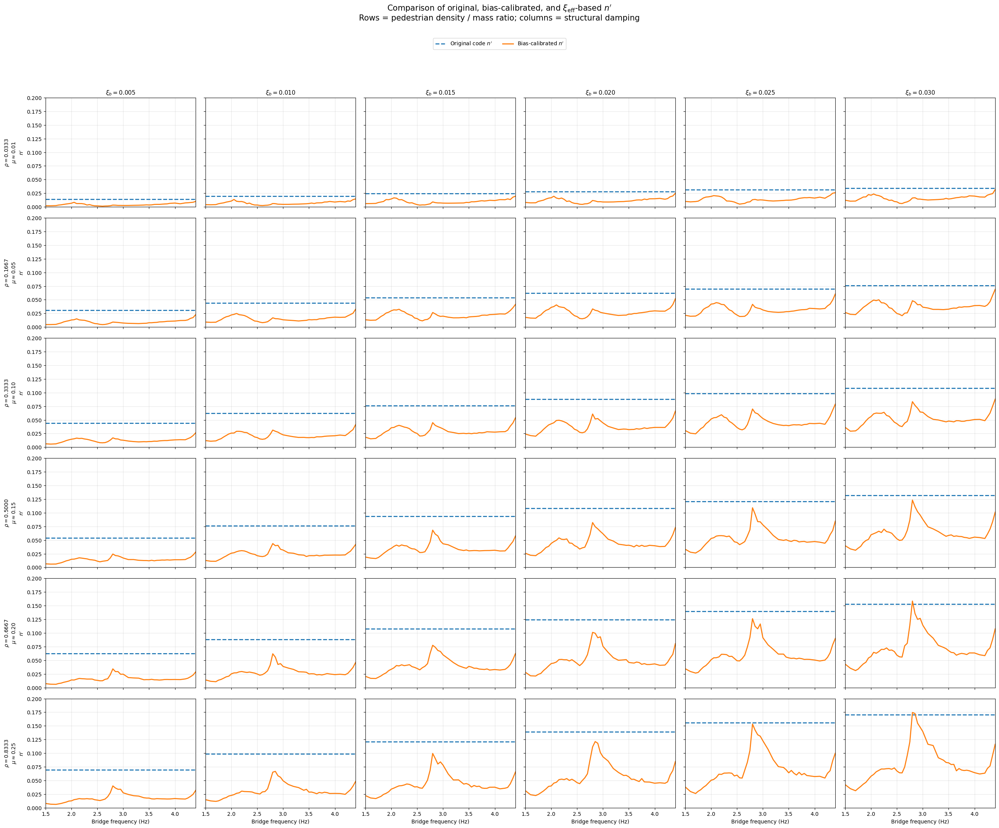

In [14]:
# ============================================================
# ALL DENSITIES × ALL DAMPINGS
#
# ROWS    = pedestrian density / mass ratio
# COLUMNS = structural damping ratio
#
# Each panel compares:
#
# 1. Original code n'
# 2. Bias-calibrated n' giving mean peak bias = 1
# 3. n' obtained using xi_eff from FRF ratio
#
# SAME Y-AXIS ACROSS ALL PANELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

DENSITIES_TO_PLOT = [
    0.0333,
    0.1667,
    0.3333,
    0.5000,
    0.6667,
    0.8333,
    
]

TARGET_DAMPINGS = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

MEASURE = "Peak absolute acceleration"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40

LENGTH = 50.0
WIDTH = 2.0
AREA = LENGTH * WIDTH

NPRIME_COEFFICIENT = 10.8

EPS = 1e-12

SHOW_P5_P95 = False


# Density -> approximate modal pedestrian mass ratio
mass_ratio_label = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}


# ============================================================
# HELPER:
# COLLECT EFFECTIVE DAMPING FROM FRF RATIO
#
# Stored ratio:
#
#     frf_ratio = |H_HSI| / |H_original|
#
# Therefore:
#
#     xi_eff = xi_b / frf_ratio
# ============================================================

def collect_bf_xieff(
    results_all,
    bands_to_combine,
    beamdamp_value,
    density_value,
    key_tol=1e-5,
):

    rows = []

    for band_name in bands_to_combine:

        if band_name not in results_all:
            continue

        damp_key = nearest_float_key(
            results_all[band_name],
            beamdamp_value,
            tol=key_tol,
        )

        if damp_key is None:
            continue

        freq_dict = results_all[band_name][damp_key]

        for bf in sorted(freq_dict.keys()):

            density_key = nearest_float_key(
                freq_dict[bf],
                density_value,
                tol=key_tol,
            )

            if density_key is None:
                continue

            data = freq_dict[bf][density_key]

            if "frf_ratio" not in data:
                continue

            frf_ratio = np.asarray(
                data["frf_ratio"],
                dtype=float,
            ).reshape(-1)

            valid = (
                np.isfinite(frf_ratio)
                & (frf_ratio > 0)
            )

            if not np.any(valid):
                continue

            xi_eff_arr = (
                float(beamdamp_value)
                / frf_ratio[valid]
            )

            rows.append(
                {
                    "bridge_frequency": float(bf),
                    "xi_eff": np.nanmean(xi_eff_arr),
                }
            )

    if len(rows) == 0:

        return (
            np.array([], dtype=float),
            np.array([], dtype=float),
        )

    temp = (
        pd.DataFrame(rows)
        .groupby(
            "bridge_frequency",
            as_index=False,
        )
        .agg(
            xi_eff=("xi_eff", "mean")
        )
        .sort_values(
            "bridge_frequency"
        )
    )

    return (
        temp["bridge_frequency"].to_numpy(dtype=float),
        temp["xi_eff"].to_numpy(dtype=float),
    )


# ============================================================
# BUILD DATAFRAME CONTAINING ALL DENSITIES
#
# Do NOT use the old work_df because it was filtered
# to only TARGET_DENSITY.
# ============================================================

df_all = corrected_df.copy()


required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "measure",
    "code_bias_mean",
]

missing = [
    col
    for col in required_cols
    if col not in df_all.columns
]

if missing:
    raise KeyError(
        f"Missing columns in corrected_df: {missing}"
    )


# Numeric conversion
for col in [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "code_bias_mean",
]:

    df_all[col] = pd.to_numeric(
        df_all[col],
        errors="coerce",
    )


# Optional percentile bias
for col in [
    "code_bias_p5",
    "code_bias_p95",
]:

    if col in df_all.columns:

        df_all[col] = pd.to_numeric(
            df_all[col],
            errors="coerce",
        )


df_all["measure"] = (
    df_all["measure"]
    .astype(str)
    .str.strip()
)


# ============================================================
# FILTER:
# ALL REQUESTED DENSITIES
# ALL REQUESTED DAMPINGS
# PEAK ABSOLUTE ACCELERATION
# FREQUENCY RANGE
# ============================================================

density_mask = np.zeros(
    len(df_all),
    dtype=bool,
)

for density in DENSITIES_TO_PLOT:

    density_mask |= np.isclose(
        df_all["target_density"],
        density,
    )


damping_mask = np.zeros(
    len(df_all),
    dtype=bool,
)

for damp in TARGET_DAMPINGS:

    damping_mask |= np.isclose(
        df_all["target_beamdamp"],
        damp,
    )


work_all_df = df_all[
    density_mask
    & damping_mask
    & (
        df_all["measure"]
        == MEASURE
    )
    & (
        df_all["bridge_frequency"]
        >= PLOT_FMIN
    )
    & (
        df_all["bridge_frequency"]
        <= PLOT_FMAX
    )
].copy()


if work_all_df.empty:

    raise ValueError(
        "No data found after filtering."
    )


# ============================================================
# ORIGINAL PSI AND MODIFIED PSI
# ============================================================

frequencies = (
    work_all_df["bridge_frequency"]
    .to_numpy(dtype=float)
)

work_all_df["psi_original"] = (
    psi_original(frequencies)
)

work_all_df["psi_modified"] = (
    psi_envelope(frequencies)
)

work_all_df["psi_original_safe"] = (
    work_all_df["psi_original"]
    .clip(lower=EPS)
)

work_all_df["psi_modified_safe"] = (
    work_all_df["psi_modified"]
    .clip(lower=EPS)
)


# ============================================================
# RESIDUAL BIAS AFTER MODIFYING PSI ONLY
#
# B_psi =
#
# B_original * psi_original / psi_modified
#
# This is the MEAN BIAS OF PEAK ABSOLUTE ACCELERATION
# after the psi correction.
# ============================================================

work_all_df["bias_after_psi_mean"] = (

    work_all_df["code_bias_mean"]

    * work_all_df["psi_original_safe"]

    / work_all_df["psi_modified_safe"]
)


if "code_bias_p5" in work_all_df.columns:

    work_all_df["bias_after_psi_p5"] = (

        work_all_df["code_bias_p5"]

        * work_all_df["psi_original_safe"]

        / work_all_df["psi_modified_safe"]
    )


if "code_bias_p95" in work_all_df.columns:

    work_all_df["bias_after_psi_p95"] = (

        work_all_df["code_bias_p95"]

        * work_all_df["psi_original_safe"]

        / work_all_df["psi_modified_safe"]
    )


# ============================================================
# NUMBER OF PEDESTRIANS
#
# N = density * area
# ============================================================

work_all_df["N_pedestrians"] = (

    work_all_df["target_density"]

    * AREA
)


# ============================================================
# 1. ORIGINAL CODE n'
#
# Same formulation as your current code:
#
# n' = 10.8 sqrt(N xi_b) / S
# ============================================================

work_all_df["nprime_original"] = (

    NPRIME_COEFFICIENT

    * np.sqrt(

        work_all_df["N_pedestrians"]

        * work_all_df["target_beamdamp"]

    )

    / AREA
)


# ============================================================
# 2. BIAS-CALIBRATED n'
#
# Required to make:
#
# mean bias of peak absolute acceleration = 1
#
# after modified psi
# ============================================================

work_all_df["nprime_required_mean"] = (

    work_all_df["nprime_original"]

    * work_all_df["bias_after_psi_mean"]
)


if "bias_after_psi_p5" in work_all_df.columns:

    work_all_df["nprime_required_p5"] = (

        work_all_df["nprime_original"]

        * work_all_df["bias_after_psi_p5"]
    )


if "bias_after_psi_p95" in work_all_df.columns:

    work_all_df["nprime_required_p95"] = (

        work_all_df["nprime_original"]

        * work_all_df["bias_after_psi_p95"]
    )


# ============================================================
# 3. GET xi_eff FOR EVERY DENSITY × DAMPING COMBINATION
# ============================================================

work_all_df["xi_eff"] = np.nan


for density in DENSITIES_TO_PLOT:

    for damp in TARGET_DAMPINGS:

        bf_xi, xi_eff_vals = collect_bf_xieff(

            results_all=results_all,

            bands_to_combine=bands_to_combine,

            beamdamp_value=damp,

            density_value=density,
        )


        if len(bf_xi) < 2:

            print(
                f"Warning: insufficient xi_eff data: "
                f"density={density:.4f}, "
                f"xi_b={damp:.3f}"
            )

            continue


        mask = (

            np.isclose(
                work_all_df["target_density"],
                density,
            )

            &

            np.isclose(
                work_all_df["target_beamdamp"],
                damp,
            )
        )


        if not mask.any():
            continue


        freq_target = (

            work_all_df.loc[
                mask,
                "bridge_frequency"
            ]

            .to_numpy(dtype=float)
        )


        xi_eff_interp = np.interp(

            freq_target,

            bf_xi,

            xi_eff_vals,

            left=np.nan,

            right=np.nan,
        )


        work_all_df.loc[
            mask,
            "xi_eff"
        ] = xi_eff_interp


# ============================================================
# CALCULATE n' USING xi_eff
#
# n'_xi_eff =
#
# 10.8 sqrt(N xi_eff) / S
# ============================================================

work_all_df["nprime_xi_eff"] = np.nan


valid_xi = (

    np.isfinite(
        work_all_df["xi_eff"]
    )

    &

    (
        work_all_df["xi_eff"]
        >= 0
    )
)


work_all_df.loc[
    valid_xi,
    "nprime_xi_eff"
] = (

    NPRIME_COEFFICIENT

    * np.sqrt(

        work_all_df.loc[
            valid_xi,
            "N_pedestrians"
        ]

        *

        work_all_df.loc[
            valid_xi,
            "xi_eff"
        ]

    )

    / AREA
)


# ============================================================
# GLOBAL Y-AXIS LIMIT
#
# SAME Y AXIS FOR:
# - all 7 densities
# - all 6 damping ratios
# - all 3 n' curves
#
# This allows direct visual comparison.
# ============================================================

y_arrays = [
    work_all_df[
        "nprime_original"
    ].dropna().to_numpy(),

    work_all_df[
        "nprime_required_mean"
    ].dropna().to_numpy(),

    work_all_df[
        "nprime_xi_eff"
    ].dropna().to_numpy(),
]


if (
    SHOW_P5_P95
    and
    "nprime_required_p5"
    in work_all_df.columns
    and
    "nprime_required_p95"
    in work_all_df.columns
):

    y_arrays.extend(
        [
            work_all_df[
                "nprime_required_p5"
            ].dropna().to_numpy(),

            work_all_df[
                "nprime_required_p95"
            ].dropna().to_numpy(),
        ]
    )


all_y = np.concatenate(
    [
        arr
        for arr in y_arrays
        if len(arr) > 0
    ]
)


YMIN_NPRIME = 0.0

YMAX_NPRIME = (
    1.05
    * np.nanmax(all_y)
)


print(
    "\nCommon y-axis:"
)

print(
    f"{YMIN_NPRIME:.4f} "
    f"to {YMAX_NPRIME:.4f}"
)


# ============================================================
# PLOT GRID
#
# ROW    = density / mass ratio
# COLUMN = damping ratio
# ============================================================

n_rows = len(
    DENSITIES_TO_PLOT
)

n_cols = len(
    TARGET_DAMPINGS
)


fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(
        4.4 * n_cols,
        3.5 * n_rows
    ),

    sharex=True,

    sharey=True,
)


# Make axes always 2D
axes = np.atleast_2d(
    axes
)


for row_i, density in enumerate(
    DENSITIES_TO_PLOT
):

    mu = mass_ratio_label.get(
        round(float(density), 4),
        np.nan,
    )


    for col_i, damp in enumerate(
        TARGET_DAMPINGS
    ):

        ax = axes[
            row_i,
            col_i
        ]


        sub = work_all_df[

            np.isclose(
                work_all_df[
                    "target_density"
                ],
                density,
            )

            &

            np.isclose(
                work_all_df[
                    "target_beamdamp"
                ],
                damp,
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            ax.axis("off")
            continue


        # ====================================================
        # 1. ORIGINAL CODE n'
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "nprime_original"
            ],

            linestyle="--",

            linewidth=2.0,

            label=(
                r"Original code $n'$"
            ),
        )


        # ====================================================
        # 2. BIAS-CALIBRATED n'
        #
        # Mean peak absolute acceleration bias = 1
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "nprime_required_mean"
            ],

            linestyle="-",

            linewidth=2.0,

            label=(
                r"Bias-calibrated $n'$"
            ),
        )


        # ====================================================
        # 3. n' USING xi_eff
        # ====================================================

        

        # ====================================================
        # OPTIONAL P5-P95 BAND
        # ====================================================

        if (
            SHOW_P5_P95

            and

            "nprime_required_p5"
            in sub.columns

            and

            "nprime_required_p95"
            in sub.columns
        ):

            ax.fill_between(

                sub[
                    "bridge_frequency"
                ],

                sub[
                    "nprime_required_p5"
                ],

                sub[
                    "nprime_required_p95"
                ],

                alpha=0.12,

                label="P5–P95",
            )


        # ====================================================
        # SAME AXES ACROSS ENTIRE GRID
        # ====================================================

        ax.set_xlim(
            PLOT_FMIN,
            PLOT_FMAX,
        )

        ax.set_ylim(
            0,
            0.2,
        )


        ax.grid(
            True,
            alpha=0.30,
        )


        # ====================================================
        # COLUMN TITLES = DAMPING
        # ====================================================

        if row_i == 0:

            ax.set_title(
                rf"$\xi_b={damp:.3f}$",
                fontsize=11,
            )


        # ====================================================
        # BOTTOM ROW X LABEL
        # ====================================================

        if row_i == n_rows - 1:

            ax.set_xlabel(
                "Bridge frequency (Hz)"
            )


        # ====================================================
        # FIRST COLUMN:
        # DENSITY + MASS RATIO
        # ====================================================

        if col_i == 0:

            ax.set_ylabel(

                rf"$\rho={density:.4f}$"
                "\n"
                rf"$\mu\approx{mu:.2f}$"
                "\n"
                r"$n'$"
            )


# ============================================================
# COMMON LEGEND
# ============================================================

handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)


fig.legend(

    handles,

    labels,

    loc="upper center",

    bbox_to_anchor=(
        0.5,
        0.995
    ),

    ncol=3,

    frameon=True,
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(

    r"Comparison of original, bias-calibrated, "
    r"and $\xi_{\mathrm{eff}}$-based $n'$"
    "\n"
    r"Rows = pedestrian density / mass ratio; "
    r"columns = structural damping",

    fontsize=15,

    y=1.035,
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.965,
    ]
)


plt.show()

Maximum difference between C_nprime and residual mean bias:
1.1102230246251565e-16

Global correction-factor range:
0.000 to 1.090

Overall correction-factor statistics
Minimum = 0.0883
Mean    = 0.3901
Median  = 0.3739
Maximum = 1.0380


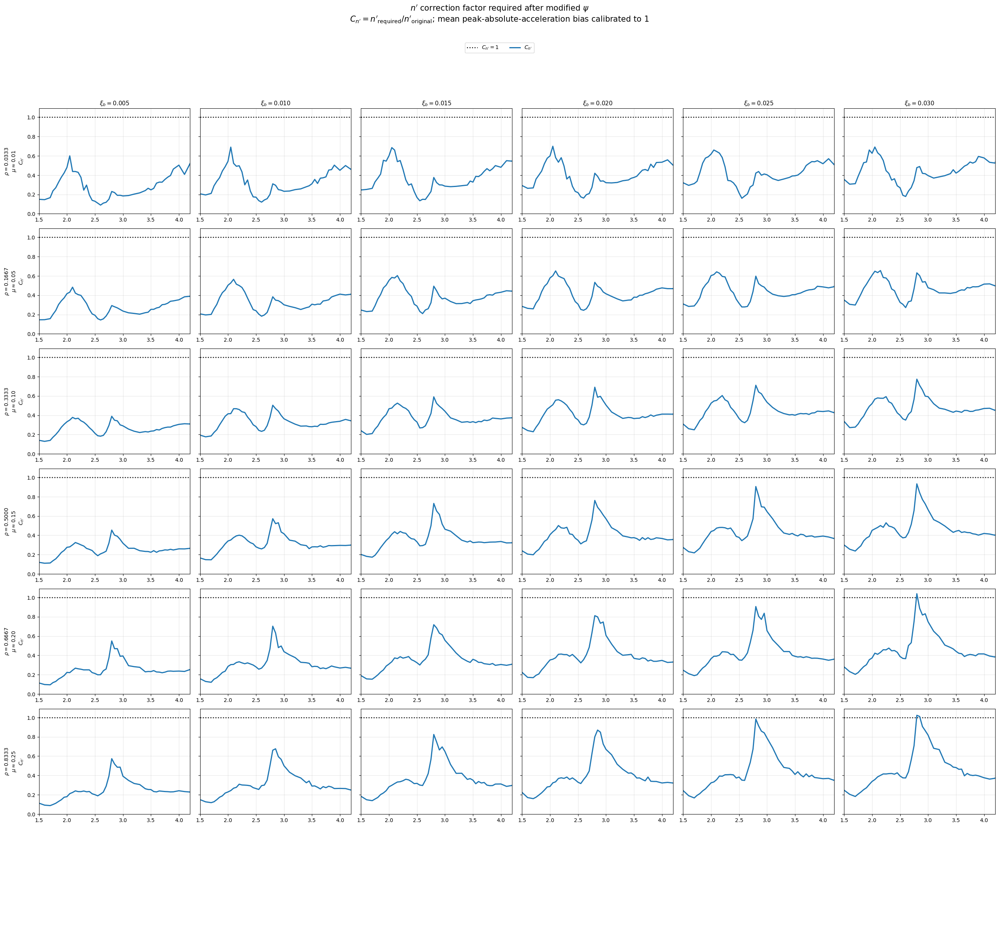

In [27]:
# ============================================================
# n' CORRECTION FACTOR
#
# C_nprime = n'_required / n'_original
#
# Since:
#
# n'_required = n'_original * bias_after_psi_mean
#
# therefore:
#
# C_nprime = bias_after_psi_mean
#
# ROWS    = density / mass ratio
# COLUMNS = structural damping ratio
#
# SAME Y-AXIS ACROSS ALL PANELS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

DENSITIES_TO_PLOT = [
    0.0333,
    0.1667,
    0.3333,
    0.5000,
    0.6667,
    0.8333,
    1.0000,
]

TARGET_DAMPINGS = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

PLOT_FMIN = 1.50
PLOT_FMAX = 4.40


mass_ratio_label = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
    1.0:    0.30,
}


# ============================================================
# CHECK REQUIRED DATA
# ============================================================

if "work_all_df" not in globals():

    raise NameError(
        "work_all_df does not exist.\n"
        "Run the previous all-density n' calculation first."
    )


required_columns = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "nprime_original",
    "nprime_required_mean",
]

missing = [
    col for col in required_columns
    if col not in work_all_df.columns
]

if missing:

    raise KeyError(
        f"Missing required columns: {missing}"
    )


# ============================================================
# CALCULATE n' CORRECTION FACTOR
#
# C_nprime = required / original
# ============================================================

work_all_df["nprime_correction_factor"] = (

    work_all_df["nprime_required_mean"]

    / work_all_df["nprime_original"]
)


# Remove inf values if any
work_all_df["nprime_correction_factor"] = (

    work_all_df["nprime_correction_factor"]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)


# ============================================================
# CHECK:
#
# This should be identical to bias_after_psi_mean
# apart from numerical round-off.
# ============================================================

if "bias_after_psi_mean" in work_all_df.columns:

    difference = (

        work_all_df["nprime_correction_factor"]

        - work_all_df["bias_after_psi_mean"]
    )

    print(
        "Maximum difference between "
        "C_nprime and residual mean bias:"
    )

    print(
        np.nanmax(
            np.abs(difference)
        )
    )


# ============================================================
# GLOBAL Y-AXIS
#
# SAME SCALE FOR ALL 42 PANELS
# ============================================================

all_factors = (

    work_all_df[
        "nprime_correction_factor"
    ]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna()

    .to_numpy(dtype=float)
)


if len(all_factors) == 0:

    raise ValueError(
        "No valid n' correction factors found."
    )


# Include 1.0 in the common range
YMIN_FACTOR = min(
    0.0,
    np.nanmin(all_factors) * 0.95
)

YMAX_FACTOR = max(
    1.05,
    np.nanmax(all_factors) * 1.05
)


print("\nGlobal correction-factor range:")
print(
    f"{YMIN_FACTOR:.3f} "
    f"to {YMAX_FACTOR:.3f}"
)


# ============================================================
# OPTIONAL SUMMARY
# ============================================================

print("\nOverall correction-factor statistics")
print("=" * 60)

print(
    f"Minimum = "
    f"{np.nanmin(all_factors):.4f}"
)

print(
    f"Mean    = "
    f"{np.nanmean(all_factors):.4f}"
)

print(
    f"Median  = "
    f"{np.nanmedian(all_factors):.4f}"
)

print(
    f"Maximum = "
    f"{np.nanmax(all_factors):.4f}"
)


# ============================================================
# BIG GRID
#
# ROW    = density / mass ratio
# COLUMN = damping ratio
# ============================================================

n_rows = len(
    DENSITIES_TO_PLOT
)

n_cols = len(
    TARGET_DAMPINGS
)


fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(
        4.4 * n_cols,
        3.4 * n_rows
    ),

    sharex=True,

    sharey=True,
)


axes = np.atleast_2d(
    axes
)


for row_i, density in enumerate(
    DENSITIES_TO_PLOT
):

    mu = mass_ratio_label.get(
        round(float(density), 4),
        np.nan
    )


    for col_i, damp in enumerate(
        TARGET_DAMPINGS
    ):

        ax = axes[
            row_i,
            col_i
        ]


        # ----------------------------------------------------
        # Select this density × damping
        # ----------------------------------------------------

        sub = work_all_df[

            np.isclose(
                work_all_df[
                    "target_density"
                ],
                density
            )

            &

            np.isclose(
                work_all_df[
                    "target_beamdamp"
                ],
                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            ax.axis("off")
            continue


        # ----------------------------------------------------
        # Bias = 1 / correction = 1 reference
        # ----------------------------------------------------

        ax.axhline(

            1.0,

            color="black",

            linestyle=":",

            linewidth=1.8,

            label=r"$C_{n'}=1$",
        )


        # ----------------------------------------------------
        # n' CORRECTION FACTOR
        # ----------------------------------------------------

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "nprime_correction_factor"
            ],

            linewidth=2.2,

            label=r"$C_{n'}$",
        )


        # ----------------------------------------------------
        # AXES
        # ----------------------------------------------------

        ax.set_xlim(
            1.50,
            4.20
        )

        ax.set_ylim(
            YMIN_FACTOR,
            YMAX_FACTOR
        )

        # Explicit x-axis ticks
        ax.set_xticks(
            np.arange(1.5, 4.21, 0.5)
        )

        # Show x-axis numbers on every subplot
        ax.tick_params(
            axis="x",
            labelbottom=True
        )

        ax.grid(
            True,
            alpha=0.30
        )
        # ----------------------------------------------------
        # COLUMN TITLE = STRUCTURAL DAMPING
        # ----------------------------------------------------

        if row_i == 0:

            ax.set_title(

                rf"$\xi_b={damp:.3f}$",

                fontsize=11
            )


        # ----------------------------------------------------
        # X LABEL ON BOTTOM ROW
        # ----------------------------------------------------

        if row_i == n_rows - 1:

            ax.set_xlabel(
                "Bridge frequency (Hz)"
            )


        # ----------------------------------------------------
        # ROW LABEL = DENSITY + MASS RATIO
        # ----------------------------------------------------

        if col_i == 0:

            ax.set_ylabel(

                rf"$\rho={density:.4f}$"
                "\n"
                rf"$\mu\approx{mu:.2f}$"
                "\n"
                rf"$C_{{n'}}$"
            )


# ============================================================
# COMMON LEGEND
# ============================================================

handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)


fig.legend(

    handles,
    labels,

    loc="upper center",

    bbox_to_anchor=(
        0.5,
        0.995
    ),

    ncol=2,

    frameon=True,
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(

    r"$n'$ correction factor required after modified $\psi$"
    "\n"
    r"$C_{n'}=n'_{\rm required}/n'_{\rm original}$; "
    r"mean peak-absolute-acceleration bias calibrated to 1",

    fontsize=15,

    y=1.035,
)


fig.tight_layout(

    rect=[
        0,
        0,
        1,
        0.965
    ]
)


plt.show()

Loading new factor file: density0.0333_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.005_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.010_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.015_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S125_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S456_bias_summary.pkl
Loading new factor file: density0.0333_damping0.020_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.025_0S_bias_summary.pkl
Loading new factor file: density0.0333_damping0.030_0S_bias_summary.pkl
Loading new factor file: density0.1667_damping0.005_0S125_bias_summary.pkl
Loading new factor file: density0.1667_damp

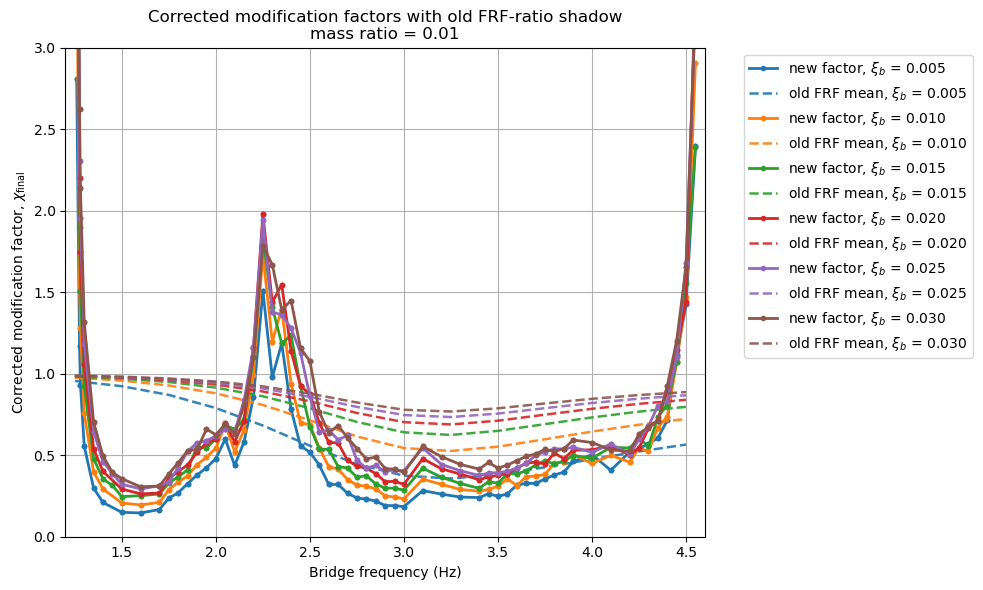

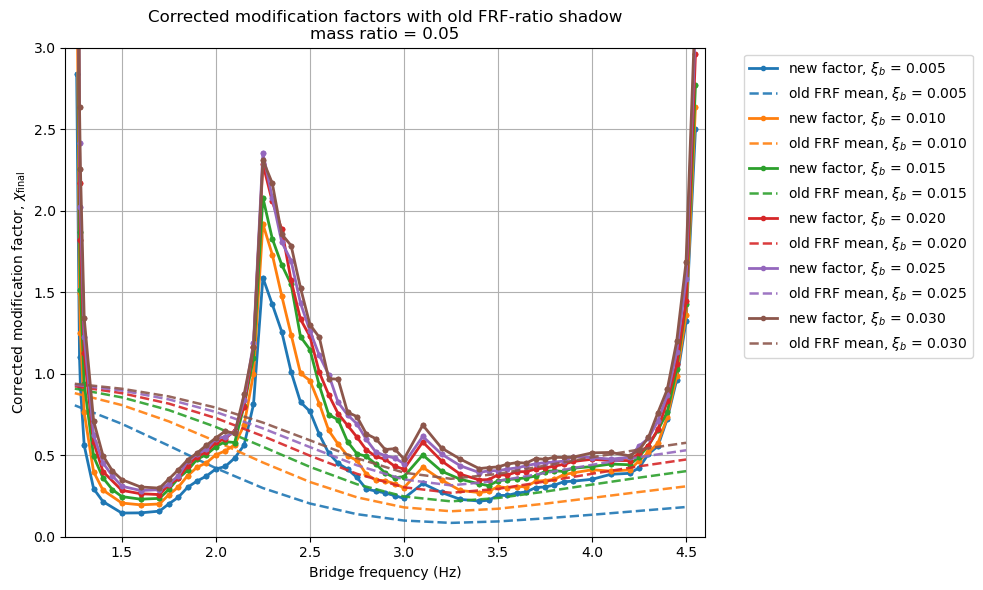

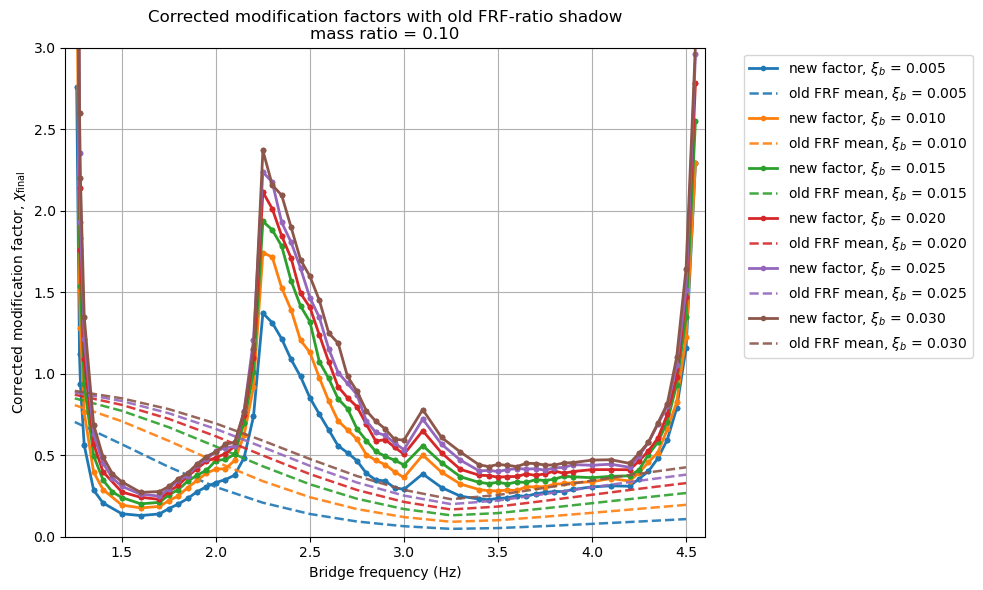

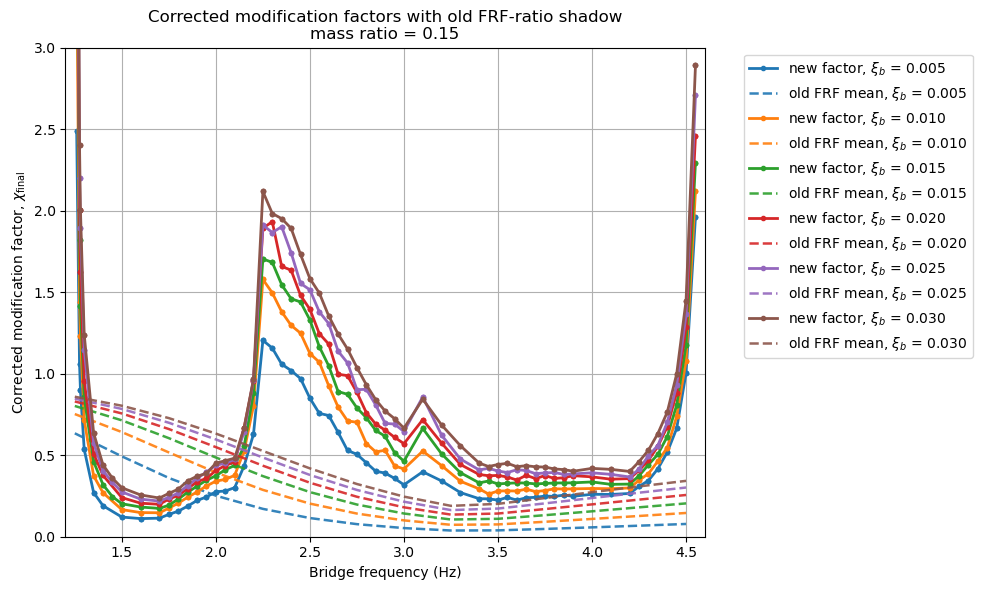

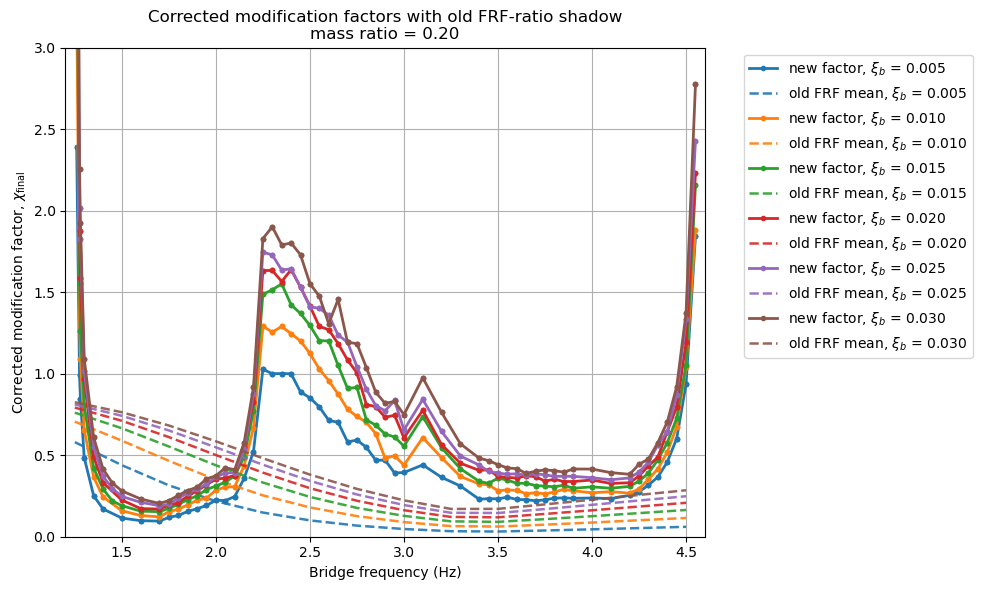

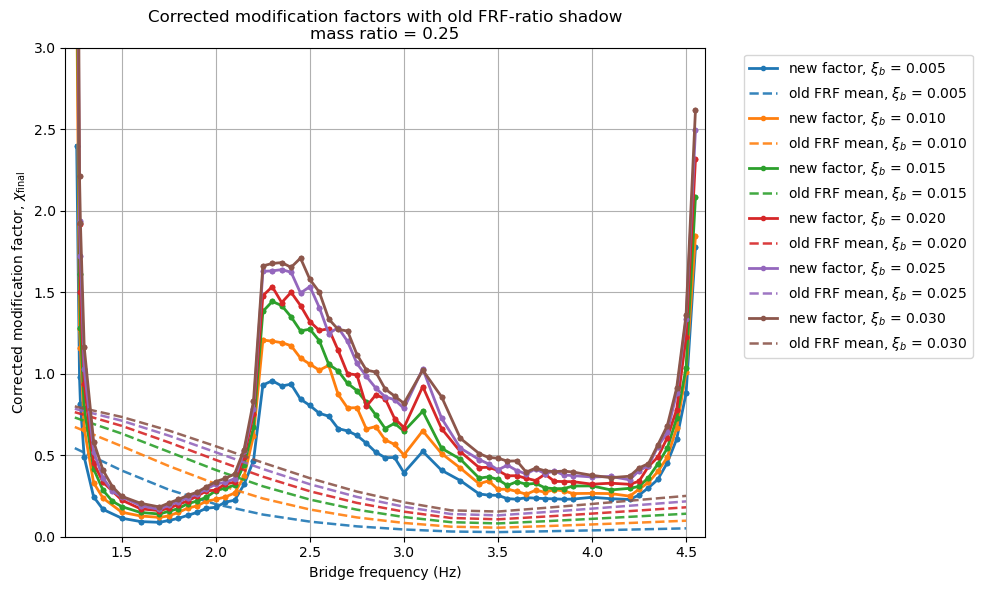

In [17]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# SETTINGS
# ==================================================

folder = Path(".")

PLOT_COLUMN = "final_modification_factor"
MEASURE_TO_PLOT = None

OLD_FRF_PKL = folder / "forcefactors_bridgeF_bridgedamp.pkl"

DAMPINGS_TO_COMPARE = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030]

# Old FRF suggestion only for densities < 1
MAX_DENSITY_FOR_OLD_FRF = 1.0

SAVE_PLOTS = False

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    1.0000: 0.30,
}

ylabel_map = {
    "final_modification_factor": r"Corrected modification factor, $\chi_{\mathrm{final}}$",
    "initial_modification_factor": r"Initial modification factor, $\chi_0$",
    "residual_correction_factor": r"Residual correction factor, $\lambda$",
    "code_bias_mean": "Mean code bias",
    "simplified_bias_mean": "Mean simplified bias",
    "corrected_bias_mean": "Mean corrected bias",
}

ylabel = ylabel_map.get(PLOT_COLUMN, PLOT_COLUMN.replace("_", " "))

# ==================================================
# LOAD NEW CORRECTED MODIFICATION FACTORS
# ==================================================

pattern = re.compile(
    r"density(?P<density>\d+\.\d+)_"
    r"damping(?P<damping>\d+\.\d+)_"
    r"(?P<region>0S(?:125|456)?)_bias_summary\.pkl$"
)

pkl_files = sorted(folder.glob("density*_damping*_0S*_bias_summary.pkl"))

all_dfs = []

for file in pkl_files:
    match = pattern.match(file.name)

    if match is None:
        print(f"Skipping file because name does not match expected format: {file.name}")
        continue

    file_density = float(match.group("density"))
    file_damping = float(match.group("damping"))
    file_region = match.group("region")

    print("Loading new factor file:", file.name)

    with open(file, "rb") as f:
        df = pickle.load(f)

    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    df = df.copy()

    df["source_file"] = file.name
    df["file_density"] = file_density
    df["file_damping"] = file_damping
    df["file_region"] = file_region

    if "target_density" not in df.columns:
        df["target_density"] = file_density

    if "target_beamdamp" not in df.columns:
        df["target_beamdamp"] = file_damping

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise FileNotFoundError("No matching new modification-factor summary files were found.")

corrected_df = pd.concat(all_dfs, ignore_index=True)

needed_cols = [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    PLOT_COLUMN,
]

for col in needed_cols:
    corrected_df[col] = pd.to_numeric(corrected_df[col], errors="coerce")

corrected_df = corrected_df.dropna(subset=needed_cols).copy()

corrected_df["density_key"] = corrected_df["target_density"].round(4)
corrected_df["damping_key"] = corrected_df["target_beamdamp"].round(3)

if MEASURE_TO_PLOT is not None:
    if "measure" not in corrected_df.columns:
        raise KeyError("MEASURE_TO_PLOT is set, but dataframe has no 'measure' column.")

    corrected_df = corrected_df[
        corrected_df["measure"].astype(str) == MEASURE_TO_PLOT
    ].copy()

    if corrected_df.empty:
        raise ValueError(f"No rows found for measure: {MEASURE_TO_PLOT}")

# Keep the intended frequency ranges from 0S, 0S125, and 0S456
# ==================================================
# KEEP FREQUENCY REGIONS INTELLIGENTLY
# ==================================================
# For old damping cases, you may have:
#   0S125 = low range
#   0S    = middle range
#   0S456 = high range
#
# For newer damping cases, such as 0.015, 0.025, 0.030,
#   0S already contains the full frequency range.
#
# Therefore:
#   - if only 0S exists for a density/damping case, keep all 0S frequencies
#   - if 0S125/0S456 also exist, stitch the regions as before

stitched_parts = []

for (damp_key, density_key), g in corrected_df.groupby(["damping_key", "density_key"]):

    available_regions = set(g["file_region"].dropna().unique())

    # Case A: only 0S exists -> keep full range
    if available_regions == {"0S"}:
        stitched_parts.append(g.copy())
        continue

    # Case B: multiple regional files exist -> stitch them
    g_keep = g[
        (
            (g["file_region"] == "0S125") &
            (g["bridge_frequency"] < 1.40)
        )
        |
        (
            (g["file_region"] == "0S") &
            (g["bridge_frequency"] >= 1.40) &
            (g["bridge_frequency"] <= 3.40)
        )
        |
        (
            (g["file_region"] == "0S456") &
            (g["bridge_frequency"] > 3.40)
        )
    ].copy()

    # Safety fallback:
    # If stitching removed everything for some unexpected naming case,
    # keep all available rows.
    if g_keep.empty:
        print(
            f"Warning: stitching removed all rows for "
            f"damping={damp_key}, density={density_key}. Keeping all rows."
        )
        g_keep = g.copy()

    stitched_parts.append(g_keep)

corrected_df = pd.concat(stitched_parts, ignore_index=True)


        
corrected_df = corrected_df.sort_values(
    ["damping_key", "density_key", "bridge_frequency"]
)

# Remove duplicates from multiple response measures
# ==================================================
# KEEP ALL RESPONSE MEASURES
# Remove only true duplicate rows
# ==================================================

corrected_df["measure"] = corrected_df["measure"].astype(str).str.strip()

corrected_df = corrected_df.drop_duplicates(
    subset=[
        "damping_key",
        "density_key",
        "bridge_frequency",
        "measure",
    ],
    keep="first"
).copy()

print("\nMeasure coverage after keeping all measures:")
print(corrected_df["measure"].value_counts().to_string())
# Keep only the damping ratios we want
corrected_df = corrected_df[
    corrected_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

print("\nNew corrected-factor coverage:")
print(
    corrected_df
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# LOAD OLD FRF-RATIO PKL
# Your saved structure:
# results_all[beamdamp][bf][density]["accel_ratio"]
# ==================================================

if not OLD_FRF_PKL.exists():
    raise FileNotFoundError(f"Old FRF-ratio pkl not found: {OLD_FRF_PKL}")

with open(OLD_FRF_PKL, "rb") as f:
    old_data = pickle.load(f)

results_all = old_data["results_all"]

print("\nLoaded old FRF-ratio file:", OLD_FRF_PKL.name)
print("Saved damping values:", old_data.get("damping_values", "not found"))
print("Saved densities:", old_data.get("densities", "not found"))
print("Saved NUM_SIMULATIONS:", old_data.get("NUM_SIMULATIONS", "not found"))

# ==================================================
# EXTRACT OLD FRF RATIOS DIRECTLY FROM NESTED DICT
# ==================================================

frf_rows = []

for beamdamp, freq_dict in results_all.items():

    beamdamp_float = float(beamdamp)

    for bf, density_dict in freq_dict.items():

        bf_float = float(bf)

        for density, data in density_dict.items():

            density_float = float(density)

            if not isinstance(data, dict):
                print(f"Skipping non-dict entry: damping={beamdamp}, bf={bf}, density={density}")
                continue

            if "accel_ratio" not in data:
                print(f"Skipping entry with no accel_ratio: damping={beamdamp}, bf={bf}, density={density}")
                continue

            accel_values = np.asarray(data["accel_ratio"], dtype=float).ravel()

            for sim_id, accel_ratio in enumerate(accel_values):
                if np.isfinite(accel_ratio):
                    frf_rows.append({
                        "target_beamdamp": beamdamp_float,
                        "bridge_frequency": bf_float,
                        "target_density": density_float,
                        "simulation": sim_id,
                        "accel_ratio": float(accel_ratio),
                    })

frf_df = pd.DataFrame(frf_rows)

if frf_df.empty:
    raise ValueError("No old FRF accel_ratio values were extracted.")

frf_df["density_key"] = frf_df["target_density"].round(4)
frf_df["damping_key"] = frf_df["target_beamdamp"].round(3)

# Keep only the damping ratios we want
frf_df = frf_df[
    frf_df["damping_key"].isin([round(x, 3) for x in DAMPINGS_TO_COMPARE])
].copy()

# Old FRF overlay only for densities < 1
frf_df = frf_df[
    frf_df["target_density"] < MAX_DENSITY_FOR_OLD_FRF
].copy()

frf_summary = (
    frf_df
    .groupby(["damping_key", "density_key", "bridge_frequency"])["accel_ratio"]
    .agg(
        frf_mean="mean",
        frf_p5=lambda x: np.percentile(x, 5),
        frf_p50="median",
        frf_p95=lambda x: np.percentile(x, 95),
        n="count",
    )
    .reset_index()
)

print("\nOld FRF-ratio summary coverage:")
print(
    frf_summary
    .groupby(["damping_key", "density_key"])["bridge_frequency"]
    .agg(["min", "max", "count"])
    .reset_index()
)

# ==================================================
# PLOT: ONE FIGURE PER MASS RATIO, COMPARE 3 DAMPINGS
# ==================================================

for density in sorted(corrected_df["density_key"].dropna().unique()):

    # You said the FRF comparison is for densities less than 1
    if density >= MAX_DENSITY_FOR_OLD_FRF:
        continue

    mr = density_to_mass_ratio.get(round(float(density), 4), None)

    if mr is not None:
        title_density = f"mass ratio = {mr:.2f}"
        out_density = f"massratio{mr:.2f}"
    else:
        title_density = f"density = {density:.4f}"
        out_density = f"density{density:.4f}"

    plt.figure(figsize=(10, 6))

    for damp in DAMPINGS_TO_COMPARE:

        damp_key = round(damp, 3)

        # ---------------- New corrected factor ----------------
        sub = corrected_df[
            np.isclose(corrected_df["density_key"], density) &
            np.isclose(corrected_df["damping_key"], damp_key)
        ].copy()

        sub = sub.sort_values("bridge_frequency")

        if sub.empty:
            print(f"No corrected factor data for density={density:.4f}, damping={damp:.3f}")
            continue

        line = plt.plot(
            sub["bridge_frequency"].values,
            sub[PLOT_COLUMN].values,
            marker="o",
            markersize=3,
            linewidth=2,
            label=rf"new factor, $\xi_b$ = {damp:.3f}",
        )[0]

        line_color = line.get_color()

        # ---------------- Old FRF-ratio shadow ----------------
        frf_sub = frf_summary[
            np.isclose(frf_summary["density_key"], density) &
            np.isclose(frf_summary["damping_key"], damp_key)
        ].copy()

        # Limit old FRF to the plot frequency range
        frf_sub = frf_sub[
            (frf_sub["bridge_frequency"] >= 1.2) &
            (frf_sub["bridge_frequency"] <= 4.6)
        ].copy()

        frf_sub = frf_sub.sort_values("bridge_frequency")

        if not frf_sub.empty:
            plt.fill_between(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_p5"].values,
                frf_sub["frf_p95"].values,
                color=line_color,
                alpha=0.15,
                linewidth=0,
            )

            plt.plot(
                frf_sub["bridge_frequency"].values,
                frf_sub["frf_mean"].values,
                linestyle="--",
                linewidth=1.8,
                color=line_color,
                alpha=0.9,
                label=rf"old FRF mean, $\xi_b$ = {damp:.3f}",
            )
        else:
            print(f"No old FRF data for density={density:.4f}, damping={damp:.3f}")

    plt.xlabel("Bridge frequency (Hz)")
    plt.xlim(1.2, 4.6)

    plt.ylabel(ylabel)
    plt.ylim(0, 3.0)

    plt.title(
        "Corrected modification factors with old FRF-ratio shadow\n"
        + title_density
    )

    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    if SAVE_PLOTS:
        outname = f"compare_damping_old_FRF_shadow_{out_density}.png"
        plt.savefig(outname, dpi=300, bbox_inches="tight")
        print("Saved:", outname)

    plt.show()


BIAS DATA USED FOR PSI CALIBRATION
Density     = 0.5000
Mass ratio  ≈ 0.15
Measure     = Peak absolute acceleration

Frequency coverage by damping:
                  min   max  count
target_beamdamp                   
0.005            1.26  4.55     59
0.010            1.26  4.55     59
0.015            1.26  4.55     60
0.020            1.26  4.55     59
0.025            1.26  4.55     60
0.030            1.26  4.55     60

Maximum difference between two equivalent psi calculations =
2.7755575615628914e-17

PROGRESSIVE PSI CALIBRATION
                                      source_file  target_beamdamp  bridge_frequency  bias_original_mean  psi_original  psi_envelope  bias_after_psi_mean  psi_correction_factor  psi_required  final_bias_check
density0.5000_damping0.005_0S125_bias_summary.pkl            0.005             1.260            2.489245      0.022222      0.022222             2.489245               2.489245      0.055317               1.0
density0.5000_damping0.005_0S125_bias_s

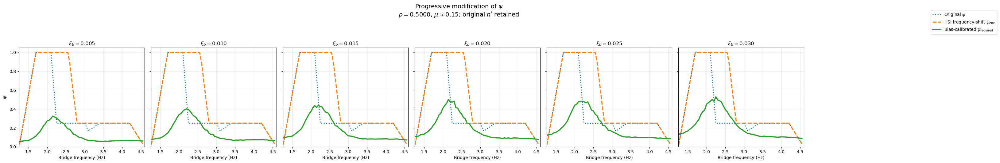

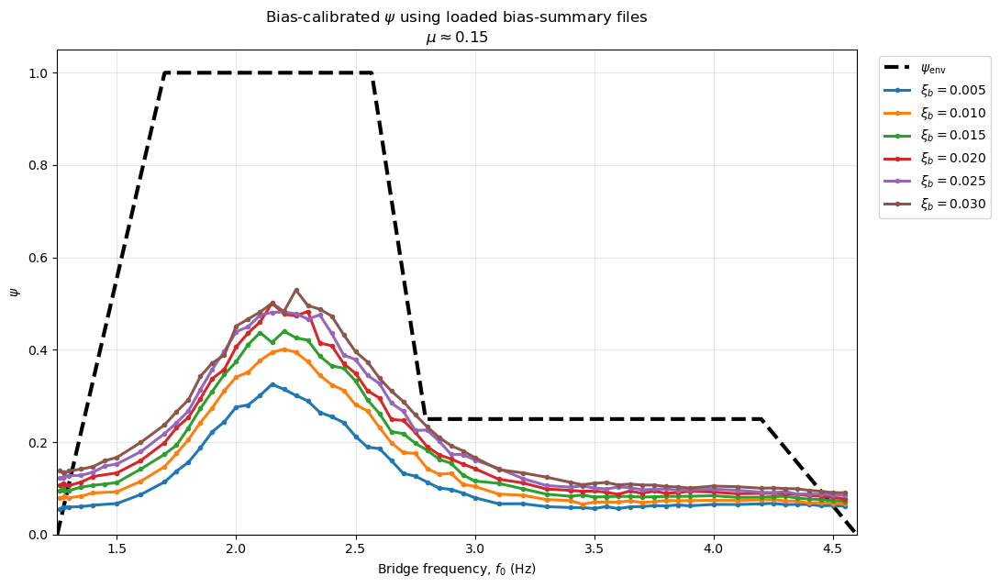

In [18]:
# ============================================================
# CALIBRATE PSI USING THE BIAS FILES ALREADY LOADED
# BY THE PREVIOUS CODE
#
# Uses:
#     corrected_df
#
# corrected_df was built directly from:
#
# density*_damping*_0S*_bias_summary.pkl
# density*_damping*_0S125_bias_summary.pkl
# density*_damping*_0S456_bias_summary.pkl
#
# and already stitched across the frequency regions.
#
# Calibration target:
#
# mean bias of PEAK ABSOLUTE ACCELERATION = 1
#
# n' is kept unchanged.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

TARGET_DENSITY_PSI = 0.5000

TARGET_DAMPINGS = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

MEASURE = "Peak absolute acceleration"

PLOT_FMIN = 1.25
PLOT_FMAX = 4.60

EPS = 1e-12


density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    
}


TARGET_MASS_RATIO_PSI = density_to_mass_ratio.get(
    round(float(TARGET_DENSITY_PSI), 4),
    np.nan,
)


# ============================================================
# CHECK REQUIRED OBJECTS
#
# corrected_df comes from the file-loading code you gave.
#
# psi_original() and psi_envelope() come from the earlier
# psi-envelope construction.
# ============================================================

if "corrected_df" not in globals():

    raise NameError(
        "corrected_df does not exist.\n"
        "Run the bias-file loading/stitching code first."
    )


if "psi_original" not in globals():

    raise NameError(
        "psi_original() does not exist.\n"
        "Run the psi-envelope construction code first."
    )


if "psi_envelope" not in globals():

    raise NameError(
        "psi_envelope() does not exist.\n"
        "Run the psi-envelope construction code first."
    )


# ============================================================
# START FROM THE FILE-LOADED corrected_df
#
# IMPORTANT:
# We use code_bias_mean = original code bias.
#
# We do NOT use:
#     corrected_bias_mean
#     final_modification_factor
#
# because here we want to:
#
# original code
# -> modify psi
# -> calculate residual bias
# -> absorb residual bias into psi
# ============================================================

psi_df = corrected_df.copy()


# ============================================================
# NUMERIC CLEANING
# ============================================================

for col in [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "code_bias_mean",
]:

    if col not in psi_df.columns:

        raise KeyError(
            f"Required column '{col}' "
            "is missing from corrected_df."
        )

    psi_df[col] = pd.to_numeric(
        psi_df[col],
        errors="coerce",
    )


if "measure" not in psi_df.columns:

    raise KeyError(
        "corrected_df has no 'measure' column."
    )


psi_df["measure"] = (
    psi_df["measure"]
    .astype(str)
    .str.strip()
)


# ============================================================
# FILTER:
#
# - selected density
# - all requested damping ratios
# - Peak absolute acceleration
# - full 1.25–4.60 Hz range
# ============================================================

damping_mask = np.zeros(
    len(psi_df),
    dtype=bool,
)


for damp in TARGET_DAMPINGS:

    damping_mask |= np.isclose(
        psi_df["target_beamdamp"],
        damp,
    )


psi_df = psi_df[

    np.isclose(
        psi_df["target_density"],
        TARGET_DENSITY_PSI,
    )

    & damping_mask

    & (
        psi_df["measure"]
        == MEASURE
    )

    & (
        psi_df["bridge_frequency"]
        >= PLOT_FMIN
    )

    & (
        psi_df["bridge_frequency"]
        <= PLOT_FMAX
    )

].copy()


psi_df = psi_df.dropna(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "code_bias_mean",
    ]
)


if psi_df.empty:

    raise ValueError(
        "No rows found after filtering.\n"
        "Check density, damping ratios, "
        "measure and frequency range."
    )


# ============================================================
# REMOVE ANY TRUE DUPLICATES
# ============================================================

psi_df = psi_df.drop_duplicates(

    subset=[
        "target_beamdamp",
        "target_density",
        "bridge_frequency",
        "measure",
    ],

    keep="first",
).copy()


psi_df = psi_df.sort_values(
    [
        "target_beamdamp",
        "bridge_frequency",
    ]
)


# ============================================================
# REPORT ACTUAL COVERAGE FROM THE LOADED FILES
# ============================================================

print("\n" + "=" * 90)

print(
    "BIAS DATA USED FOR PSI CALIBRATION"
)

print("=" * 90)


print(
    f"Density     = {TARGET_DENSITY_PSI:.4f}"
)

print(
    f"Mass ratio  ≈ {TARGET_MASS_RATIO_PSI:.2f}"
)

print(
    f"Measure     = {MEASURE}"
)


print("\nFrequency coverage by damping:")

print(

    psi_df

    .groupby(
        "target_beamdamp"
    )["bridge_frequency"]

    .agg(
        ["min", "max", "count"]
    )

    .to_string()
)


# ============================================================
# ORIGINAL PSI
# ============================================================

frequency = (
    psi_df[
        "bridge_frequency"
    ]
    .to_numpy(dtype=float)
)


psi_df[
    "psi_original"
] = psi_original(
    frequency
)


# ============================================================
# FIRST MODIFICATION:
#
# FREQUENCY-SHIFT / HSI UPPER ENVELOPE
# ============================================================

psi_df[
    "psi_envelope"
] = psi_envelope(
    frequency
)


# ============================================================
# ORIGINAL MEAN BIAS
#
# B0 =
#
# reference mean peak absolute acceleration
# -----------------------------------------
# original code peak absolute acceleration
#
# Already stored as:
#
#     code_bias_mean
# ============================================================

psi_df[
    "bias_original_mean"
] = psi_df[
    "code_bias_mean"
]


# ============================================================
# RESIDUAL BIAS AFTER MODIFYING ONLY PSI
#
# Original model:
#
# R0 proportional to n' * psi_original
#
# Modified:
#
# R1 proportional to n' * psi_envelope
#
# Therefore:
#
# B1 =
#
# B0 * psi_original / psi_envelope
# ============================================================

psi_df[
    "bias_after_psi_mean"
] = (

    psi_df[
        "bias_original_mean"
    ]

    *

    psi_df[
        "psi_original"
    ].clip(
        lower=EPS
    )

    /

    psi_df[
        "psi_envelope"
    ].clip(
        lower=EPS
    )
)


# ============================================================
# SECOND MODIFICATION:
#
# ABSORB REMAINING BIAS INTO PSI
#
# psi_required =
#
# psi_envelope * bias_after_psi_mean
#
# This keeps ORIGINAL n' unchanged and makes:
#
# mean peak-absolute-acceleration bias = 1
# ============================================================

psi_df[
    "psi_required"
] = (

    psi_df[
        "psi_envelope"
    ]

    *

    psi_df[
        "bias_after_psi_mean"
    ]
)


# ============================================================
# DIRECT EQUIVALENT CALCULATION
#
# Algebraically:
#
# psi_required
#
# = psi_env *
#   (B0 * psi_original / psi_env)
#
# = B0 * psi_original
#
# This is useful as a numerical check.
# ============================================================

psi_df[
    "psi_required_direct"
] = (

    psi_df[
        "bias_original_mean"
    ]

    *

    psi_df[
        "psi_original"
    ]
)


# ============================================================
# CHECK DIFFERENCE BETWEEN BOTH METHODS
# ============================================================

psi_difference = (

    psi_df[
        "psi_required"
    ]

    -

    psi_df[
        "psi_required_direct"
    ]
)


print(
    "\nMaximum difference between "
    "two equivalent psi calculations ="
)

print(
    np.nanmax(
        np.abs(
            psi_difference
        )
    )
)


# ============================================================
# PSI CORRECTION FACTOR
#
# Relative to the HSI frequency-shift envelope:
#
# Cpsi =
#
# psi_required / psi_envelope
#
# This equals residual bias after psi correction.
# ============================================================

psi_df[
    "psi_correction_factor"
] = (

    psi_df[
        "psi_required"
    ]

    /

    psi_df[
        "psi_envelope"
    ].clip(
        lower=EPS
    )
)


# ============================================================
# FINAL BIAS CHECK
#
# Should be 1 where psi is non-zero and the ratio
# is well-defined.
# ============================================================

psi_df[
    "final_bias_check"
] = (

    psi_df[
        "bias_after_psi_mean"
    ]

    /

    psi_df[
        "psi_correction_factor"
    ].clip(
        lower=EPS
    )
)


# ============================================================
# PRINT TABLE
# ============================================================

table_cols = [
    "source_file",
    "target_beamdamp",
    "bridge_frequency",

    "bias_original_mean",

    "psi_original",
    "psi_envelope",

    "bias_after_psi_mean",

    "psi_correction_factor",
    "psi_required",

    "final_bias_check",
]


existing_table_cols = [
    col
    for col in table_cols
    if col in psi_df.columns
]


print("\n" + "=" * 120)

print(
    "PROGRESSIVE PSI CALIBRATION"
)

print("=" * 120)


print(

    psi_df[
        existing_table_cols
    ]

    .head(100)

    .to_string(
        index=False
    )
)


# ============================================================
# COMMON Y AXIS ACROSS ALL DAMPING PANELS
# ============================================================

all_y = np.concatenate(
    [
        psi_df[
            "psi_original"
        ].dropna().to_numpy(),

        psi_df[
            "psi_envelope"
        ].dropna().to_numpy(),

        psi_df[
            "psi_required"
        ].dropna().to_numpy(),
    ]
)


YMIN_PSI = 0.0

YMAX_PSI = max(
    1.05,
    1.05 * np.nanmax(all_y),
)


# ============================================================
# FIGURE 1
#
# ONE PANEL PER DAMPING
#
# Three curves:
#
# 1. Original psi
# 2. HSI frequency-shift envelope
# 3. Bias-calibrated required psi
# ============================================================

n_damp = len(
    TARGET_DAMPINGS
)


fig, axes = plt.subplots(

    nrows=1,

    ncols=n_damp,

    figsize=(
        5.0 * n_damp,
        5.4
    ),

    sharex=True,

    sharey=True,
)


if n_damp == 1:

    axes = [axes]


for ax, damp in zip(
    axes,
    TARGET_DAMPINGS
):

    sub = psi_df[

        np.isclose(
            psi_df[
                "target_beamdamp"
            ],
            damp
        )

    ].copy()


    sub = sub.sort_values(
        "bridge_frequency"
    )


    if sub.empty:

        ax.axis("off")

        continue


    # --------------------------------------------------------
    # Original psi
    # --------------------------------------------------------

    ax.plot(

        sub[
            "bridge_frequency"
        ],

        sub[
            "psi_original"
        ],

        linestyle=":",

        linewidth=2.2,

        label=r"Original $\psi$",
    )


    # --------------------------------------------------------
    # HSI frequency-shift envelope
    # --------------------------------------------------------

    ax.plot(

        sub[
            "bridge_frequency"
        ],

        sub[
            "psi_envelope"
        ],

        linestyle="--",

        linewidth=2.5,

        label=(
            r"HSI frequency-shift "
            r"$\psi_{\rm env}$"
        ),
    )


    # --------------------------------------------------------
    # Fully bias-calibrated psi
    # --------------------------------------------------------

    ax.plot(

        sub[
            "bridge_frequency"
        ],

        sub[
            "psi_required"
        ],

        linestyle="-",

        linewidth=2.7,

        label=(
            r"Bias-calibrated "
            r"$\psi_{\rm required}$"
        ),
    )


    ax.set_title(
        rf"$\xi_b={damp:.3f}$"
    )


    ax.set_xlabel(
        "Bridge frequency (Hz)"
    )


    ax.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )


    ax.set_ylim(
        YMIN_PSI,
        YMAX_PSI
    )


    ax.grid(
        True,
        alpha=0.30
    )


axes[0].set_ylabel(
    r"$\psi$"
)


handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)


fig.legend(

    handles,
    labels,

    bbox_to_anchor=(
        1.01,
        0.95
    ),

    loc="upper left",
)


fig.suptitle(

    r"Progressive modification of $\psi$"
    "\n"

    + fr"$\rho={TARGET_DENSITY_PSI:.4f}$, "
    + fr"$\mu\approx{TARGET_MASS_RATIO_PSI:.2f}$; "
    + r"original $n'$ retained",

    fontsize=14,
)


fig.tight_layout(
    rect=[
        0,
        0,
        0.88,
        0.90,
    ]
)


plt.show()


# ============================================================
# FIGURE 2
#
# FINAL REQUIRED PSI FOR ALL DAMPINGS ON ONE GRAPH
# ============================================================

plt.figure(
    figsize=(11, 6.5)
)


# Reference HSI envelope
f_ref = np.linspace(
    PLOT_FMIN,
    PLOT_FMAX,
    1500,
)


plt.plot(

    f_ref,

    psi_envelope(
        f_ref
    ),

    color="black",

    linestyle="--",

    linewidth=3,

    label=r"$\psi_{\rm env}$",
)


for damp in TARGET_DAMPINGS:

    sub = psi_df[

        np.isclose(
            psi_df[
                "target_beamdamp"
            ],
            damp
        )

    ].copy()


    sub = sub.sort_values(
        "bridge_frequency"
    )


    if sub.empty:

        continue


    plt.plot(

        sub[
            "bridge_frequency"
        ],

        sub[
            "psi_required"
        ],

        linewidth=2.2,

        marker="o",

        markersize=3,

        label=(
            rf"$\xi_b={damp:.3f}$"
        ),
    )


plt.xlabel(
    r"Bridge frequency, $f_0$ (Hz)"
)

plt.ylabel(
    r"$\psi$"
)


plt.title(

    r"Bias-calibrated $\psi$ using loaded bias-summary files"
    "\n"

    
    + fr"$\mu\approx{TARGET_MASS_RATIO_PSI:.2f}$"
)


plt.xlim(
    PLOT_FMIN,
    PLOT_FMAX
)


plt.ylim(
    YMIN_PSI,
    YMAX_PSI
)


plt.grid(
    True,
    alpha=0.30
)


plt.legend(
    bbox_to_anchor=(
        1.02,
        1
    ),
    loc="upper left"
)


plt.tight_layout()

plt.show()


Coverage used for all-density psi plot:
 target_density  target_beamdamp  min  max  count
         0.0333            0.005 1.26 4.55     59
         0.0333            0.010 1.26 4.55     59
         0.0333            0.015 1.26 4.55     60
         0.0333            0.020 1.26 4.55     59
         0.0333            0.025 1.26 4.55     60
         0.0333            0.030 1.26 4.55     60
         0.1667            0.005 1.26 4.55     59
         0.1667            0.010 1.26 4.55     59
         0.1667            0.015 1.26 4.55     60
         0.1667            0.020 1.26 4.55     59
         0.1667            0.025 1.26 4.55     60
         0.1667            0.030 1.26 4.55     60
         0.3333            0.005 1.26 4.55     59
         0.3333            0.010 1.26 4.55     59
         0.3333            0.015 1.26 4.55     60
         0.3333            0.020 1.26 4.55     59
         0.3333            0.025 1.26 4.55     60
         0.3333            0.030 1.26 4.55     60
         

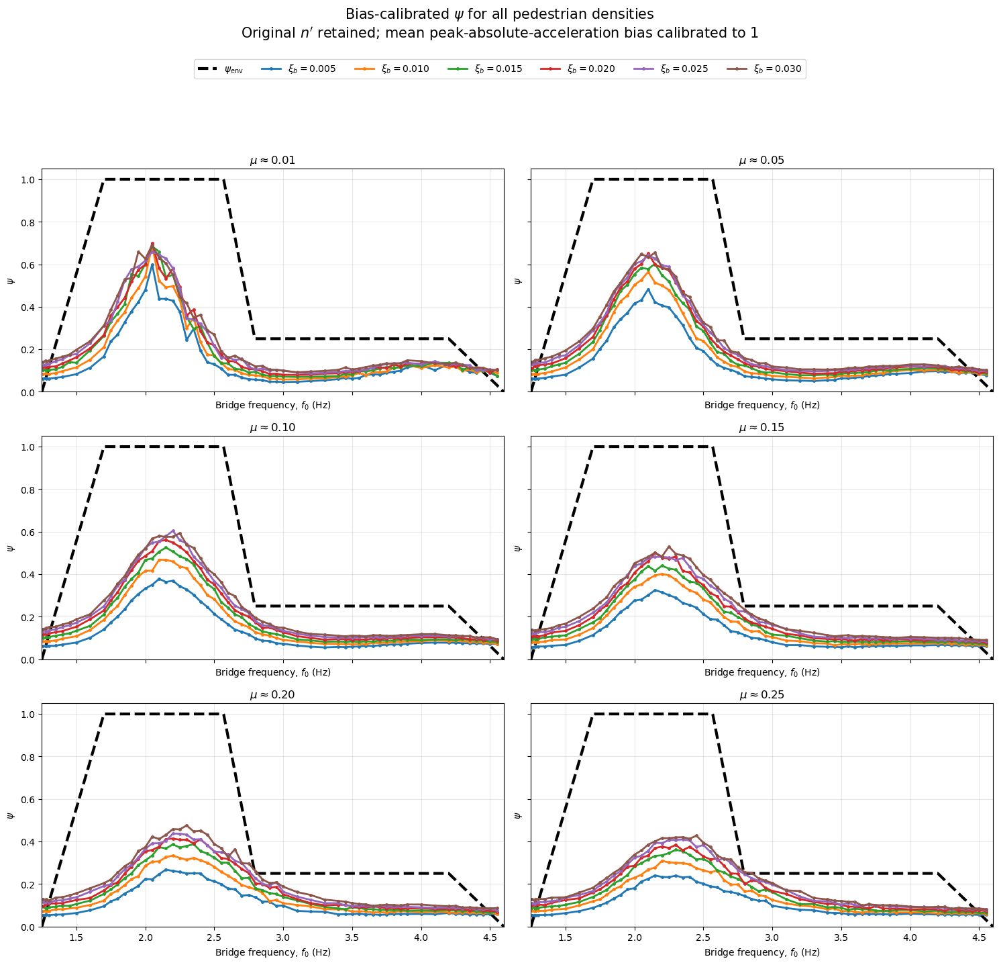

In [19]:
# ============================================================
# BIAS-CALIBRATED PSI FOR ALL DENSITIES / MASS RATIOS
#
# ONE LARGE FIGURE
#
# Each panel:
#   dashed black = HSI frequency-shift psi envelope
#   coloured lines = final bias-calibrated psi
#                    for each structural damping ratio
#
# Rows/panels = density / approximate mass ratio
#
# Uses corrected_df already loaded from:
#   0S125 + 0S + 0S456 bias-summary files
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

DENSITIES_TO_PLOT = [
    0.0333,
    0.1667,
    0.3333,
    0.5000,
    0.6667,
    0.8333,
   
]

TARGET_DAMPINGS = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

MEASURE = "Peak absolute acceleration"

PLOT_FMIN = 1.25
PLOT_FMAX = 4.60

EPS = 1e-12


density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
    
}


# ============================================================
# CHECK REQUIRED OBJECTS
# ============================================================

if "corrected_df" not in globals():
    raise NameError(
        "corrected_df does not exist. "
        "Run the bias-file loading/stitching code first."
    )

if "psi_original" not in globals():
    raise NameError(
        "psi_original() does not exist."
    )

if "psi_envelope" not in globals():
    raise NameError(
        "psi_envelope() does not exist."
    )


# ============================================================
# PREPARE DATA
# ============================================================

all_psi_df = corrected_df.copy()


for col in [
    "bridge_frequency",
    "target_density",
    "target_beamdamp",
    "code_bias_mean",
]:

    all_psi_df[col] = pd.to_numeric(
        all_psi_df[col],
        errors="coerce"
    )


all_psi_df["measure"] = (
    all_psi_df["measure"]
    .astype(str)
    .str.strip()
)


# ============================================================
# FILTER ALL REQUESTED DENSITIES + DAMPINGS
# ============================================================

density_mask = np.zeros(
    len(all_psi_df),
    dtype=bool
)

for rho in DENSITIES_TO_PLOT:

    density_mask |= np.isclose(
        all_psi_df["target_density"],
        rho
    )


damping_mask = np.zeros(
    len(all_psi_df),
    dtype=bool
)

for damp in TARGET_DAMPINGS:

    damping_mask |= np.isclose(
        all_psi_df["target_beamdamp"],
        damp
    )


all_psi_df = all_psi_df[

    density_mask

    & damping_mask

    & (
        all_psi_df["measure"]
        == MEASURE
    )

    & (
        all_psi_df["bridge_frequency"]
        >= PLOT_FMIN
    )

    & (
        all_psi_df["bridge_frequency"]
        <= PLOT_FMAX
    )

].copy()


all_psi_df = all_psi_df.dropna(
    subset=[
        "bridge_frequency",
        "target_density",
        "target_beamdamp",
        "code_bias_mean",
    ]
)


# Remove true duplicates only
all_psi_df = all_psi_df.drop_duplicates(

    subset=[
        "target_density",
        "target_beamdamp",
        "bridge_frequency",
        "measure",
    ],

    keep="first"
).copy()


# ============================================================
# CALCULATE PSI VALUES
# ============================================================

freq = (
    all_psi_df["bridge_frequency"]
    .to_numpy(dtype=float)
)


# Original code psi
all_psi_df["psi_original"] = (
    psi_original(freq)
)


# First modification:
# HSI frequency-shift upper envelope
all_psi_df["psi_env"] = (
    psi_envelope(freq)
)


# ============================================================
# RESIDUAL BIAS AFTER PSI ENVELOPE
#
# B_after =
#
# B_original * psi_original / psi_env
#
# This is useful for interpretation.
# ============================================================

all_psi_df["bias_after_psi"] = (

    all_psi_df["code_bias_mean"]

    * all_psi_df["psi_original"].clip(lower=EPS)

    / all_psi_df["psi_env"].clip(lower=EPS)
)


# ============================================================
# FINAL REQUIRED PSI
#
# psi_required =
#
# psi_env * B_after
#
# Algebraically equivalent to:
#
# psi_required =
#
# psi_original * code_bias_mean
#
# We use the direct expression because it behaves better
# numerically near psi_env = 0.
# ============================================================

all_psi_df["psi_required"] = (

    all_psi_df["psi_original"]

    * all_psi_df["code_bias_mean"]
)


# ============================================================
# PRINT COVERAGE CHECK
# ============================================================

print("\nCoverage used for all-density psi plot:")

print(
    all_psi_df
    .groupby(
        [
            "target_density",
            "target_beamdamp",
        ]
    )["bridge_frequency"]
    .agg(
        ["min", "max", "count"]
    )
    .reset_index()
    .to_string(index=False)
)


# ============================================================
# COMMON Y-AXIS ACROSS ALL DENSITIES
#
# Important so variation with rho/mu can be compared directly.
# ============================================================

all_y = np.concatenate(
    [
        all_psi_df[
            "psi_env"
        ].dropna().to_numpy(),

        all_psi_df[
            "psi_required"
        ].dropna().to_numpy(),
    ]
)


YMIN_PSI = 0.0

YMAX_PSI = max(
    1.05,
    1.05 * np.nanmax(all_y)
)


print(
    "\nCommon y-axis:",
    YMIN_PSI,
    "to",
    YMAX_PSI
)


# ============================================================
# FIGURE
#
# 7 DENSITIES -> 4 ROWS × 2 COLUMNS
# ============================================================

n_density = len(
    DENSITIES_TO_PLOT
)

ncols = 2

nrows = int(
    np.ceil(
        n_density / ncols
    )
)


fig, axes = plt.subplots(

    nrows=nrows,

    ncols=ncols,

    figsize=(
        15,
        4.8 * nrows
    ),

    sharex=True,

    sharey=True
)


axes = np.asarray(
    axes
).reshape(-1)


# ============================================================
# COMMON PSI ENVELOPE REFERENCE
# ============================================================

f_ref = np.linspace(
    PLOT_FMIN,
    PLOT_FMAX,
    1500
)

psi_env_ref = psi_envelope(
    f_ref
)


# ============================================================
# LOOP OVER ALL DENSITIES
# ============================================================

for ax, rho in zip(
    axes,
    DENSITIES_TO_PLOT
):

    mu = density_to_mass_ratio.get(
        round(float(rho), 4),
        np.nan
    )


    # --------------------------------------------------------
    # PSI ENVELOPE
    # --------------------------------------------------------

    ax.plot(

        f_ref,

        psi_env_ref,

        color="black",

        linestyle="--",

        linewidth=3.0,

        label=r"$\psi_{\rm env}$"
    )


    # --------------------------------------------------------
    # FINAL PSI FOR EACH DAMPING
    # --------------------------------------------------------

    for damp in TARGET_DAMPINGS:

        sub = all_psi_df[

            np.isclose(
                all_psi_df[
                    "target_density"
                ],
                rho
            )

            &

            np.isclose(
                all_psi_df[
                    "target_beamdamp"
                ],
                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            print(
                f"No data: "
                f"rho={rho:.4f}, "
                f"xi_b={damp:.3f}"
            )

            continue


        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "psi_required"
            ],

            marker="o",

            markersize=2.5,

            linewidth=2.0,

            label=(
                rf"$\xi_b={damp:.3f}$"
            )
        )


    # --------------------------------------------------------
    # PANEL FORMATTING
    # --------------------------------------------------------

    ax.set_title(

        
        rf"$\mu\approx{mu:.2f}$",

        fontsize=12
    )


    ax.set_xlim(
        PLOT_FMIN,
        PLOT_FMAX
    )


    ax.set_ylim(
        YMIN_PSI,
        YMAX_PSI
    )


    ax.grid(
        True,
        alpha=0.30
    )


    ax.set_xlabel(
        r"Bridge frequency, $f_0$ (Hz)"
    )


    ax.set_ylabel(
        r"$\psi$"
    )


# ============================================================
# REMOVE UNUSED PANEL
# ============================================================

for ax in axes[
    len(DENSITIES_TO_PLOT):
]:

    ax.axis(
        "off"
    )


# ============================================================
# COMMON LEGEND
# ============================================================

handles, labels = (
    axes[0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,

    loc="upper center",

    # Move legend clearly BELOW the title
    bbox_to_anchor=(
        0.5,
        0.945
    ),

    ncol=7,

    frameon=True
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(

    r"Bias-calibrated $\psi$ for all pedestrian densities"
    "\n"
    r"Original $n'$ retained; "
    r"mean peak-absolute-acceleration bias calibrated to 1",

    fontsize=15,

    # Keep title at top
    y=0.995
)


# ============================================================
# LEAVE SPACE AT TOP FOR BOTH TITLE AND LEGEND
# ============================================================

fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.90
    ]
)

plt.show()


Maximum difference between new calculation and existing bias_after_psi:
0.0

Mass ratios plotted:
[np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25)]

Damping ratios plotted:
[0.005, 0.01, 0.015, 0.02, 0.025, 0.03]

Common bias y-axis:
0.07943498408221979 to 3.0


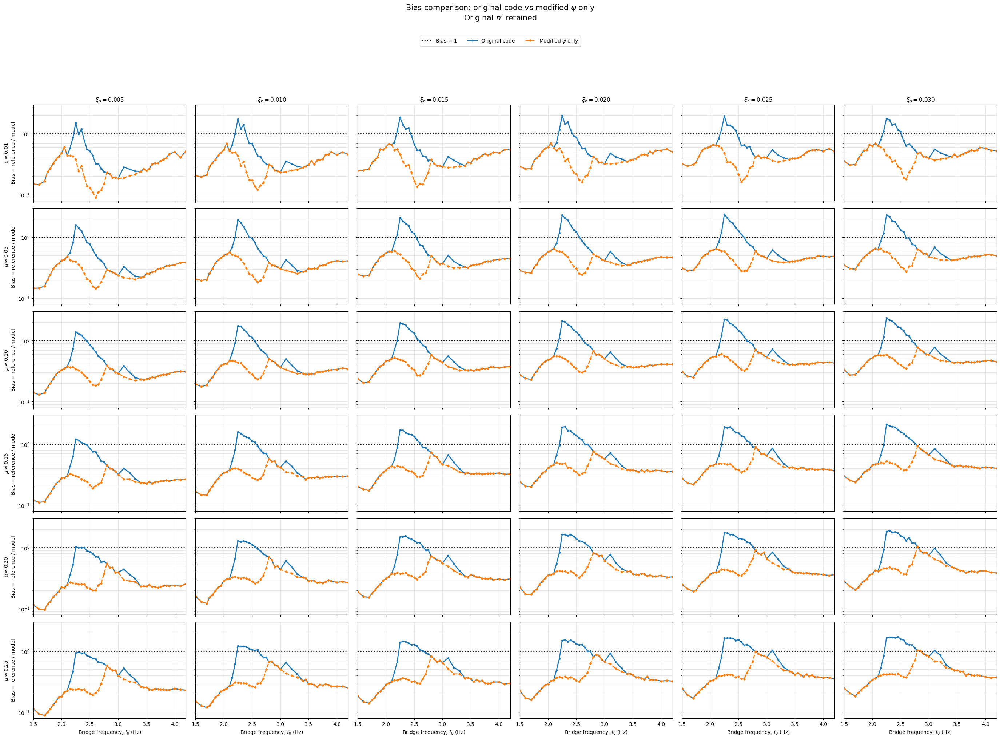

In [24]:
# ============================================================
# BIAS COMPARISON
#
# ORIGINAL CODE
# vs
# CODE WITH MODIFIED PSI ONLY
#
# IMPORTANT:
#
# n' is unchanged in both cases.
#
# Original bias:
#
#       B_original = reference / original code
#
# Modified-psi-only bias:
#
#       B_modpsi =
#
#       B_original * psi_original / psi_env
#
#
# ROWS    = mass ratio
# COLUMNS = structural damping ratio
#
# Uses all_psi_df created in the previous code.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

PSI_MIN_FOR_BIAS = 0.02

USE_LOG_SCALE = True

# Let code calculate common y-axis automatically

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

YMIN_BIAS = 0.0
YMAX_BIAS = 3.0

SAVE_BIAS_PLOT = False


# ============================================================
# START FROM all_psi_df ALREADY CREATED ABOVE
# ============================================================

bias_df = all_psi_df.copy()


# ============================================================
# MASS-RATIO COLUMN
# ============================================================

bias_df["density_key"] = (
    bias_df["target_density"]
    .round(4)
)

bias_df["mass_ratio"] = (
    bias_df["density_key"]
    .map(
        {
            round(k, 4): v
            for k, v
            in density_to_mass_ratio.items()
        }
    )
)


bias_df = bias_df.dropna(
    subset=[
        "mass_ratio",
        "bridge_frequency",
        "target_beamdamp",
        "code_bias_mean",
        "psi_original",
        "psi_env",
    ]
).copy()


# ============================================================
# CALCULATE MODIFIED-PSI-ONLY BIAS
#
# Do this again explicitly rather than relying on the
# EPS-clipped version.
#
# We only calculate the ratio where both psi values are
# meaningfully non-zero.
#
# This avoids artificial values near 1.25 and 4.60 Hz.
# ============================================================

valid_psi = (

    np.isfinite(
        bias_df["psi_original"]
    )

    &

    np.isfinite(
        bias_df["psi_env"]
    )

    &

    (
        bias_df["psi_original"]
        > PSI_MIN_FOR_BIAS
    )

    &

    (
        bias_df["psi_env"]
        > PSI_MIN_FOR_BIAS
    )
)


bias_df[
    "modified_psi_bias_mean"
] = np.nan


bias_df.loc[
    valid_psi,
    "modified_psi_bias_mean"
] = (

    bias_df.loc[
        valid_psi,
        "code_bias_mean"
    ]

    *

    bias_df.loc[
        valid_psi,
        "psi_original"
    ]

    /

    bias_df.loc[
        valid_psi,
        "psi_env"
    ]
)


# ============================================================
# CHECK AGAINST PREVIOUS bias_after_psi COLUMN
#
# They should agree where psi is valid.
# ============================================================

if "bias_after_psi" in bias_df.columns:

    check_difference = (

        bias_df.loc[
            valid_psi,
            "modified_psi_bias_mean"
        ]

        -

        bias_df.loc[
            valid_psi,
            "bias_after_psi"
        ]
    )


    print(
        "\nMaximum difference between "
        "new calculation and existing bias_after_psi:"
    )

    print(
        np.nanmax(
            np.abs(
                check_difference
            )
        )
    )


# ============================================================
# AVAILABLE MASS RATIOS AND DAMPINGS
# ============================================================

mass_ratios_available = [

    mu

    for mu in sorted(
        bias_df[
            "mass_ratio"
        ].dropna().unique()
    )

]


dampings_available = [

    damp

    for damp in TARGET_DAMPINGS

    if np.any(

        np.isclose(
            bias_df[
                "target_beamdamp"
            ],
            damp
        )
    )
]


print(
    "\nMass ratios plotted:"
)

print(
    mass_ratios_available
)


print(
    "\nDamping ratios plotted:"
)

print(
    dampings_available
)


# ============================================================
# COMMON Y-AXIS ACROSS ALL PANELS
#
# Use only frequencies where modified psi bias is defined
# so extreme endpoint artefacts do not determine the scale.
# ============================================================

valid_original_values = (

    bias_df.loc[
        valid_psi,
        "code_bias_mean"
    ]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna()

    .to_numpy(dtype=float)
)


valid_modified_values = (

    bias_df[
        "modified_psi_bias_mean"
    ]

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna()

    .to_numpy(dtype=float)
)


all_bias_values = np.concatenate(
    [
        valid_original_values,
        valid_modified_values,
    ]
)


if len(all_bias_values) == 0:

    raise ValueError(
        "No valid bias values available for plotting."
    )


if USE_LOG_SCALE:

    positive = (
        all_bias_values[
            all_bias_values > 0
        ]
    )

    YMIN_PLOT = max(
        0.05,
        0.90 * np.nanmin(
            positive
        )
    )

    if YMAX_BIAS is None:

        YMAX_PLOT = max(
            1.1,
            1.05 * np.nanmax(
                positive
            )
        )

    else:

        YMAX_PLOT = YMAX_BIAS


else:

    YMIN_PLOT = YMIN_BIAS

    if YMAX_BIAS is None:

        YMAX_PLOT = max(
            1.1,
            1.05 * np.nanmax(
                all_bias_values
            )
        )

    else:

        YMAX_PLOT = YMAX_BIAS


print(
    "\nCommon bias y-axis:"
)

print(
    YMIN_PLOT,
    "to",
    YMAX_PLOT
)


# ============================================================
# CREATE FIGURE
#
# ROW    = MASS RATIO
# COLUMN = DAMPING
#
# Each panel has ONLY:
#
# - Original code bias
# - Modified-psi-only bias
# - Bias = 1 reference
# ============================================================

n_rows = len(
    mass_ratios_available
)

n_cols = len(
    dampings_available
)


fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(
        4.6 * n_cols,
        3.4 * n_rows
    ),

    sharex=True,

    sharey=True
)


# Make axes always 2D
if n_rows == 1 and n_cols == 1:

    axes = np.array(
        [[axes]]
    )

elif n_rows == 1:

    axes = np.array(
        [axes]
    )

elif n_cols == 1:

    axes = np.array(
        [[ax] for ax in axes]
    )


# ============================================================
# LOOP
# ============================================================

for i, mu in enumerate(
    mass_ratios_available
):

    for j, damp in enumerate(
        dampings_available
    ):

        ax = axes[
            i,
            j
        ]


        sub = bias_df[

            np.isclose(
                bias_df[
                    "mass_ratio"
                ],
                mu
            )

            &

            np.isclose(
                bias_df[
                    "target_beamdamp"
                ],
                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            ax.axis(
                "off"
            )

            continue


        # ====================================================
        # BIAS = 1
        # ====================================================

        ax.axhline(

            1.0,

            color="black",

            linestyle=":",

            linewidth=2.0,

            label=(
                "Bias = 1"
                if i == 0 and j == 0
                else None
            )
        )


        # ====================================================
        # 1. ORIGINAL CODE BIAS
        #
        # B_original = reference / original code
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "code_bias_mean"
            ],

            marker="o",

            markersize=3.0,

            linewidth=2.0,

            linestyle="-",

            label=(
                "Original code"
                if i == 0 and j == 0
                else None
            )
        )


        # ====================================================
        # 2. MODIFIED PSI ONLY
        #
        # n' remains original.
        #
        # B_modpsi =
        #
        # B_original * psi_original / psi_env
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "modified_psi_bias_mean"
            ],

            marker="D",

            markersize=3.0,

            linewidth=2.0,

            linestyle="--",

            label=(
                r"Modified $\psi$ only"
                if i == 0 and j == 0
                else None
            )
        )


        # ====================================================
        # COLUMN TITLE = DAMPING
        # ====================================================

        if i == 0:

            ax.set_title(

                rf"$\xi_b={damp:.3f}$",

                fontsize=11
            )


        # ====================================================
        # ROW LABEL = MASS RATIO
        # ====================================================

        if j == 0:

            ax.set_ylabel(

                rf"$\mu\approx{mu:.2f}$"
                "\n"
                r"Bias = reference / model",

                fontsize=10
            )


        # ====================================================
        # X LABEL
        # ====================================================

        if i == n_rows - 1:

            ax.set_xlabel(
                r"Bridge frequency, $f_0$ (Hz)"
            )


        # ====================================================
        # AXES
        # ====================================================

        ax.set_xlim(
            PLOT_FMIN,
            PLOT_FMAX
        )


        if USE_LOG_SCALE:

            ax.set_yscale(
                "log"
            )


        ax.set_ylim(
            YMIN_PLOT,
            YMAX_PLOT
        )


        ax.grid(
            True,
            which="both",
            alpha=0.30
        )


# ============================================================
# COMMON LEGEND
# ============================================================

handles, labels = (

    axes[0, 0]
    .get_legend_handles_labels()

)


fig.legend(

    handles,

    labels,

    loc="upper center",

    bbox_to_anchor=(
        0.5,
        0.955
    ),

    ncol=3,

    frameon=True
)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(

    r"Bias comparison: original code vs modified $\psi$ only"
    "\n"
    r"Original $n'$ retained",

    fontsize=15,

    y=0.995
)


# ============================================================
# LAYOUT
# ============================================================

fig.tight_layout(

    rect=[
        0,
        0,
        1,
        0.91
    ]
)


# ============================================================
# OPTIONAL SAVE
# ============================================================

if SAVE_BIAS_PLOT:

    fig.savefig(

        "bias_original_vs_modified_psi_only_all_mass_ratios.png",

        dpi=300,

        bbox_inches="tight"
    )


plt.show()

Loaded: NMFR_2.pkl
Bands: ['1.25_to_4.60']
Saved densities: [0.0333, 0.1667, 0.3333, 0.5, 0.6667, 0.8333, 1.0]
Saved damping values: [0.005, 0.01, 0.015, 0.02, 0.025, 0.03]
Projection damping: 0.005


MASS-RATIO-SPECIFIC PSI CURVES
density = 0.0333  |  mu ≈ 0.01  |  N points = 135  |  f0 range = 1.250–4.600 Hz
density = 0.1667  |  mu ≈ 0.05  |  N points = 135  |  f0 range = 1.250–4.600 Hz
density = 0.3333  |  mu ≈ 0.10  |  N points = 135  |  f0 range = 1.250–4.600 Hz
density = 0.5000  |  mu ≈ 0.15  |  N points = 135  |  f0 range = 1.250–4.600 Hz
density = 0.6667  |  mu ≈ 0.20  |  N points = 135  |  f0 range = 1.250–4.600 Hz
density = 0.8333  |  mu ≈ 0.25  |  N points = 135  |  f0 range = 1.250–4.600 Hz


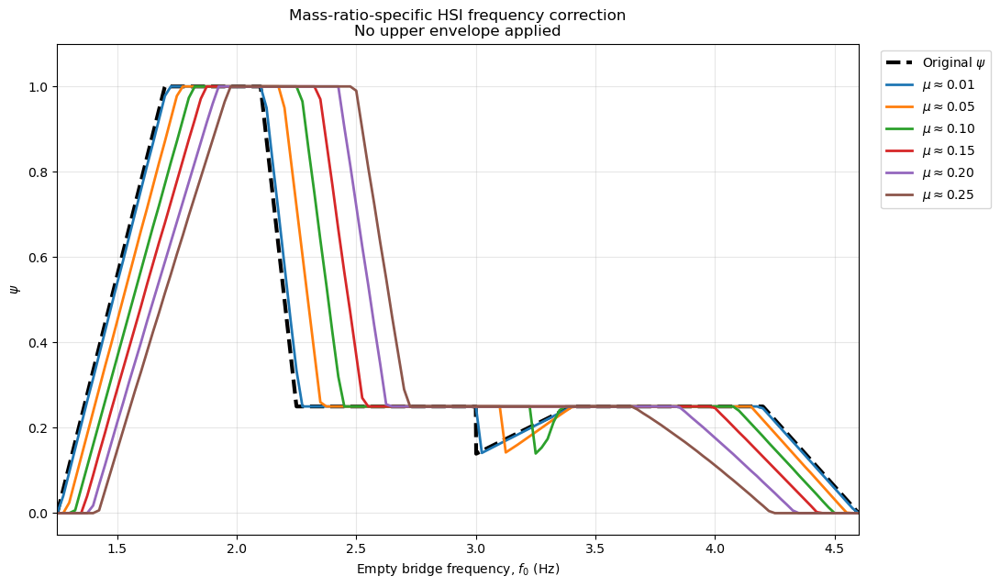



BIAS DATA AFTER MASS-RATIO-SPECIFIC PSI CORRECTION
 mass_ratio  target_beamdamp  min  max  count
       0.01            0.005  1.5  4.2     46
       0.01            0.010  1.5  4.2     46
       0.01            0.015  1.5  4.2     46
       0.01            0.020  1.5  4.2     46
       0.01            0.025  1.5  4.2     46
       0.01            0.030  1.5  4.2     46
       0.05            0.005  1.5  4.2     46
       0.05            0.010  1.5  4.2     46
       0.05            0.015  1.5  4.2     46
       0.05            0.020  1.5  4.2     46
       0.05            0.025  1.5  4.2     46
       0.05            0.030  1.5  4.2     46
       0.10            0.005  1.5  4.2     46
       0.10            0.010  1.5  4.2     46
       0.10            0.015  1.5  4.2     46
       0.10            0.020  1.5  4.2     46
       0.10            0.025  1.5  4.2     46
       0.10            0.030  1.5  4.2     46
       0.15            0.005  1.5  4.2     46
       0.15            0.01

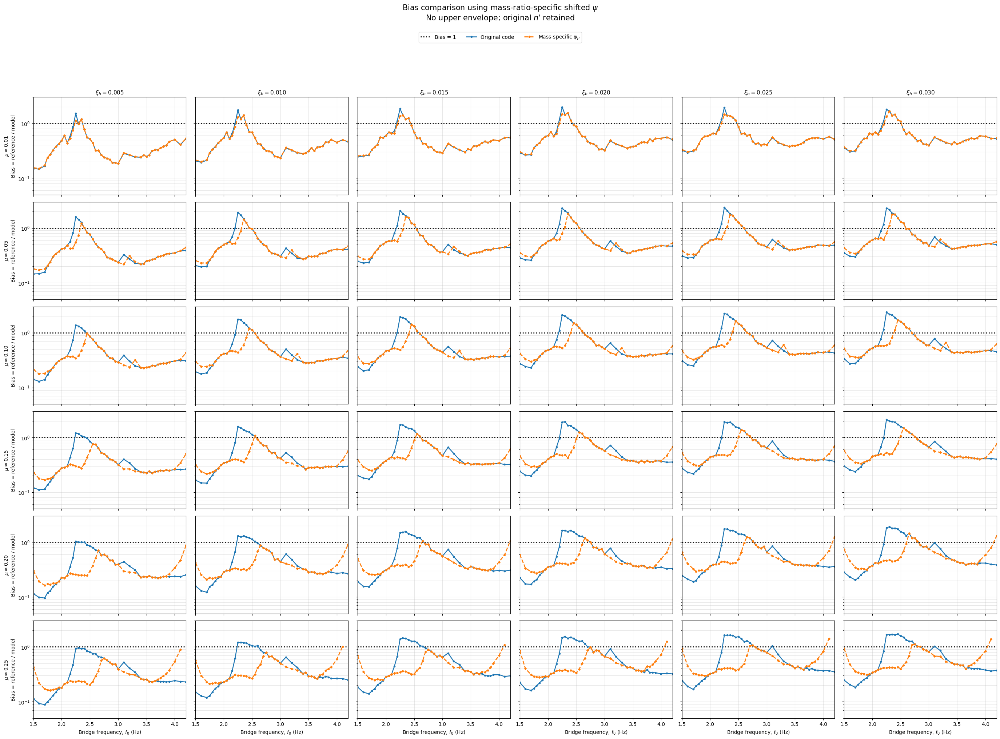

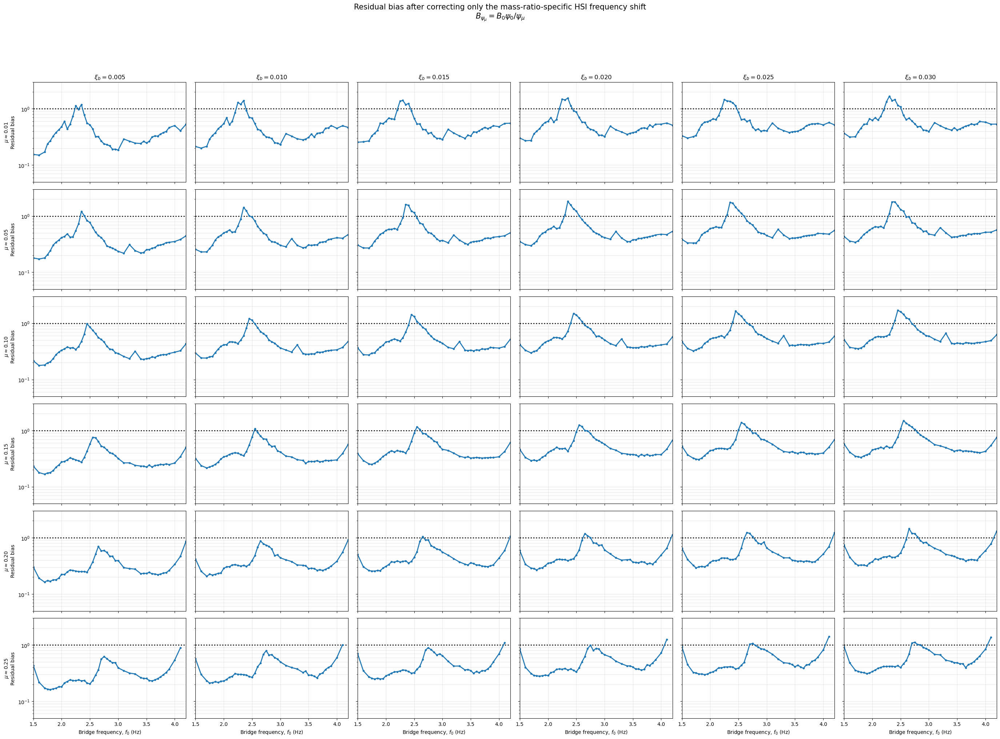



Created dataframe:
mass_specific_psi_bias_df
 bridge_frequency  target_beamdamp  target_density  mass_ratio                    measure  psi_original   psi_mu  psi_response_multiplier  code_bias_mean  bias_after_mu_psi_mean  code_bias_p5  code_bias_p95  bias_after_mu_psi_p5  bias_after_mu_psi_p95
             1.50            0.005          0.0333        0.01 Peak absolute acceleration      0.555556 0.537778                 0.968000        0.149618                0.154564      0.105423       0.196212              0.108908               0.202699
             1.60            0.005          0.0333        0.01 Peak absolute acceleration      0.777778 0.757778                 0.974286        0.145988                0.149841      0.088308       0.224537              0.090639               0.230463
             1.70            0.005          0.0333        0.01 Peak absolute acceleration      1.000000 0.977778                 0.977778        0.166666                0.170454      0.090256      

In [28]:
# ============================================================
# MASS-RATIO-SPECIFIC PSI CORRECTION
#
# NO UPPER ENVELOPE
#
# PURPOSE
# ============================================================
#
# For each mass ratio mu:
#
#   1. Get the coupled frequency mapping:
#
#          f0 -> f_eff(f0, mu)
#
#      from NMFR_2.pkl
#
#   2. Construct a mass-ratio-specific shifted psi:
#
#          psi_mu(f0)
#              = psi_original(f_eff(f0, mu))
#
#   3. Take the ORIGINAL CODE BIAS for the same mu:
#
#          B0 = reference / original_code
#
#   4. Change ONLY psi:
#
#          psi_original -> psi_mu
#
#      while keeping original n' unchanged.
#
#   5. Calculate:
#
#          B_mu
#              = B0 * psi_original / psi_mu
#
#
# IMPORTANT:
#
# NO upper envelope is used anywhere in this analysis.
#
# Therefore the residual bias is not contaminated by
# additional conservatism introduced by taking the envelope.
#
#
# ROWS    = mass ratio
# COLUMNS = structural damping ratio
#
# ============================================================


import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

PKL_FILE = "NMFR_2.pkl"


# Structural damping ratios in bias dataset
TARGET_DAMPINGS = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]


# Densities / approximate modal mass ratios
DENSITIES_TO_USE = [
    0.0333,
    0.1667,
    0.3333,
    0.5000,
    0.6667,
    0.8333,
]


density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,

    # Add later if required:
    # 1.0000: 0.30,
}


# Response measure used for calibration
MEASURE = "Peak absolute acceleration"


# Plot range
PLOT_FMIN = 1.50
PLOT_FMAX = 4.20


# Bias plot
USE_LOG_SCALE = True

YMIN_BIAS = 0.05
YMAX_BIAS = 3.0


# Avoid ratios where psi is essentially zero
PSI_MIN = 0.02


# ============================================================
# IMPORTANT:
#
# We use the same damping used previously to construct the
# shifted psi curves / envelope.
#
# This means:
#
#       psi = psi(f0, mu)
#
# rather than:
#
#       psi = psi(f0, mu, xi_b)
#
# ============================================================

PROJECT_DAMPING = 0.005


EPS = 1e-12


# ============================================================
# CHECK corrected_df
#
# corrected_df must already have been created by your
# existing 0S / 0S125 / 0S456 bias-file loading code.
# ============================================================

if "corrected_df" not in globals():

    raise NameError(
        "corrected_df does not exist.\n"
        "Run your bias-summary file loading/stitching code first."
    )


# ============================================================
# LOAD NMFR DATA
# ============================================================

with open(PKL_FILE, "rb") as f:

    saved = pickle.load(f)


results_all = saved["results_all"]

frequency_bands = saved["frequency_bands"]

densities_saved = saved["densities"]

damping_values_saved = saved["damping_values"]


bands_to_combine = list(
    frequency_bands.keys()
)


print("=" * 80)

print("Loaded:", PKL_FILE)

print(
    "Bands:",
    bands_to_combine
)

print(
    "Saved densities:",
    densities_saved
)

print(
    "Saved damping values:",
    damping_values_saved
)

print(
    "Projection damping:",
    PROJECT_DAMPING
)

print("=" * 80)


# ============================================================
# ORIGINAL PSI
#
# Same psi used in your previous analysis.
#
# Includes:
#
# minimum psi = 0.25
# from 2.25 to 3.00 Hz
# ============================================================

def psi_original(f):

    f = np.asarray(
        f,
        dtype=float
    )

    psi = np.zeros_like(
        f
    )


    # --------------------------------------------------------
    # 1.25–1.70 Hz
    # --------------------------------------------------------

    m = (
        (f >= 1.25)
        &
        (f < 1.70)
    )

    psi[m] = (

        (f[m] - 1.25)

        /

        (1.70 - 1.25)
    )


    # --------------------------------------------------------
    # 1.70–2.10 Hz
    # --------------------------------------------------------

    m = (
        (f >= 1.70)
        &
        (f <= 2.10)
    )

    psi[m] = 1.0


    # --------------------------------------------------------
    # 2.10–2.30 Hz
    # --------------------------------------------------------

    m = (
        (f > 2.10)
        &
        (f <= 2.30)
    )

    psi[m] = (

        (2.30 - f[m])

        /

        (2.30 - 2.10)
    )


    # --------------------------------------------------------
    # 2.30–2.50 Hz
    # --------------------------------------------------------

    m = (
        (f > 2.30)
        &
        (f < 2.50)
    )

    psi[m] = 0.0


    # --------------------------------------------------------
    # 2.50–3.40 Hz
    # --------------------------------------------------------

    m = (
        (f >= 2.50)
        &
        (f < 3.40)
    )

    psi[m] = (

        0.25

        *

        (f[m] - 2.50)

        /

        (3.40 - 2.50)
    )


    # --------------------------------------------------------
    # 3.40–4.20 Hz
    # --------------------------------------------------------

    m = (
        (f >= 3.40)
        &
        (f <= 4.20)
    )

    psi[m] = 0.25


    # --------------------------------------------------------
    # 4.20–4.60 Hz
    # --------------------------------------------------------

    m = (
        (f > 4.20)
        &
        (f <= 4.60)
    )

    psi[m] = (

        0.25

        *

        (4.60 - f[m])

        /

        (4.60 - 4.20)
    )


    # --------------------------------------------------------
    # Enforced minimum psi = 0.25
    # between 2.25 and 3.00 Hz
    # --------------------------------------------------------

    m = (
        (f >= 2.25)
        &
        (f <= 3.00)
    )

    psi[m] = np.maximum(
        psi[m],
        0.25
    )


    return psi


# ============================================================
# ROBUST FLOAT-KEY HELPER
# ============================================================

def nearest_float_key(
    mapping,
    target,
    tol=1e-6
):

    keys = list(
        mapping.keys()
    )


    if len(keys) == 0:

        return None


    values = np.asarray(

        [
            float(k)
            for k in keys
        ],

        dtype=float
    )


    idx = np.argmin(

        np.abs(

            values
            -
            float(target)
        )
    )


    if (

        abs(
            values[idx]
            -
            float(target)
        )

        <= tol

    ):

        return keys[idx]


    return None


# ============================================================
# COLLECT f0 -> f_eff
#
# FOR ONE DENSITY / MASS RATIO
#
# No envelope.
# ============================================================

def collect_f0_feff_for_density(

    results_all,

    bands_to_combine,

    beamdamp_value,

    density_value,

    key_tol=1e-5

):

    x_vals = []

    y_vals = []


    for band_name in bands_to_combine:


        if band_name not in results_all:

            continue


        # ----------------------------------------------------
        # Find requested damping
        # ----------------------------------------------------

        damp_key = nearest_float_key(

            results_all[
                band_name
            ],

            beamdamp_value,

            tol=key_tol
        )


        if damp_key is None:

            continue


        freq_dict = (

            results_all[
                band_name
            ][
                damp_key
            ]
        )


        # ----------------------------------------------------
        # Loop frequencies
        # ----------------------------------------------------

        for bf in sorted(
            freq_dict.keys()
        ):


            density_key = nearest_float_key(

                freq_dict[
                    bf
                ],

                density_value,

                tol=key_tol
            )


            if density_key is None:

                continue


            data = (

                freq_dict[
                    bf
                ][
                    density_key
                ]
            )


            if (

                "f0_peak"
                not in data

                or

                "f_eff_peak"
                not in data

            ):

                continue


            f0_arr = np.asarray(

                data[
                    "f0_peak"
                ],

                dtype=float

            ).reshape(-1)


            feff_arr = np.asarray(

                data[
                    "f_eff_peak"
                ],

                dtype=float

            ).reshape(-1)


            valid = (

                np.isfinite(
                    f0_arr
                )

                &

                np.isfinite(
                    feff_arr
                )
            )


            if np.any(valid):


                x_vals.append(

                    np.nanmean(
                        f0_arr[
                            valid
                        ]
                    )
                )


                y_vals.append(

                    np.nanmean(
                        feff_arr[
                            valid
                        ]
                    )
                )


    # --------------------------------------------------------
    # Convert arrays
    # --------------------------------------------------------

    x_vals = np.asarray(
        x_vals,
        dtype=float
    )


    y_vals = np.asarray(
        y_vals,
        dtype=float
    )


    if len(
        x_vals
    ) == 0:

        return (
            x_vals,
            y_vals
        )


    # --------------------------------------------------------
    # Average repeated f0 values
    # --------------------------------------------------------

    temp = (

        pd.DataFrame(

            {
                "f0": x_vals,
                "feff": y_vals,
            }

        )

        .dropna()

        .groupby(
            "f0",
            as_index=False
        )

        .agg(
            feff=(
                "feff",
                "mean"
            )
        )

        .sort_values(
            "f0"
        )
    )


    return (

        temp[
            "f0"
        ].to_numpy(),

        temp[
            "feff"
        ].to_numpy(),
    )


# ============================================================
# BUILD MASS-RATIO-SPECIFIC f0 -> f_eff MAPPINGS
#
# psi_mu_data[density]
#
# contains:
#
#   mu
#   f0
#   feff
#   psi_mu
#
# ============================================================

psi_mu_data = {}


for density in DENSITIES_TO_USE:


    x_vals, feff_vals = (

        collect_f0_feff_for_density(

            results_all=results_all,

            bands_to_combine=bands_to_combine,

            beamdamp_value=PROJECT_DAMPING,

            density_value=density,
        )
    )


    if len(
        x_vals
    ) < 2:

        print(
            f"Skipping density={density:.4f}: "
            "not enough f0/f_eff data."
        )

        continue


    # Sort
    order = np.argsort(
        x_vals
    )


    x_vals = x_vals[
        order
    ]


    feff_vals = feff_vals[
        order
    ]


    # Mass-ratio-specific shifted psi
    psi_mu_raw = psi_original(
        feff_vals
    )


    density_key = round(
        float(density),
        4
    )


    mu = density_to_mass_ratio.get(

        density_key,

        np.nan
    )


    psi_mu_data[
        density_key
    ] = {

        "density": density_key,

        "mu": mu,

        "f0": x_vals,

        "feff": feff_vals,

        "psi_mu": psi_mu_raw,
    }


# ============================================================
# REPORT AVAILABLE PSI CURVES
# ============================================================

print("\n")

print("=" * 80)

print(
    "MASS-RATIO-SPECIFIC PSI CURVES"
)

print("=" * 80)


for density, data in psi_mu_data.items():

    print(

        f"density = {density:.4f}  |  "

        f"mu ≈ {data['mu']:.2f}  |  "

        f"N points = {len(data['f0'])}  |  "

        f"f0 range = "
        f"{data['f0'].min():.3f}"
        f"–"
        f"{data['f0'].max():.3f} Hz"

    )


# ============================================================
# FUNCTION:
#
# psi_mu(f0, density)
#
# ------------------------------------------------------------
#
# 1. Interpolate:
#
#       f_eff = f_eff(f0, mu)
#
# 2. Evaluate:
#
#       psi_mu = psi_original(f_eff)
#
# ============================================================

def psi_for_density(

    f0,

    density

):

    f0 = np.asarray(
        f0,
        dtype=float
    )


    density_key = round(

        float(
            density
        ),

        4
    )


    if density_key not in psi_mu_data:

        raise KeyError(

            f"No mass-ratio-specific psi mapping "
            f"available for density={density_key:.4f}"
        )


    data = psi_mu_data[
        density_key
    ]


    # --------------------------------------------------------
    # Interpolate f_eff at requested f0
    # --------------------------------------------------------

    feff_interp = np.interp(

        f0,

        data[
            "f0"
        ],

        data[
            "feff"
        ],

        left=np.nan,

        right=np.nan
    )


    # --------------------------------------------------------
    # Project original psi through f_eff
    # --------------------------------------------------------

    psi_mu = psi_original(
        feff_interp
    )


    # Outside interpolation domain -> NaN
    psi_mu[
        ~np.isfinite(
            feff_interp
        )
    ] = np.nan


    return psi_mu


# ============================================================
# FIGURE 1
#
# PLOT ORIGINAL PSI + INDIVIDUAL MASS-RATIO-SPECIFIC PSI
#
# NO ENVELOPE
# ============================================================

f_plot = np.linspace(
    1.25,
    4.60,
    2000
)


fig, ax = plt.subplots(
    figsize=(
        11,
        6.5
    )
)


# Original psi
ax.plot(

    f_plot,

    psi_original(
        f_plot
    ),

    color="black",

    linestyle="--",

    linewidth=3,

    label=r"Original $\psi$"
)


# Individual mu-specific psi curves
for density in DENSITIES_TO_USE:


    density_key = round(
        density,
        4
    )


    if density_key not in psi_mu_data:

        continue


    data = psi_mu_data[
        density_key
    ]


    ax.plot(

        data[
            "f0"
        ],

        data[
            "psi_mu"
        ],

        linewidth=2,

        label=(

            rf"$\mu\approx"
            rf"{data['mu']:.2f}$"
        )
    )


ax.set_xlabel(
    r"Empty bridge frequency, $f_0$ (Hz)"
)


ax.set_ylabel(
    r"$\psi$"
)


ax.set_title(

    r"Mass-ratio-specific HSI frequency correction"
    "\n"
    r"No upper envelope applied"
)


ax.set_xlim(
    1.25,
    4.60
)


ax.set_ylim(
    -0.05,
    1.10
)


ax.grid(
    True,
    alpha=0.30
)


ax.legend(

    bbox_to_anchor=(
        1.02,
        1
    ),

    loc="upper left"
)


plt.tight_layout()

plt.show()


# ============================================================
# PREPARE ORIGINAL BIAS DATA
#
# Uses corrected_df already loaded from bias-summary files.
# ============================================================

bias_df = corrected_df.copy()


required_columns = [

    "bridge_frequency",

    "target_beamdamp",

    "target_density",

    "measure",

    "code_bias_mean",
]


missing = [

    col

    for col in required_columns

    if col not in bias_df.columns
]


if missing:

    raise KeyError(

        f"corrected_df is missing columns: "
        f"{missing}"
    )


# ============================================================
# NUMERIC CONVERSION
# ============================================================

for col in [

    "bridge_frequency",

    "target_beamdamp",

    "target_density",

    "code_bias_mean",

]:

    bias_df[
        col
    ] = pd.to_numeric(

        bias_df[
            col
        ],

        errors="coerce"
    )


# Optional percentile biases
for col in [

    "code_bias_p5",

    "code_bias_p95",

]:

    if col in bias_df.columns:

        bias_df[
            col
        ] = pd.to_numeric(

            bias_df[
                col
            ],

            errors="coerce"
        )


bias_df[
    "measure"
] = (

    bias_df[
        "measure"
    ]

    .astype(str)

    .str.strip()
)


bias_df = bias_df.dropna(

    subset=[

        "bridge_frequency",

        "target_beamdamp",

        "target_density",

        "code_bias_mean",
    ]

).copy()


# ============================================================
# MAP DENSITY -> MASS RATIO
# ============================================================

bias_df[
    "density_key"
] = (

    bias_df[
        "target_density"
    ]

    .round(4)
)


bias_df[
    "mass_ratio"
] = (

    bias_df[
        "density_key"
    ]

    .map(

        {
            round(
                k,
                4
            ): v

            for k, v
            in density_to_mass_ratio.items()
        }
    )
)


# ============================================================
# FILTER REQUESTED DENSITIES
# ============================================================

density_mask = np.zeros(

    len(
        bias_df
    ),

    dtype=bool
)


for density in DENSITIES_TO_USE:

    density_mask |= np.isclose(

        bias_df[
            "target_density"
        ],

        density
    )


# ============================================================
# FILTER REQUESTED DAMPINGS
# ============================================================

damping_mask = np.zeros(

    len(
        bias_df
    ),

    dtype=bool
)


for damp in TARGET_DAMPINGS:

    damping_mask |= np.isclose(

        bias_df[
            "target_beamdamp"
        ],

        damp
    )


# ============================================================
# FINAL FILTER
# ============================================================

bias_df = bias_df[

    density_mask

    &

    damping_mask

    &

    (
        bias_df[
            "measure"
        ]

        == MEASURE
    )

    &

    (
        bias_df[
            "bridge_frequency"
        ]

        >= PLOT_FMIN
    )

    &

    (
        bias_df[
            "bridge_frequency"
        ]

        <= PLOT_FMAX
    )

].copy()


if bias_df.empty:

    raise ValueError(

        "No bias rows found after filtering."
    )


# Remove true duplicates
bias_df = bias_df.drop_duplicates(

    subset=[

        "density_key",

        "target_beamdamp",

        "bridge_frequency",

        "measure",
    ],

    keep="first"

).copy()


# ============================================================
# ORIGINAL PSI
#
# Evaluate at unoccupied bridge frequency
# ============================================================

bias_df[
    "psi_original"
] = psi_original(

    bias_df[
        "bridge_frequency"
    ]

    .to_numpy(
        dtype=float
    )
)


# ============================================================
# MASS-RATIO-SPECIFIC MODIFIED PSI
#
# Each density gets its OWN shifted psi.
#
# NO ENVELOPE.
# ============================================================

bias_df[
    "psi_mu"
] = np.nan


for density in DENSITIES_TO_USE:


    density_key = round(
        float(density),
        4
    )


    if density_key not in psi_mu_data:

        print(

            f"No psi mapping for "
            f"density={density:.4f}"
        )

        continue


    mask = np.isclose(

        bias_df[
            "target_density"
        ],

        density
    )


    f_values = (

        bias_df.loc[

            mask,

            "bridge_frequency"

        ]

        .to_numpy(
            dtype=float
        )
    )


    bias_df.loc[

        mask,

        "psi_mu"

    ] = psi_for_density(

        f_values,

        density
    )


# ============================================================
# VALID PSI REGION
#
# Do not calculate multiplicative bias where psi is
# essentially zero.
# ============================================================

valid_psi = (

    np.isfinite(
        bias_df[
            "psi_original"
        ]
    )

    &

    np.isfinite(
        bias_df[
            "psi_mu"
        ]
    )

    &

    (
        bias_df[
            "psi_original"
        ]

        > PSI_MIN
    )

    &

    (
        bias_df[
            "psi_mu"
        ]

        > PSI_MIN
    )
)


# ============================================================
# RESPONSE MULTIPLIER CAUSED ONLY BY PSI CHANGE
#
# R_mu / R_original
#
#     = psi_mu / psi_original
#
# n' is unchanged.
# ============================================================

bias_df[
    "psi_response_multiplier"
] = np.nan


bias_df.loc[

    valid_psi,

    "psi_response_multiplier"

] = (

    bias_df.loc[

        valid_psi,

        "psi_mu"

    ]

    /

    bias_df.loc[

        valid_psi,

        "psi_original"

    ]
)


# ============================================================
# BIAS AFTER MASS-RATIO-SPECIFIC PSI
#
# Original:
#
#       B0 = reference / original model
#
#
# Modified:
#
#       R_mu
#         = R0 * psi_mu / psi_original
#
#
# Therefore:
#
#       B_mu
#
#         = B0
#
#           * psi_original
#
#           / psi_mu
#
# ============================================================

bias_df[
    "bias_after_mu_psi_mean"
] = np.nan


bias_df.loc[

    valid_psi,

    "bias_after_mu_psi_mean"

] = (

    bias_df.loc[

        valid_psi,

        "code_bias_mean"

    ]

    *

    bias_df.loc[

        valid_psi,

        "psi_original"

    ]

    /

    bias_df.loc[

        valid_psi,

        "psi_mu"

    ]
)


# ============================================================
# OPTIONAL P5 / P95
# ============================================================

if "code_bias_p5" in bias_df.columns:


    bias_df[
        "bias_after_mu_psi_p5"
    ] = np.nan


    bias_df.loc[

        valid_psi,

        "bias_after_mu_psi_p5"

    ] = (

        bias_df.loc[

            valid_psi,

            "code_bias_p5"

        ]

        *

        bias_df.loc[

            valid_psi,

            "psi_original"

        ]

        /

        bias_df.loc[

            valid_psi,

            "psi_mu"

        ]
    )


if "code_bias_p95" in bias_df.columns:


    bias_df[
        "bias_after_mu_psi_p95"
    ] = np.nan


    bias_df.loc[

        valid_psi,

        "bias_after_mu_psi_p95"

    ] = (

        bias_df.loc[

            valid_psi,

            "code_bias_p95"

        ]

        *

        bias_df.loc[

            valid_psi,

            "psi_original"

        ]

        /

        bias_df.loc[

            valid_psi,

            "psi_mu"

        ]
    )


# ============================================================
# PRINT COVERAGE
# ============================================================

print("\n")

print("=" * 100)

print(
    "BIAS DATA AFTER MASS-RATIO-SPECIFIC PSI CORRECTION"
)

print("=" * 100)


print(

    bias_df

    .groupby(

        [
            "mass_ratio",
            "target_beamdamp"
        ]

    )[
        "bridge_frequency"
    ]

    .agg(
        [
            "min",
            "max",
            "count"
        ]
    )

    .reset_index()

    .to_string(
        index=False
    )
)


# ============================================================
# PRINT EXAMPLE TABLE
# ============================================================

print("\nExample rows:")


print(

    bias_df[

        [

            "mass_ratio",

            "target_beamdamp",

            "bridge_frequency",

            "psi_original",

            "psi_mu",

            "psi_response_multiplier",

            "code_bias_mean",

            "bias_after_mu_psi_mean",
        ]

    ]

    .sort_values(

        [

            "mass_ratio",

            "target_beamdamp",

            "bridge_frequency"
        ]

    )

    .head(100)

    .to_string(
        index=False
    )
)


# ============================================================
# FIGURE 2
#
# ORIGINAL BIAS
# vs
# MASS-RATIO-SPECIFIC MODIFIED PSI BIAS
#
#
# ROWS    = MASS RATIO
# COLUMNS = STRUCTURAL DAMPING
#
#
# IMPORTANT:
#
# Modified psi is different for each mass ratio.
#
# No upper envelope.
# Original n' retained.
# ============================================================

mass_ratios_available = [

    mu

    for mu in sorted(

        bias_df[
            "mass_ratio"
        ]

        .dropna()

        .unique()
    )
]


dampings_available = [

    damp

    for damp in TARGET_DAMPINGS

    if np.any(

        np.isclose(

            bias_df[
                "target_beamdamp"
            ],

            damp
        )
    )
]


n_rows = len(
    mass_ratios_available
)


n_cols = len(
    dampings_available
)


fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(

        4.6 * n_cols,

        3.4 * n_rows
    ),

    sharex=True,

    sharey=True
)


# Ensure axes always 2D
if (
    n_rows == 1
    and
    n_cols == 1
):

    axes = np.array(
        [[axes]]
    )


elif n_rows == 1:

    axes = np.array(
        [axes]
    )


elif n_cols == 1:

    axes = np.array(

        [
            [ax]
            for ax in axes
        ]
    )


# ============================================================
# LOOP PANELS
# ============================================================

for i, mu in enumerate(
    mass_ratios_available
):


    for j, damp in enumerate(
        dampings_available
    ):


        ax = axes[
            i,
            j
        ]


        sub = bias_df[

            np.isclose(

                bias_df[
                    "mass_ratio"
                ],

                mu
            )

            &

            np.isclose(

                bias_df[
                    "target_beamdamp"
                ],

                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            ax.axis(
                "off"
            )

            continue


        # ----------------------------------------------------
        # Bias = 1 reference
        # ----------------------------------------------------

        ax.axhline(

            1.0,

            color="black",

            linestyle=":",

            linewidth=2.0,

            label=(

                "Bias = 1"

                if (
                    i == 0
                    and
                    j == 0
                )

                else None
            )
        )


        # ----------------------------------------------------
        # ORIGINAL CODE BIAS
        # ----------------------------------------------------

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "code_bias_mean"
            ],

            marker="o",

            markersize=3.0,

            linewidth=1.8,

            linestyle="-",

            label=(

                "Original code"

                if (
                    i == 0
                    and
                    j == 0
                )

                else None
            )
        )


        # ----------------------------------------------------
        # MASS-RATIO-SPECIFIC PSI BIAS
        # ----------------------------------------------------

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_mu_psi_mean"
            ],

            marker="D",

            markersize=3.0,

            linewidth=2.0,

            linestyle="--",

            label=(

                r"Mass-specific $\psi_\mu$"

                if (
                    i == 0
                    and
                    j == 0
                )

                else None
            )
        )


        # ----------------------------------------------------
        # COLUMN TITLE
        # ----------------------------------------------------

        if i == 0:

            ax.set_title(

                rf"$\xi_b={damp:.3f}$",

                fontsize=11
            )


        # ----------------------------------------------------
        # ROW LABEL
        # ----------------------------------------------------

        if j == 0:

            ax.set_ylabel(

                rf"$\mu\approx{mu:.2f}$"
                "\n"
                r"Bias = reference / model",

                fontsize=10
            )


        # ----------------------------------------------------
        # X LABEL
        # ----------------------------------------------------

        if i == (
            n_rows - 1
        ):

            ax.set_xlabel(

                r"Bridge frequency, $f_0$ (Hz)"
            )


        # ----------------------------------------------------
        # X RANGE
        # ----------------------------------------------------

        ax.set_xlim(

            PLOT_FMIN,

            PLOT_FMAX
        )


        # ----------------------------------------------------
        # Y SCALE
        # ----------------------------------------------------

        if USE_LOG_SCALE:

            ax.set_yscale(
                "log"
            )


        ax.set_ylim(

            YMIN_BIAS,

            YMAX_BIAS
        )


        ax.grid(

            True,

            which="both",

            alpha=0.30
        )


# ============================================================
# COMMON LEGEND
# ============================================================

handles, labels = (

    axes[
        0,
        0
    ]

    .get_legend_handles_labels()
)


fig.legend(

    handles,

    labels,

    loc="upper center",

    bbox_to_anchor=(

        0.5,

        0.96
    ),

    ncol=3,

    frameon=True
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(

    r"Bias comparison using mass-ratio-specific shifted $\psi$"
    "\n"
    r"No upper envelope; original $n'$ retained",

    fontsize=15,

    y=0.995
)


fig.tight_layout(

    rect=[

        0,

        0,

        1,

        0.92
    ]
)


plt.show()


# ============================================================
# FIGURE 3
#
# RESIDUAL BIAS AFTER MASS-RATIO-SPECIFIC PSI ONLY
#
# Useful for seeing what remains after correcting
# the HSI frequency-shift effect itself.
# ============================================================

fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(

        4.6 * n_cols,

        3.4 * n_rows
    ),

    sharex=True,

    sharey=True
)


if (
    n_rows == 1
    and
    n_cols == 1
):

    axes = np.array(
        [[axes]]
    )


elif n_rows == 1:

    axes = np.array(
        [axes]
    )


elif n_cols == 1:

    axes = np.array(

        [
            [ax]
            for ax in axes
        ]
    )


for i, mu in enumerate(
    mass_ratios_available
):


    for j, damp in enumerate(
        dampings_available
    ):


        ax = axes[
            i,
            j
        ]


        sub = bias_df[

            np.isclose(

                bias_df[
                    "mass_ratio"
                ],

                mu
            )

            &

            np.isclose(

                bias_df[
                    "target_beamdamp"
                ],

                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            ax.axis(
                "off"
            )

            continue


        ax.axhline(

            1.0,

            color="black",

            linestyle=":",

            linewidth=2.0
        )


        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_mu_psi_mean"
            ],

            marker="o",

            markersize=3,

            linewidth=2
        )


        if i == 0:

            ax.set_title(

                rf"$\xi_b={damp:.3f}$"
            )


        if j == 0:

            ax.set_ylabel(

                rf"$\mu\approx{mu:.2f}$"
                "\n"
                r"Residual bias"
            )


        if i == (
            n_rows - 1
        ):

            ax.set_xlabel(

                r"Bridge frequency, $f_0$ (Hz)"
            )


        ax.set_xlim(

            PLOT_FMIN,

            PLOT_FMAX
        )


        if USE_LOG_SCALE:

            ax.set_yscale(
                "log"
            )


        ax.set_ylim(

            YMIN_BIAS,

            YMAX_BIAS
        )


        ax.grid(

            True,

            which="both",

            alpha=0.30
        )


fig.suptitle(

    r"Residual bias after correcting only the "
    r"mass-ratio-specific HSI frequency shift"
    "\n"
    r"$B_{\psi_\mu}=B_0\psi_0/\psi_\mu$",

    fontsize=15,

    y=0.995
)


fig.tight_layout(

    rect=[

        0,

        0,

        1,

        0.94
    ]
)


plt.show()


# ============================================================
# OPTIONAL:
# CREATE CLEAN OUTPUT TABLE
# ============================================================

output_columns = [

    "bridge_frequency",

    "target_beamdamp",

    "target_density",

    "mass_ratio",

    "measure",

    "psi_original",

    "psi_mu",

    "psi_response_multiplier",

    "code_bias_mean",

    "bias_after_mu_psi_mean",
]


# Add optional uncertainty columns
for col in [

    "code_bias_p5",

    "code_bias_p95",

    "bias_after_mu_psi_p5",

    "bias_after_mu_psi_p95",

]:

    if col in bias_df.columns:

        output_columns.append(
            col
        )


mass_specific_psi_bias_df = (

    bias_df[
        output_columns
    ]

    .sort_values(

        [

            "mass_ratio",

            "target_beamdamp",

            "bridge_frequency"
        ]

    )

    .reset_index(
        drop=True
    )
)


print("\n")

print("=" * 80)

print(
    "Created dataframe:"
)

print(
    "mass_specific_psi_bias_df"
)

print("=" * 80)


print(

    mass_specific_psi_bias_df

    .head(50)

    .to_string(
        index=False
    )
)


# ============================================================
# OPTIONAL SAVE
# ============================================================

# mass_specific_psi_bias_df.to_csv(
#     "mass_specific_psi_bias_all_mu_all_dampings.csv",
#     index=False
# )
#
# print(
#     "Saved:",
#     "mass_specific_psi_bias_all_mu_all_dampings.csv"
# )


MASS-RATIO-SPECIFIC PSI PLATEAU MODIFICATION
mu = 0.01 | old plateau end = 2.115 Hz | new plateau end = 2.115 Hz | shift Δ = 0.000 Hz
mu = 0.05 | old plateau end = 2.189 Hz | new plateau end = 2.300 Hz | shift Δ = 0.111 Hz
mu = 0.10 | old plateau end = 2.267 Hz | new plateau end = 2.400 Hz | shift Δ = 0.133 Hz
mu = 0.15 | old plateau end = 2.343 Hz | new plateau end = 2.500 Hz | shift Δ = 0.157 Hz
mu = 0.20 | old plateau end = 2.425 Hz | new plateau end = 2.600 Hz | shift Δ = 0.175 Hz
mu = 0.25 | old plateau end = 2.497 Hz | new plateau end = 2.700 Hz | shift Δ = 0.203 Hz


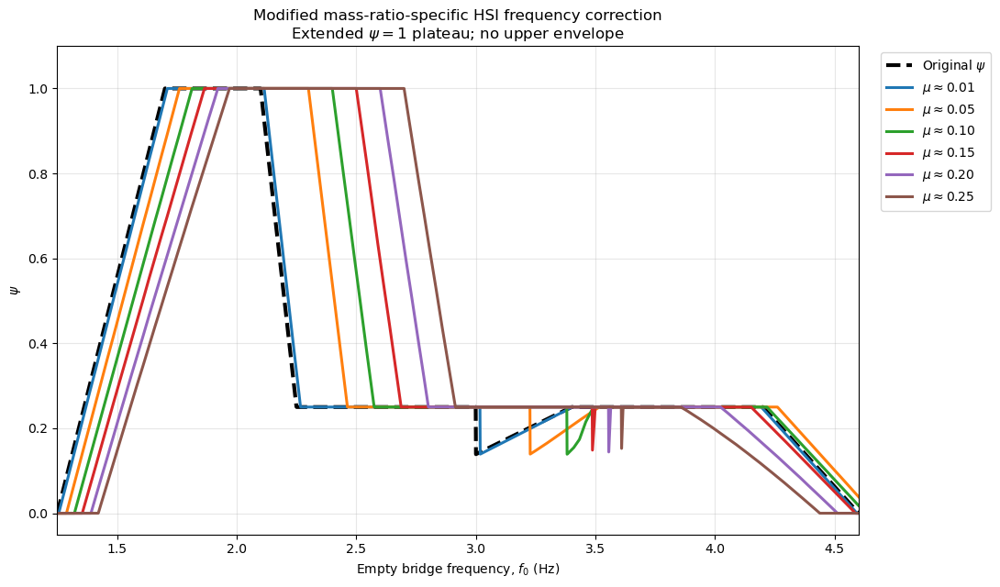

In [29]:
# ============================================================
# EXTEND THE PSI = 1 PLATEAU
# FOR EACH MASS-RATIO-SPECIFIC PSI CURVE
#
# We keep the existing psi_mu shape.
#
# Only change:
#
#   - extend the psi = 1 plateau
#   - translate the entire right-hand part of the curve
#     by the same amount
#
# NO UPPER ENVELOPE
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# TARGET END OF PSI = 1 PLATEAU
#
# Interpretation:
#
# mu = 0.01 : unchanged
# mu = 0.05 : plateau until 2.30 Hz
# mu = 0.10 : plateau until 2.40 Hz
# mu = 0.15 : plateau until 2.50 Hz
# mu = 0.20 : plateau until 2.60 Hz
# mu = 0.25 : plateau until 2.70 Hz
# ============================================================

TARGET_PLATEAU_END_BY_MU = {

    0.01: None,     # unchanged

    0.05: 2.30,

    0.10: 2.40,

    0.15: 2.50,

    0.20: 2.60,

    0.25: 2.70,
}


# ============================================================
# SETTINGS
# ============================================================

FMIN = 1.25
FMAX = 4.60

N_FINE = 10000

# Numerical tolerance used to identify psi = 1 plateau
PLATEAU_TOL = 1e-3


# ============================================================
# FIND CURRENT END OF PSI = 1 PLATEAU
#
# This is found independently for every mass ratio.
# ============================================================

def find_current_plateau_end(density):

    f_dense = np.linspace(
        FMIN,
        FMAX,
        N_FINE
    )

    psi_dense = psi_for_density(
        f_dense,
        density
    )


    valid = (
        np.isfinite(psi_dense)
        &
        (psi_dense >= 1.0 - PLATEAU_TOL)
    )


    if not np.any(valid):

        raise ValueError(
            f"No psi=1 plateau found "
            f"for density={density:.4f}"
        )


    # Last frequency belonging to psi ≈ 1 plateau
    plateau_end = np.max(
        f_dense[valid]
    )


    return float(
        plateau_end
    )


# ============================================================
# BUILD TABLE OF OLD AND NEW PLATEAU ENDS
# ============================================================

plateau_info = {}


for density_key, data in psi_mu_data.items():

    mu = float(
        data["mu"]
    )


    old_end = find_current_plateau_end(
        density_key
    )


    # Match mu robustly
    target_end = None

    for mu_key, value in TARGET_PLATEAU_END_BY_MU.items():

        if np.isclose(
            mu,
            mu_key
        ):

            target_end = value

            break


    # mu = 0.01 -> unchanged
    if target_end is None:

        new_end = old_end

    else:

        new_end = float(
            target_end
        )


    # We only want to EXTEND the plateau,
    # never shorten the original one.
    new_end = max(
        new_end,
        old_end
    )


    delta = (
        new_end
        -
        old_end
    )


    plateau_info[
        round(
            float(density_key),
            4
        )
    ] = {

        "mu": mu,

        "old_end": old_end,

        "new_end": new_end,

        "delta": delta,
    }


# ============================================================
# PRINT BREAKPOINTS
# ============================================================

print("\n" + "=" * 75)

print(
    "MASS-RATIO-SPECIFIC PSI PLATEAU MODIFICATION"
)

print("=" * 75)


for density, info in plateau_info.items():

    print(

        f"mu = {info['mu']:.2f} | "

        f"old plateau end = "
        f"{info['old_end']:.3f} Hz | "

        f"new plateau end = "
        f"{info['new_end']:.3f} Hz | "

        f"shift Δ = "
        f"{info['delta']:.3f} Hz"
    )


# ============================================================
# NEW MODIFIED MASS-SPECIFIC PSI FUNCTION
#
#
#                psi_mu(f)            f <= b_mu
#
# psi_new_mu =   1                    b_mu < f <= B_mu
#
#                psi_mu(f - Delta)    f > B_mu
#
#
# where:
#
# Delta = B_mu - b_mu
#
# ============================================================

def psi_for_density_extended(
    f0,
    density
):

    f0 = np.asarray(
        f0,
        dtype=float
    )


    density_key = round(
        float(density),
        4
    )


    if density_key not in plateau_info:

        raise KeyError(

            f"No plateau information "
            f"for density={density_key:.4f}"
        )


    info = plateau_info[
        density_key
    ]


    old_end = info[
        "old_end"
    ]

    new_end = info[
        "new_end"
    ]

    delta = info[
        "delta"
    ]


    # --------------------------------------------------------
    # Start with original mass-specific psi
    # --------------------------------------------------------

    psi_new = psi_for_density(
        f0,
        density
    )


    # --------------------------------------------------------
    # If no extension is needed:
    #
    # return original mass-specific curve
    # --------------------------------------------------------

    if delta <= 1e-12:

        return psi_new


    # --------------------------------------------------------
    # 1. Extended plateau
    #
    # old plateau end -> new plateau end
    # --------------------------------------------------------

    plateau_mask = (

        (f0 > old_end)

        &

        (f0 <= new_end)
    )


    psi_new[
        plateau_mask
    ] = 1.0


    # --------------------------------------------------------
    # 2. Everything after the new plateau is translated
    #    to the right by Delta.
    #
    # Evaluate original psi_mu at:
    #
    #       f_shifted = f - Delta
    #
    # This keeps the original curve shape.
    # --------------------------------------------------------

    right_mask = (

        f0
        >
        new_end
    )


    if np.any(
        right_mask
    ):

        shifted_frequency = (

            f0[
                right_mask
            ]

            -

            delta
        )


        psi_new[
            right_mask
        ] = psi_for_density(

            shifted_frequency,

            density
        )


    return psi_new


# ============================================================
# FIGURE
#
# NEW SHIFTED PSI FOR ALL MASS RATIOS
# ============================================================

f_plot = np.linspace(
    FMIN,
    FMAX,
    3000
)


fig, ax = plt.subplots(

    figsize=(
        11,
        6.5
    )
)


# ============================================================
# ORIGINAL CODE PSI
# ============================================================

ax.plot(

    f_plot,

    psi_original(
        f_plot
    ),

    color="black",

    linestyle="--",

    linewidth=3.0,

    label=r"Original $\psi$"
)


# ============================================================
# NEW MASS-SPECIFIC PSI CURVES
# ============================================================

for density in sorted(
    psi_mu_data.keys()
):

    info = plateau_info[
        round(
            float(density),
            4
        )
    ]


    mu = info[
        "mu"
    ]


    psi_new = psi_for_density_extended(

        f_plot,

        density
    )


    ax.plot(

        f_plot,

        psi_new,

        linewidth=2.2,

        label=(
            rf"$\mu\approx{mu:.2f}$"
        )
    )


# ============================================================
# FORMAT
# ============================================================

ax.set_xlabel(

    r"Empty bridge frequency, $f_0$ (Hz)"
)


ax.set_ylabel(

    r"$\psi$"
)


ax.set_title(

    r"Modified mass-ratio-specific HSI frequency correction"
    "\n"
    r"Extended $\psi=1$ plateau; no upper envelope"
)


ax.set_xlim(

    FMIN,

    FMAX
)


ax.set_ylim(

    -0.05,

    1.10
)


ax.grid(

    True,

    alpha=0.30
)


ax.legend(

    bbox_to_anchor=(
        1.02,
        1
    ),

    loc="upper left"
)


plt.tight_layout()

plt.show()


BIAS AFTER NEW EXTENDED MASS-SPECIFIC PSI
 mass_ratio  target_beamdamp  bridge_frequency  psi_original  psi_mu_old  psi_mu_extended  code_bias_mean  bias_after_old_mu_psi_mean  bias_after_extended_psi_mean
       0.01            0.005              1.50      0.555556    0.537778         0.537778        0.149618                    0.154564                      0.154564
       0.01            0.005              1.60      0.777778    0.757778         0.757778        0.145988                    0.149841                      0.149841
       0.01            0.005              1.70      1.000000    0.977778         0.977778        0.166666                    0.170454                      0.170454
       0.01            0.005              1.75      1.000000    1.000000         1.000000        0.237292                    0.237292                      0.237292
       0.01            0.005              1.80      1.000000    1.000000         1.000000        0.269525                    0.269525    

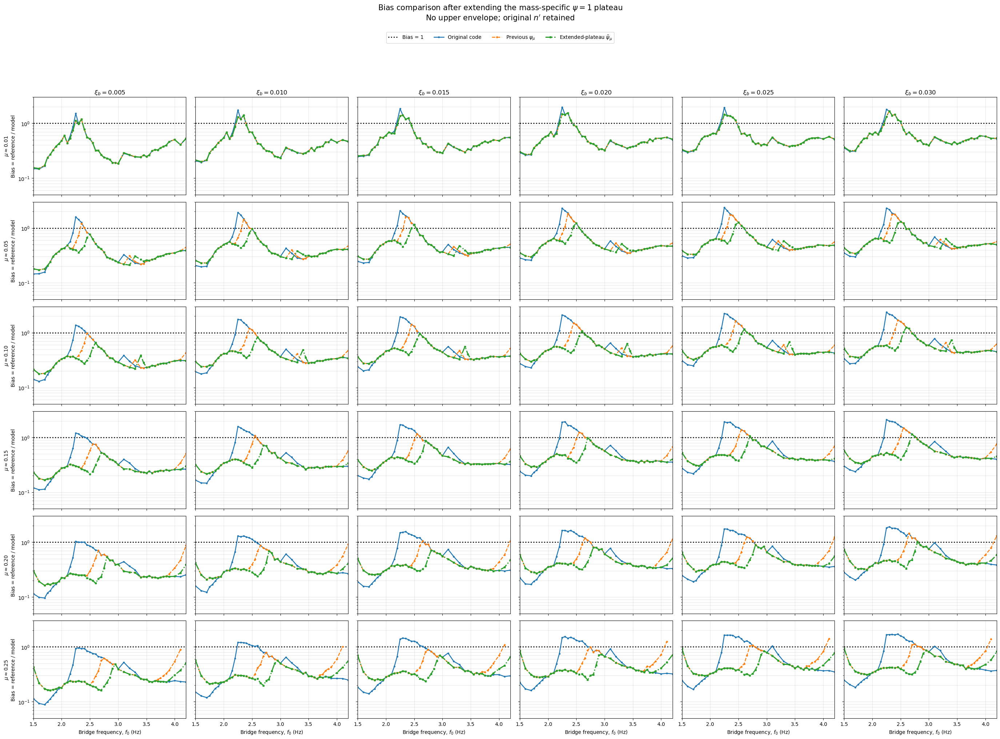

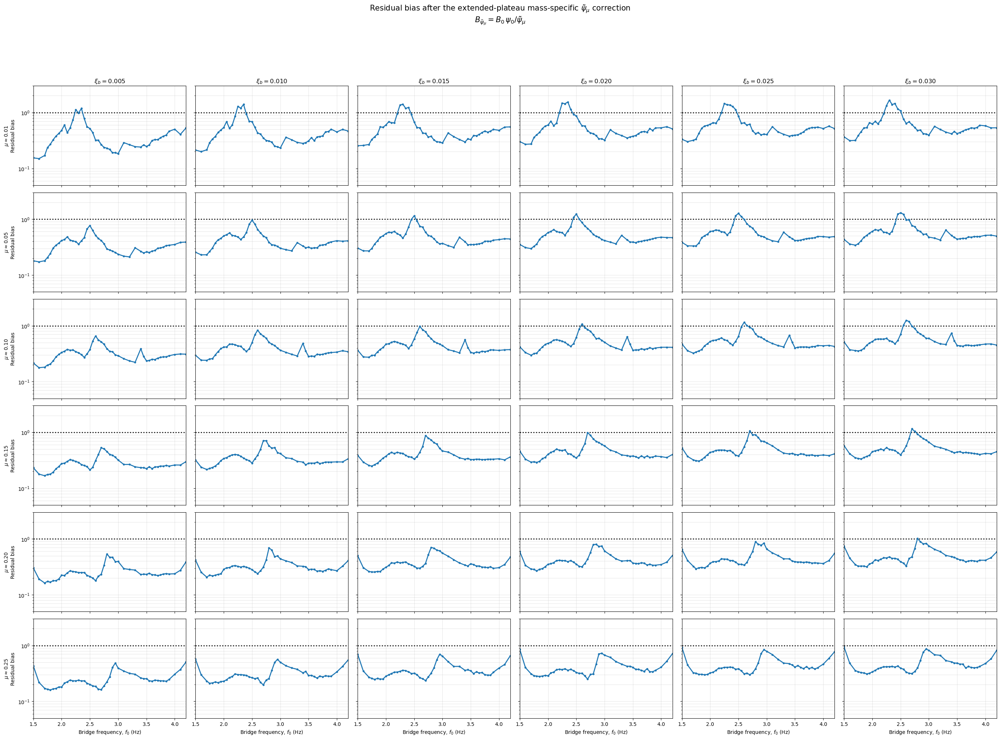


Created dataframe:
extended_psi_bias_df


In [31]:
# ============================================================
# BIAS CALIBRATION USING THE NEW EXTENDED-PLATEAU
# MASS-RATIO-SPECIFIC PSI
#
# NO UPPER ENVELOPE
#
# Original n' is retained.
#
# For each mass ratio:
#
#   B_newpsi =
#
#   B_original
#   * psi_original
#   / psi_extended_mu
#
# ROWS    = mass ratio
# COLUMNS = structural damping ratio
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

DENSITIES_TO_USE = [
    0.0333,
    0.1667,
    0.3333,
    0.5000,
    0.6667,
    0.8333,
]

TARGET_DAMPINGS = [
    0.005,
    0.010,
    0.015,
    0.020,
    0.025,
    0.030,
]

density_to_mass_ratio = {
    0.0333: 0.01,
    0.1667: 0.05,
    0.3333: 0.10,
    0.5000: 0.15,
    0.6667: 0.20,
    0.8333: 0.25,
}

MEASURE = "Peak absolute acceleration"

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

# Do not form psi ratios very close to zero
PSI_MIN = 0.02

# Plot settings
USE_LOG_SCALE = True

YMIN_BIAS = 0.05
YMAX_BIAS = 3.0


# ============================================================
# CHECK REQUIRED OBJECTS
# ============================================================

if "corrected_df" not in globals():
    raise NameError(
        "corrected_df does not exist. "
        "Run the bias-summary loading/stitching code first."
    )

if "psi_original" not in globals():
    raise NameError(
        "psi_original() does not exist."
    )

if "psi_for_density" not in globals():
    raise NameError(
        "psi_for_density() does not exist."
    )

if "psi_for_density_extended" not in globals():
    raise NameError(
        "psi_for_density_extended() does not exist. "
        "Run the extended-plateau psi code first."
    )


# ============================================================
# START FROM ORIGINAL BIAS DATA
# ============================================================

newpsi_bias_df = corrected_df.copy()


# ============================================================
# NUMERIC CLEANING
# ============================================================

required_cols = [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "measure",
    "code_bias_mean",
]

missing = [
    col for col in required_cols
    if col not in newpsi_bias_df.columns
]

if missing:
    raise KeyError(
        f"corrected_df missing columns: {missing}"
    )


for col in [
    "bridge_frequency",
    "target_beamdamp",
    "target_density",
    "code_bias_mean",
]:
    newpsi_bias_df[col] = pd.to_numeric(
        newpsi_bias_df[col],
        errors="coerce"
    )


# Optional uncertainty columns
for col in [
    "code_bias_p5",
    "code_bias_p95",
]:
    if col in newpsi_bias_df.columns:
        newpsi_bias_df[col] = pd.to_numeric(
            newpsi_bias_df[col],
            errors="coerce"
        )


newpsi_bias_df["measure"] = (
    newpsi_bias_df["measure"]
    .astype(str)
    .str.strip()
)


newpsi_bias_df = newpsi_bias_df.dropna(
    subset=[
        "bridge_frequency",
        "target_beamdamp",
        "target_density",
        "code_bias_mean",
    ]
).copy()


# ============================================================
# DENSITY -> MASS RATIO
# ============================================================

newpsi_bias_df["density_key"] = (
    newpsi_bias_df["target_density"]
    .round(4)
)

newpsi_bias_df["mass_ratio"] = (
    newpsi_bias_df["density_key"]
    .map({
        round(k, 4): v
        for k, v in density_to_mass_ratio.items()
    })
)


# ============================================================
# FILTER DENSITIES
# ============================================================

density_mask = np.zeros(
    len(newpsi_bias_df),
    dtype=bool
)

for density in DENSITIES_TO_USE:

    density_mask |= np.isclose(
        newpsi_bias_df["target_density"],
        density
    )


# ============================================================
# FILTER DAMPINGS
# ============================================================

damping_mask = np.zeros(
    len(newpsi_bias_df),
    dtype=bool
)

for damp in TARGET_DAMPINGS:

    damping_mask |= np.isclose(
        newpsi_bias_df["target_beamdamp"],
        damp
    )


# ============================================================
# FINAL FILTER
# ============================================================

newpsi_bias_df = newpsi_bias_df[

    density_mask

    & damping_mask

    & (
        newpsi_bias_df["measure"]
        == MEASURE
    )

    & (
        newpsi_bias_df["bridge_frequency"]
        >= PLOT_FMIN
    )

    & (
        newpsi_bias_df["bridge_frequency"]
        <= PLOT_FMAX
    )

].copy()


if newpsi_bias_df.empty:

    raise ValueError(
        "No rows remain after filtering."
    )


# Remove only true duplicates
newpsi_bias_df = newpsi_bias_df.drop_duplicates(

    subset=[
        "density_key",
        "target_beamdamp",
        "bridge_frequency",
        "measure",
    ],

    keep="first"
).copy()


# ============================================================
# ORIGINAL PSI
# ============================================================

newpsi_bias_df["psi_original"] = psi_original(

    newpsi_bias_df[
        "bridge_frequency"
    ].to_numpy(dtype=float)

)


# ============================================================
# OLD MASS-SPECIFIC PSI
#
# Useful only for comparison.
# ============================================================

newpsi_bias_df["psi_mu_old"] = np.nan


# ============================================================
# NEW EXTENDED MASS-SPECIFIC PSI
# ============================================================

newpsi_bias_df["psi_mu_extended"] = np.nan


for density in DENSITIES_TO_USE:

    mask = np.isclose(
        newpsi_bias_df["target_density"],
        density
    )

    if not np.any(mask):
        continue


    f_values = (

        newpsi_bias_df.loc[
            mask,
            "bridge_frequency"
        ]

        .to_numpy(dtype=float)
    )


    # Previous mass-specific shifted psi
    newpsi_bias_df.loc[
        mask,
        "psi_mu_old"
    ] = psi_for_density(
        f_values,
        density
    )


    # NEW extended-plateau psi
    newpsi_bias_df.loc[
        mask,
        "psi_mu_extended"
    ] = psi_for_density_extended(
        f_values,
        density
    )


# ============================================================
# VALID PSI REGIONS
#
# Avoid meaningless division close to psi = 0.
# ============================================================

valid_old = (

    np.isfinite(
        newpsi_bias_df["psi_original"]
    )

    & np.isfinite(
        newpsi_bias_df["psi_mu_old"]
    )

    & (
        newpsi_bias_df["psi_original"]
        > PSI_MIN
    )

    & (
        newpsi_bias_df["psi_mu_old"]
        > PSI_MIN
    )
)


valid_extended = (

    np.isfinite(
        newpsi_bias_df["psi_original"]
    )

    & np.isfinite(
        newpsi_bias_df["psi_mu_extended"]
    )

    & (
        newpsi_bias_df["psi_original"]
        > PSI_MIN
    )

    & (
        newpsi_bias_df["psi_mu_extended"]
        > PSI_MIN
    )
)


# ============================================================
# BIAS AFTER OLD MASS-SPECIFIC PSI
#
# For comparison:
#
# B_old_mu =
#
# B0 * psi_original / psi_mu_old
# ============================================================

newpsi_bias_df[
    "bias_after_old_mu_psi_mean"
] = np.nan


newpsi_bias_df.loc[
    valid_old,
    "bias_after_old_mu_psi_mean"
] = (

    newpsi_bias_df.loc[
        valid_old,
        "code_bias_mean"
    ]

    *

    newpsi_bias_df.loc[
        valid_old,
        "psi_original"
    ]

    /

    newpsi_bias_df.loc[
        valid_old,
        "psi_mu_old"
    ]
)


# ============================================================
# BIAS AFTER NEW EXTENDED PSI
#
# THIS IS THE MAIN RESULT
#
# B_extended =
#
# B0 * psi_original / psi_mu_extended
# ============================================================

newpsi_bias_df[
    "bias_after_extended_psi_mean"
] = np.nan


newpsi_bias_df.loc[
    valid_extended,
    "bias_after_extended_psi_mean"
] = (

    newpsi_bias_df.loc[
        valid_extended,
        "code_bias_mean"
    ]

    *

    newpsi_bias_df.loc[
        valid_extended,
        "psi_original"
    ]

    /

    newpsi_bias_df.loc[
        valid_extended,
        "psi_mu_extended"
    ]
)


# ============================================================
# RESPONSE MULTIPLIER CAUSED BY NEW PSI
#
# R_new / R_original
#
# = psi_extended / psi_original
# ============================================================

newpsi_bias_df[
    "extended_psi_response_multiplier"
] = np.nan


newpsi_bias_df.loc[
    valid_extended,
    "extended_psi_response_multiplier"
] = (

    newpsi_bias_df.loc[
        valid_extended,
        "psi_mu_extended"
    ]

    /

    newpsi_bias_df.loc[
        valid_extended,
        "psi_original"
    ]
)


# ============================================================
# OPTIONAL P5 / P95 BIAS
# ============================================================

if "code_bias_p5" in newpsi_bias_df.columns:

    newpsi_bias_df[
        "bias_after_extended_psi_p5"
    ] = np.nan

    newpsi_bias_df.loc[
        valid_extended,
        "bias_after_extended_psi_p5"
    ] = (

        newpsi_bias_df.loc[
            valid_extended,
            "code_bias_p5"
        ]

        *

        newpsi_bias_df.loc[
            valid_extended,
            "psi_original"
        ]

        /

        newpsi_bias_df.loc[
            valid_extended,
            "psi_mu_extended"
        ]
    )


if "code_bias_p95" in newpsi_bias_df.columns:

    newpsi_bias_df[
        "bias_after_extended_psi_p95"
    ] = np.nan

    newpsi_bias_df.loc[
        valid_extended,
        "bias_after_extended_psi_p95"
    ] = (

        newpsi_bias_df.loc[
            valid_extended,
            "code_bias_p95"
        ]

        *

        newpsi_bias_df.loc[
            valid_extended,
            "psi_original"
        ]

        /

        newpsi_bias_df.loc[
            valid_extended,
            "psi_mu_extended"
        ]
    )


# ============================================================
# RESIDUAL CORRECTION FACTOR
#
# If later we want exact mean-bias calibration:
#
# C_residual = B_extended
#
# because multiplying the model by B_extended
# would make mean bias = 1.
# ============================================================

newpsi_bias_df[
    "residual_correction_factor"
] = (

    newpsi_bias_df[
        "bias_after_extended_psi_mean"
    ]
)


# ============================================================
# PRINT CHECK
# ============================================================

print("\n" + "=" * 110)

print(
    "BIAS AFTER NEW EXTENDED MASS-SPECIFIC PSI"
)

print("=" * 110)


check_cols = [

    "mass_ratio",

    "target_beamdamp",

    "bridge_frequency",

    "psi_original",

    "psi_mu_old",

    "psi_mu_extended",

    "code_bias_mean",

    "bias_after_old_mu_psi_mean",

    "bias_after_extended_psi_mean",
]


print(

    newpsi_bias_df[
        check_cols
    ]

    .sort_values(
        [
            "mass_ratio",
            "target_beamdamp",
            "bridge_frequency",
        ]
    )

    .head(100)

    .to_string(index=False)
)


# ============================================================
# FIGURE 1
#
# ORIGINAL BIAS
# vs
# OLD MASS-SPECIFIC PSI
# vs
# NEW EXTENDED MASS-SPECIFIC PSI
#
# This directly shows whether the plateau extension improved
# the bias.
#
# ROWS    = mass ratio
# COLUMNS = damping ratio
# ============================================================

mass_ratios_available = [

    mu

    for mu in sorted(

        newpsi_bias_df[
            "mass_ratio"
        ]

        .dropna()

        .unique()
    )
]


dampings_available = [

    damp

    for damp in TARGET_DAMPINGS

    if np.any(

        np.isclose(

            newpsi_bias_df[
                "target_beamdamp"
            ],

            damp
        )
    )
]


n_rows = len(
    mass_ratios_available
)

n_cols = len(
    dampings_available
)


fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(
        4.6 * n_cols,
        3.4 * n_rows
    ),

    sharex=True,

    sharey=True
)


if n_rows == 1 and n_cols == 1:

    axes = np.array([[axes]])

elif n_rows == 1:

    axes = np.array([axes])

elif n_cols == 1:

    axes = np.array(
        [[ax] for ax in axes]
    )


for i, mu in enumerate(
    mass_ratios_available
):

    for j, damp in enumerate(
        dampings_available
    ):

        ax = axes[i, j]


        sub = newpsi_bias_df[

            np.isclose(
                newpsi_bias_df[
                    "mass_ratio"
                ],
                mu
            )

            &

            np.isclose(
                newpsi_bias_df[
                    "target_beamdamp"
                ],
                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            ax.axis("off")

            continue


        # Bias = 1
        ax.axhline(

            1.0,

            color="black",

            linestyle=":",

            linewidth=2,

            label=(
                "Bias = 1"
                if i == 0 and j == 0
                else None
            )
        )


        # Original code bias
        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "code_bias_mean"
            ],

            linewidth=1.8,

            marker="o",

            markersize=2.5,

            label=(
                "Original code"
                if i == 0 and j == 0
                else None
            )
        )


        # Previous mass-specific psi
        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_old_mu_psi_mean"
            ],

            linewidth=1.8,

            linestyle="--",

            marker="D",

            markersize=2.5,

            label=(
                r"Previous $\psi_\mu$"
                if i == 0 and j == 0
                else None
            )
        )


        # NEW extended psi
        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_extended_psi_mean"
            ],

            linewidth=2.2,

            linestyle="-.",

            marker="s",

            markersize=2.5,

            label=(
                r"Extended-plateau $\tilde{\psi}_\mu$"
                if i == 0 and j == 0
                else None
            )
        )


        if i == 0:

            ax.set_title(
                rf"$\xi_b={damp:.3f}$"
            )


        if j == 0:

            ax.set_ylabel(

                rf"$\mu\approx{mu:.2f}$"
                "\n"
                r"Bias = reference / model"
            )


        if i == n_rows - 1:

            ax.set_xlabel(
                r"Bridge frequency, $f_0$ (Hz)"
            )


        ax.set_xlim(
            PLOT_FMIN,
            PLOT_FMAX
        )


        if USE_LOG_SCALE:

            ax.set_yscale(
                "log"
            )


        ax.set_ylim(
            YMIN_BIAS,
            YMAX_BIAS
        )


        ax.grid(
            True,
            which="both",
            alpha=0.30
        )


# ============================================================
# LEGEND + TITLE
# ============================================================

handles, labels = (

    axes[0, 0]
    .get_legend_handles_labels()
)


fig.legend(

    handles,
    labels,

    loc="upper center",

    bbox_to_anchor=(
        0.5,
        0.96
    ),

    ncol=4,

    frameon=True
)


fig.suptitle(

    r"Bias comparison after extending the mass-specific "
    r"$\psi=1$ plateau"
    "\n"
    r"No upper envelope; original $n'$ retained",

    fontsize=15,

    y=0.995
)


fig.tight_layout(

    rect=[
        0,
        0,
        1,
        0.92
    ]
)


plt.show()


# ============================================================
# FIGURE 2
#
# ONLY THE NEW EXTENDED-PSI RESIDUAL BIAS
#
# Cleaner figure for interpretation.
# ============================================================

fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(
        4.6 * n_cols,
        3.4 * n_rows
    ),

    sharex=True,

    sharey=True
)


if n_rows == 1 and n_cols == 1:

    axes = np.array([[axes]])

elif n_rows == 1:

    axes = np.array([axes])

elif n_cols == 1:

    axes = np.array(
        [[ax] for ax in axes]
    )


for i, mu in enumerate(
    mass_ratios_available
):

    for j, damp in enumerate(
        dampings_available
    ):

        ax = axes[i, j]


        sub = newpsi_bias_df[

            np.isclose(
                newpsi_bias_df[
                    "mass_ratio"
                ],
                mu
            )

            &

            np.isclose(
                newpsi_bias_df[
                    "target_beamdamp"
                ],
                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            ax.axis("off")

            continue


        ax.axhline(

            1.0,

            color="black",

            linestyle=":",

            linewidth=2
        )


        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_extended_psi_mean"
            ],

            linewidth=2.0,

            marker="o",

            markersize=3
        )


        if i == 0:

            ax.set_title(
                rf"$\xi_b={damp:.3f}$"
            )


        if j == 0:

            ax.set_ylabel(

                rf"$\mu\approx{mu:.2f}$"
                "\n"
                r"Residual bias"
            )


        if i == n_rows - 1:

            ax.set_xlabel(
                r"Bridge frequency, $f_0$ (Hz)"
            )


        ax.set_xlim(
            PLOT_FMIN,
            PLOT_FMAX
        )


        if USE_LOG_SCALE:

            ax.set_yscale(
                "log"
            )


        ax.set_ylim(
            YMIN_BIAS,
            YMAX_BIAS
        )


        ax.grid(
            True,
            which="both",
            alpha=0.30
        )


fig.suptitle(

    r"Residual bias after the extended-plateau "
    r"mass-specific $\tilde{\psi}_\mu$ correction"
    "\n"
    r"$B_{\tilde{\psi}_\mu}"
    r"=B_0\,\psi_0/\tilde{\psi}_\mu$",

    fontsize=15,

    y=0.995
)


fig.tight_layout(

    rect=[
        0,
        0,
        1,
        0.94
    ]
)


plt.show()


# ============================================================
# CLEAN OUTPUT DATAFRAME
# ============================================================

extended_psi_bias_df = (

    newpsi_bias_df[

        [

            "bridge_frequency",

            "target_beamdamp",

            "target_density",

            "mass_ratio",

            "psi_original",

            "psi_mu_old",

            "psi_mu_extended",

            "code_bias_mean",

            "bias_after_old_mu_psi_mean",

            "bias_after_extended_psi_mean",

            "residual_correction_factor",
        ]

    ]

    .sort_values(

        [

            "mass_ratio",

            "target_beamdamp",

            "bridge_frequency"
        ]

    )

    .reset_index(
        drop=True
    )
)


print(
    "\nCreated dataframe:"
)

print(
    "extended_psi_bias_df"
)

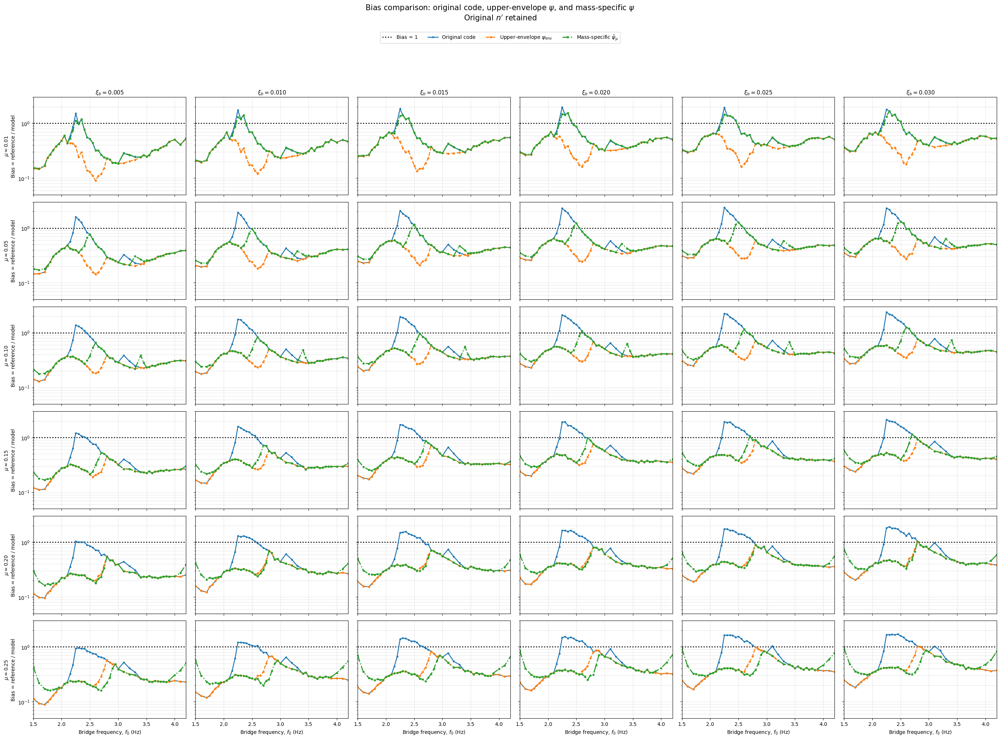

In [32]:
# ============================================================
# BIAS COMPARISON
#
# 1. ORIGINAL CODE
# 2. UPPER-ENVELOPE PSI
# 3. NEW MASS-RATIO-SPECIFIC EXTENDED PSI
#
# Original n' retained in all cases.
#
# ROWS    = mass ratio
# COLUMNS = structural damping ratio
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20

USE_LOG_SCALE = True

YMIN_BIAS = 0.05
YMAX_BIAS = 3.0

PSI_MIN = 0.02


# ============================================================
# CHECK REQUIRED OBJECTS
# ============================================================

if "newpsi_bias_df" not in globals():
    raise NameError(
        "newpsi_bias_df does not exist. "
        "Run the extended mass-specific psi bias code first."
    )

if "psi_envelope" not in globals():
    raise NameError(
        "psi_envelope() does not exist. "
        "Run the upper-envelope psi construction code first."
    )


# ============================================================
# START FROM DATAFRAME ALREADY USED FOR THE NEW
# MASS-SPECIFIC PSI CALCULATION
# ============================================================

compare_df = newpsi_bias_df.copy()


# ============================================================
# CALCULATE UPPER-ENVELOPE PSI
# ============================================================

compare_df["psi_envelope"] = psi_envelope(

    compare_df[
        "bridge_frequency"
    ].to_numpy(dtype=float)

)


# ============================================================
# VALID REGION FOR UPPER-ENVELOPE PSI
# ============================================================

valid_env = (

    np.isfinite(
        compare_df["psi_original"]
    )

    &

    np.isfinite(
        compare_df["psi_envelope"]
    )

    &

    (
        compare_df["psi_original"]
        > PSI_MIN
    )

    &

    (
        compare_df["psi_envelope"]
        > PSI_MIN
    )

)


# ============================================================
# BIAS AFTER UPPER-ENVELOPE PSI
#
# B_env =
#
# B_original * psi_original / psi_envelope
# ============================================================

compare_df[
    "bias_after_envelope_psi_mean"
] = np.nan


compare_df.loc[
    valid_env,
    "bias_after_envelope_psi_mean"
] = (

    compare_df.loc[
        valid_env,
        "code_bias_mean"
    ]

    *

    compare_df.loc[
        valid_env,
        "psi_original"
    ]

    /

    compare_df.loc[
        valid_env,
        "psi_envelope"
    ]

)


# ============================================================
# MASS-SPECIFIC EXTENDED PSI BIAS
#
# This should already exist from the previous code:
#
# bias_after_extended_psi_mean
# ============================================================

if "bias_after_extended_psi_mean" not in compare_df.columns:

    raise KeyError(
        "bias_after_extended_psi_mean is missing. "
        "Run the extended-plateau mass-specific psi "
        "bias calculation first."
    )


# ============================================================
# FILTER PLOT FREQUENCY RANGE
# ============================================================

compare_df = compare_df[

    (
        compare_df["bridge_frequency"]
        >= PLOT_FMIN
    )

    &

    (
        compare_df["bridge_frequency"]
        <= PLOT_FMAX
    )

].copy()


# ============================================================
# AVAILABLE MASS RATIOS AND DAMPINGS
# ============================================================

mass_ratios_available = sorted(

    compare_df[
        "mass_ratio"
    ]

    .dropna()

    .unique()

)


dampings_available = [

    damp

    for damp in TARGET_DAMPINGS

    if np.any(

        np.isclose(

            compare_df[
                "target_beamdamp"
            ],

            damp
        )
    )
]


n_rows = len(
    mass_ratios_available
)

n_cols = len(
    dampings_available
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(
        4.6 * n_cols,
        3.4 * n_rows
    ),

    sharex=True,

    sharey=True
)


# Make axes always 2D
if n_rows == 1 and n_cols == 1:

    axes = np.array([[axes]])

elif n_rows == 1:

    axes = np.array([axes])

elif n_cols == 1:

    axes = np.array(
        [[ax] for ax in axes]
    )


# ============================================================
# LOOP THROUGH MASS RATIOS AND DAMPINGS
# ============================================================

for i, mu in enumerate(
    mass_ratios_available
):

    for j, damp in enumerate(
        dampings_available
    ):

        ax = axes[i, j]


        sub = compare_df[

            np.isclose(
                compare_df["mass_ratio"],
                mu
            )

            &

            np.isclose(
                compare_df["target_beamdamp"],
                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            ax.axis("off")

            continue


        # ====================================================
        # BIAS = 1
        # ====================================================

        ax.axhline(

            1.0,

            color="black",

            linestyle=":",

            linewidth=2.0,

            label=(
                "Bias = 1"
                if i == 0 and j == 0
                else None
            )
        )


        # ====================================================
        # 1. ORIGINAL CODE
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "code_bias_mean"
            ],

            marker="o",

            markersize=2.8,

            linewidth=1.8,

            linestyle="-",

            label=(
                "Original code"
                if i == 0 and j == 0
                else None
            )
        )


        # ====================================================
        # 2. UPPER-ENVELOPE PSI
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_envelope_psi_mean"
            ],

            marker="D",

            markersize=2.8,

            linewidth=2.0,

            linestyle="--",

            label=(
                r"Upper-envelope $\psi_{\rm env}$"
                if i == 0 and j == 0
                else None
            )
        )


        # ====================================================
        # 3. NEW MASS-RATIO-SPECIFIC EXTENDED PSI
        # ====================================================

        ax.plot(

            sub[
                "bridge_frequency"
            ],

            sub[
                "bias_after_extended_psi_mean"
            ],

            marker="s",

            markersize=2.8,

            linewidth=2.1,

            linestyle="-.",

            label=(
                r"Mass-specific $\tilde{\psi}_\mu$"
                if i == 0 and j == 0
                else None
            )
        )


        # ====================================================
        # COLUMN TITLE = DAMPING
        # ====================================================

        if i == 0:

            ax.set_title(
                rf"$\xi_b={damp:.3f}$",
                fontsize=11
            )


        # ====================================================
        # ROW LABEL = MASS RATIO
        # ====================================================

        if j == 0:

            ax.set_ylabel(

                rf"$\mu\approx{mu:.2f}$"
                "\n"
                r"Bias = reference / model",

                fontsize=10
            )


        # ====================================================
        # X LABEL
        # ====================================================

        if i == n_rows - 1:

            ax.set_xlabel(

                r"Bridge frequency, $f_0$ (Hz)"
            )


        # ====================================================
        # AXES
        # ====================================================

        ax.set_xlim(
            PLOT_FMIN,
            PLOT_FMAX
        )


        if USE_LOG_SCALE:

            ax.set_yscale(
                "log"
            )


        ax.set_ylim(
            YMIN_BIAS,
            YMAX_BIAS
        )


        ax.grid(
            True,
            which="both",
            alpha=0.30
        )


# ============================================================
# LEGEND
# ============================================================

handles, labels = (

    axes[0, 0]
    .get_legend_handles_labels()

)


fig.legend(

    handles,
    labels,

    loc="upper center",

    bbox_to_anchor=(
        0.5,
        0.96
    ),

    ncol=4,

    frameon=True
)


# ============================================================
# TITLE
# ============================================================

fig.suptitle(

    r"Bias comparison: original code, upper-envelope $\psi$, "
    r"and mass-specific $\psi$"
    "\n"
    r"Original $n'$ retained",

    fontsize=15,

    y=0.995
)


fig.tight_layout(

    rect=[
        0,
        0,
        1,
        0.92
    ]
)


plt.show()



BIAS STATISTICS FOR EACH (MASS RATIO × DAMPING RATIO) PANEL
 mass_ratio  damping_ratio                model  mean_bias  p90_bias  max_bias  n_frequency_points
     0.0100         0.0050             Original     0.4126    0.6900    1.5078                  46
     0.0100         0.0050      Envelope $\psi$     0.2842    0.4497    0.5992                  46
     0.0100         0.0050 Mass-specific $\psi$     0.4014    0.6691    1.1865                  46
     0.0100         0.0100             Original     0.4877    0.8182    1.7329                  46
     0.0100         0.0100      Envelope $\psi$     0.3318    0.4978    0.6894                  46
     0.0100         0.0100 Mass-specific $\psi$     0.4748    0.7778    1.3984                  46
     0.0100         0.0150             Original     0.5437    1.0121    1.8381                  46
     0.0100         0.0150      Envelope $\psi$     0.3724    0.5501    0.6844                  46
     0.0100         0.0150 Mass-specific $\psi$

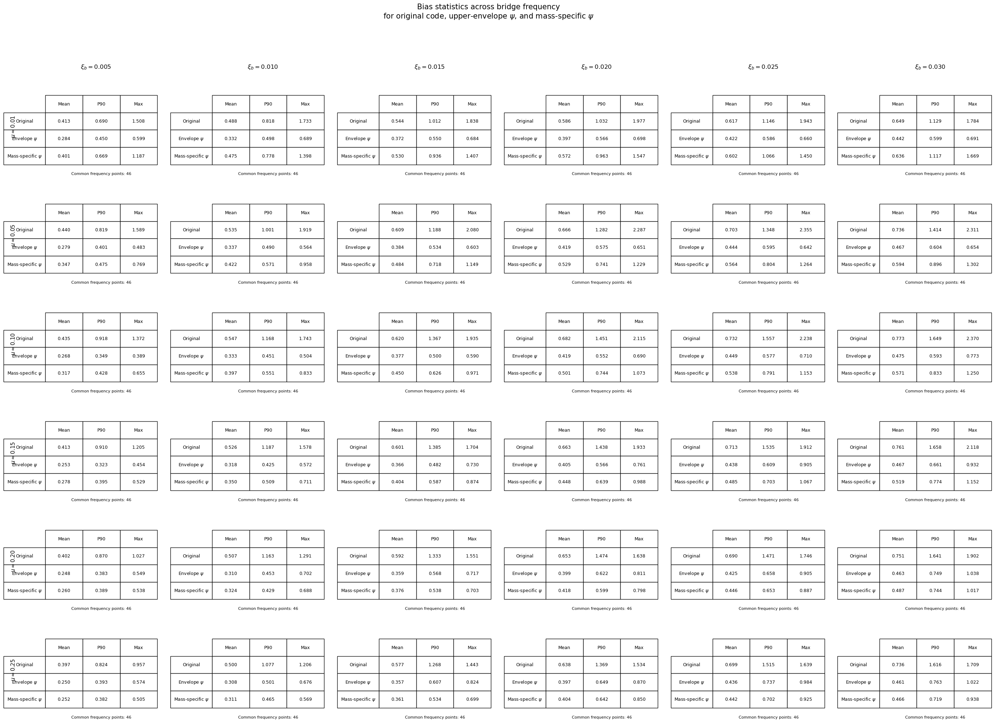



WIDE SUMMARY TABLE
mass_ratio damping_ratio        max_bias                                     mean_bias                                      p90_bias                              
                         Envelope $\psi$ Mass-specific $\psi$ Original Envelope $\psi$ Mass-specific $\psi$ Original Envelope $\psi$ Mass-specific $\psi$ Original
    0.0100        0.0050          0.5992               1.1865   1.5078          0.2842               0.4014   0.4126          0.4497               0.6691   0.6900
    0.0100        0.0100          0.6894               1.3984   1.7329          0.3318               0.4748   0.4877          0.4978               0.7778   0.8182
    0.0100        0.0150          0.6844               1.4067   1.8381          0.3724               0.5299   0.5437          0.5501               0.9361   1.0121
    0.0100        0.0200          0.6984               1.5474   1.9774          0.3970               0.5718   0.5864          0.5662               0.9629   1.0321
 

In [35]:
# ============================================================
# GRID OF BIAS STATISTICS
#
# SAME LAYOUT AS BIAS CURVE FIGURE
#
# ROWS    = MASS RATIO
# COLUMNS = DAMPING RATIO
#
# In every panel calculate:
#
#               Mean    P90    Maximum
#
# for:
#   1. Original code
#   2. Upper-envelope psi
#   3. Mass-specific extended psi
#
# Statistics are calculated across BRIDGE FREQUENCY
# within that particular (mu, xi_b) panel.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

PLOT_FMIN = 1.50
PLOT_FMAX = 4.20


# Three bias series already contained in compare_df
BIAS_SERIES = {

    "Original":
        "code_bias_mean",

    r"Envelope $\psi$":
        "bias_after_envelope_psi_mean",

    r"Mass-specific $\psi$":
        "bias_after_extended_psi_mean",
}


# ============================================================
# CHECK DATA
# ============================================================

if "compare_df" not in globals():

    raise NameError(
        "compare_df does not exist. "
        "Run the three-series bias comparison code first."
    )


required_cols = [

    "bridge_frequency",
    "mass_ratio",
    "target_beamdamp",

    "code_bias_mean",
    "bias_after_envelope_psi_mean",
    "bias_after_extended_psi_mean",
]


missing = [

    col
    for col in required_cols
    if col not in compare_df.columns
]


if missing:

    raise KeyError(
        f"compare_df is missing columns: {missing}"
    )


# ============================================================
# COPY AND FILTER FREQUENCY RANGE
# ============================================================

stats_source_df = compare_df.copy()


stats_source_df = stats_source_df[

    (
        stats_source_df["bridge_frequency"]
        >= PLOT_FMIN
    )

    &

    (
        stats_source_df["bridge_frequency"]
        <= PLOT_FMAX
    )

].copy()


# ============================================================
# AVAILABLE MASS RATIOS AND DAMPINGS
#
# Same ordering as previous graph
# ============================================================

mass_ratios_available = sorted(

    stats_source_df[
        "mass_ratio"
    ]

    .dropna()

    .unique()
)


dampings_available = [

    damp

    for damp in TARGET_DAMPINGS

    if np.any(

        np.isclose(

            stats_source_df[
                "target_beamdamp"
            ],

            damp
        )
    )
]


n_rows = len(
    mass_ratios_available
)

n_cols = len(
    dampings_available
)


# ============================================================
# CALCULATE STATISTICS FOR EACH PANEL
# ============================================================

statistics_rows = []


for mu in mass_ratios_available:

    for damp in dampings_available:


        # ----------------------------------------------------
        # Extract exactly one panel
        # ----------------------------------------------------

        sub = stats_source_df[

            np.isclose(
                stats_source_df[
                    "mass_ratio"
                ],
                mu
            )

            &

            np.isclose(
                stats_source_df[
                    "target_beamdamp"
                ],
                damp
            )

        ].copy()


        sub = sub.sort_values(
            "bridge_frequency"
        )


        if sub.empty:

            continue


        # ----------------------------------------------------
        # COMMON VALID FREQUENCY POINTS
        #
        # Important for fair comparison:
        # all 3 models use exactly the same frequency points.
        # ----------------------------------------------------

        common_valid = np.ones(
            len(sub),
            dtype=bool
        )


        for col in BIAS_SERIES.values():

            values = pd.to_numeric(
                sub[col],
                errors="coerce"
            )

            common_valid &= np.isfinite(
                values
            )


        sub_valid = sub.loc[
            common_valid
        ].copy()


        if sub_valid.empty:

            continue


        # ----------------------------------------------------
        # Statistics for each of the three curves
        # ----------------------------------------------------

        for model_name, col in BIAS_SERIES.items():


            values = pd.to_numeric(

                sub_valid[col],

                errors="coerce"

            ).to_numpy(dtype=float)


            values = values[
                np.isfinite(values)
            ]


            if len(values) == 0:

                continue


            statistics_rows.append({

                "mass_ratio":
                    mu,

                "damping_ratio":
                    damp,

                "model":
                    model_name,

                "mean_bias":
                    np.mean(values),

                "p90_bias":
                    np.percentile(
                        values,
                        90
                    ),

                "max_bias":
                    np.max(values),

                "n_frequency_points":
                    len(values),
            })


# ============================================================
# CREATE SUMMARY DATAFRAME
# ============================================================

bias_grid_stats_df = pd.DataFrame(
    statistics_rows
)


print("\n")
print("=" * 110)

print(
    "BIAS STATISTICS FOR EACH "
    "(MASS RATIO × DAMPING RATIO) PANEL"
)

print("=" * 110)


print(

    bias_grid_stats_df.to_string(

        index=False,

        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# CREATE SAME GRID AS BIAS GRAPH
#
# Each panel contains a small table:
#
#                     Mean    P90    Max
#
# Original
# Envelope psi
# Mass-specific psi
# ============================================================

fig, axes = plt.subplots(

    nrows=n_rows,

    ncols=n_cols,

    figsize=(

        4.8 * n_cols,

        3.4 * n_rows
    )
)


# Ensure axes is always 2D
if n_rows == 1 and n_cols == 1:

    axes = np.array(
        [[axes]]
    )


elif n_rows == 1:

    axes = np.array(
        [axes]
    )


elif n_cols == 1:

    axes = np.array(

        [
            [ax]
            for ax in axes
        ]
    )


# ============================================================
# LOOP THROUGH PANELS
# ============================================================

for i, mu in enumerate(
    mass_ratios_available
):

    for j, damp in enumerate(
        dampings_available
    ):


        ax = axes[
            i,
            j
        ]


        # Remove normal graph axes
        ax.axis(
            "off"
        )


        panel_stats = bias_grid_stats_df[

            np.isclose(
                bias_grid_stats_df[
                    "mass_ratio"
                ],
                mu
            )

            &

            np.isclose(
                bias_grid_stats_df[
                    "damping_ratio"
                ],
                damp
            )

        ].copy()


        if panel_stats.empty:

            continue


        # ----------------------------------------------------
        # Preserve model order
        # ----------------------------------------------------

        model_order = [

            "Original",

            r"Envelope $\psi$",

            r"Mass-specific $\psi$",
        ]


        table_data = []


        for model in model_order:


            row = panel_stats[

                panel_stats[
                    "model"
                ]

                == model

            ]


            if row.empty:

                table_data.append(

                    [
                        "—",
                        "—",
                        "—",
                    ]
                )

                continue


            row = row.iloc[
                0
            ]


            table_data.append(

                [

                    f"{row['mean_bias']:.3f}",

                    f"{row['p90_bias']:.3f}",

                    f"{row['max_bias']:.3f}",
                ]
            )


        # ----------------------------------------------------
        # TABLE
        # ----------------------------------------------------

        table = ax.table(

            cellText=table_data,

            rowLabels=model_order,

            colLabels=[

                "Mean",

                "P90",

                "Max",
            ],

            cellLoc="center",

            rowLoc="center",

            loc="center",

            bbox=[

                0.12,

                0.13,

                0.84,

                0.67
            ]
        )


        table.auto_set_font_size(
            False
        )


        table.set_fontsize(
            9
        )


        table.scale(
            1.0,
            1.5
        )


        # ----------------------------------------------------
        # COLUMN TITLE = DAMPING
        # ----------------------------------------------------

        if i == 0:

            ax.set_title(

                rf"$\xi_b={damp:.3f}$",

                fontsize=12,

                pad=12
            )


        # ----------------------------------------------------
        # ROW LABEL = MASS RATIO
        # ----------------------------------------------------

        if j == 0:

            ax.text(

                -0.12,

                0.50,

                rf"$\mu\approx{mu:.2f}$",

                transform=ax.transAxes,

                rotation=90,

                va="center",

                ha="center",

                fontsize=11,

                fontweight="bold"
            )


        # ----------------------------------------------------
        # Number of common frequency points
        # ----------------------------------------------------

        npoints = int(

            panel_stats[
                "n_frequency_points"
            ].iloc[0]
        )


        ax.text(

            0.54,

            0.04,

            f"Common frequency points: {npoints}",

            transform=ax.transAxes,

            ha="center",

            va="center",

            fontsize=8
        )


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(

    "Bias statistics across bridge frequency\n"
    "for original code, upper-envelope "
    r"$\psi$, and mass-specific $\psi$",

    fontsize=15,

    y=0.995
)


fig.tight_layout(

    rect=[

        0.02,

        0,

        1,

        0.95
    ]
)


plt.show()


# ============================================================
# OPTIONAL:
# CREATE A WIDE TABLE FOR EASY COMPARISON
#
# One row per (mu, damping)
# ============================================================

wide_stats_df = (

    bias_grid_stats_df

    .pivot_table(

        index=[
            "mass_ratio",
            "damping_ratio"
        ],

        columns="model",

        values=[
            "mean_bias",
            "p90_bias",
            "max_bias"
        ]
    )

    .reset_index()
)


print("\n")
print("=" * 110)

print(
    "WIDE SUMMARY TABLE"
)

print("=" * 110)


print(

    wide_stats_df.to_string(

        index=False,

        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# OPTIONAL SAVE
# ============================================================

# bias_grid_stats_df.to_csv(
#     "bias_statistics_by_mass_ratio_and_damping.csv",
#     index=False
# )
#
# wide_stats_df.to_csv(
#     "bias_statistics_by_mass_ratio_and_damping_wide.csv",
#     index=False
# )